# Domain-Specific Text Analysis and Retrieval System
**Domain:** consumer-facing mental-health support guidance  
**Course:** NLP (DATA403), Assessment 1, Vidyashilp University  
**Student:** Tanmayee K M, Ahmed, Jeromi


---
## Module 1: Document Collection and Extraction

The documents were collected from official sources (NICE, WHO, NIMH, NHS) and turned into one unified corpus by `src/build_corpus.py` (register → extract → clean → section → QC → build). Cleaning was kept **conservative**: case, stop words, punctuation and numbers are left in, because those decisions are tested later in Module 2.

### Cell 1: Load the unified corpus

In [35]:
import json
from pathlib import Path

import pandas as pd

# The notebook lives in the project root, so all paths are relative to it
ROOT = Path.cwd()
CORPUS_PATH = ROOT / "data" / "processed" / "corpus.json"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

assert CORPUS_PATH.exists(), f"corpus.json not found at {CORPUS_PATH}: run src/build_corpus.py first"

with open(CORPUS_PATH, encoding="utf-8") as f:
    corpus = json.load(f)

docs = corpus["documents"]   # list of dicts, one per document; the text is in d["text"]

print("Corpus  :", corpus["corpus_name"])
print("Version :", corpus["version"], "| built at", corpus["built_at"])
print("Documents loaded :", len(docs))
print("Skipped at build :", corpus["documents_skipped"])
print()
for d in docs:
    print(f"{d['doc_id']}  layer {d['evidence_layer']}  {d['organization']:<5} {d['n_words']:>6} words  {d['title']}")

Corpus  : Consumer mental-health support guidance (AS1 evidence corpus)
Version : 1.0 | built at 2026-10-05T06:42:11
Documents loaded : 17
Skipped at build : [{'doc_id': 'D20', 'reason': 'QC reject'}]

D01  layer A  NICE    4278 words  Depression in adults: treatment and management
D02  layer A  NICE    3029 words  Generalised anxiety disorder and panic disorder in adults: management
D03  layer A  NICE    1582 words  Self-harm: assessment, management and preventing recurrence
D04  layer A  WHO     6813 words  mhGAP guideline for mental, neurological and substance use disorders (3rd ed.)
D06  layer B  WHO     1197 words  Depressive disorder (depression) fact sheet
D07  layer B  NIMH    2601 words  Depression
D08  layer B  NIMH    1961 words  Generalized Anxiety Disorder: What You Need to Know
D09  layer B  NIMH    2162 words  Post-Traumatic Stress Disorder
D10  layer B  NIMH    1497 words  Eating Disorders: What You Need to Know
D11  layer B  NIMH    1827 words  Frequently Asked Questio

In [36]:
import random
import numpy as np

SEED = 134                 # fixed seed: every random step in the notebook is reproducible
random.seed(SEED)
np.random.seed(SEED)


### Cell 2: Document overview Extraction summary (Lab 1, Exercise 2 table, adapted)

Before counting anything, we look at **what** is in the corpus: source, evidence layer, topic and quality status of each document.

- **Layer A**: professional/clinical guidance (NICE, WHO mhGAP): the standard of care
- **Layer B**: public-facing information (NIMH, NHS, WHO fact sheet): closest to how a chatbot talks
- **Layer C**: crisis resources (currently empty, see the observations)



Lab 1 built a table of **PDF | Pages | Words | Characters** using `text.split()` for words and `len(text)` for characters. We use the same method for our multi-format corpus and add:

- **Extracted with**: the parser chosen for each format (unified loader idea from Lab 1). PDF → PyMuPDF (the lab's choice for fast extraction and metadata), HTML → BeautifulSoup.
- **Pages in file vs pages used**: long guidelines were cut to the relevant sections, so only some pages are kept.
- **Extracted vs in corpus**: words and characters straight after extraction, compared with after cleaning and sectioning.

Note: D04, D24 and D25 are three sections of the **same** 184-page WHO PDF, so their "extracted" counts are identical.


In [37]:
# Lab 1 pattern: loop over the documents, collect one dictionary per document, build a DataFrame
summary = []

for d in docs:
    extraction = d["extraction"]      # recorded by build_corpus.py when the file was extracted
    selection = d["selection"]        # which pages/sections were kept
    is_pdf = d["format"] == "pdf"

    words_in_corpus = len(d["text"].split())   # Lab 1 word count: split on spaces/newlines

    summary.append({
        "Doc ID": d["doc_id"],
        "Format": d["format"],
        "Extracted with": extraction["tool"],
        "Pages in file": extraction["n_pages"] if is_pdf else "-",
        "Pages used": selection.get("pages_selected", extraction["n_pages"]) if is_pdf else "-",
        "Words extracted": extraction["n_words"],
        "Words in corpus": words_in_corpus,
        "Words kept (%)": round(100 * words_in_corpus / extraction["n_words"], 1),
        "Characters extracted": extraction["n_chars"],
        "Characters in corpus": len(d["text"]),    # Lab 1 character count
    })

df = pd.DataFrame(summary)
print(df.to_string(index=False))


Doc ID Format       Extracted with Pages in file Pages used  Words extracted  Words in corpus  Words kept (%)  Characters extracted  Characters in corpus
   D01    pdf       PyMuPDF 1.28.2           111         34            25942             4197            16.2                178251                 28772
   D02    pdf       PyMuPDF 1.28.2            42         13            10920             2882            26.4                 72868                 19578
   D03    pdf       PyMuPDF 1.28.2            76          7            21949             1463             6.7                147928                  9904
   D04    pdf       PyMuPDF 1.28.2           184         16            73197             6574             9.0                512503                 48297
   D06   html BeautifulSoup (lxml)             -          -             1369             1165            85.1                  9042                  7951
   D07    pdf       PyMuPDF 1.28.2             6          6             2613

### Cell 3: Corpus statistics (AS1 Module 1)

Counted with the **Lab 1 methods** on the corpus text (no preprocessing yet):

| Statistic | Lab 1 method |
|---|---|
| Sentences | `len(text.split(".")) - 1` (count full stops) |
| Tokens | `len(text.split())` (split on spaces, tabs and line breaks) |
| Characters | `len(text)` |
| Vocabulary | number of unique tokens after converting to lowercase (Lab 1, TXT Exercise 2) |
| Average document length | mean number of tokens per document |

The **corpus vocabulary** is the number of unique tokens in all documents together, not the sum of each document's vocabulary (a word like "depression" appears in many documents but is one vocabulary entry).

These are the **"before processing"** values for Results Table A.


In [38]:
# Module 1 statistics using the Lab 1 counting methods
stats = []
corpus_vocabulary = set()

for d in docs:
    text = d["text"]
    tokens = text.split()                                # Lab 1: split on spaces, tabs, line breaks
    doc_vocabulary = set(t.lower() for t in tokens)      # Lab 1 TXT Ex 2: convert to lowercase
    corpus_vocabulary.update(doc_vocabulary)             # add this document's words to the corpus set

    stats.append({
        "Doc ID": d["doc_id"],
        "Sentences": len(text.split(".")) - 1,           # Lab 1: count full stops
        "Tokens": len(tokens),
        "Characters": len(text),
        "Vocabulary": len(doc_vocabulary),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

print("\n--- Corpus statistics (AS1 Module 1) ---")
print("Number of documents      :", len(docs))
print("Number of sentences      :", stats_df["Sentences"].sum())
print("Number of tokens         :", stats_df["Tokens"].sum())
print("Number of characters     :", stats_df["Characters"].sum())
print("Vocabulary size          :", len(corpus_vocabulary))
print("Average document length  :", round(stats_df["Tokens"].mean(), 1), "tokens",
      f"(shortest {stats_df['Tokens'].min()}, longest {stats_df['Tokens'].max()})")

# Save per-document rows plus a TOTAL row (Results Table A, "before processing")
total_row = {
    "Doc ID": "TOTAL",
    "Sentences": stats_df["Sentences"].sum(),
    "Tokens": stats_df["Tokens"].sum(),
    "Characters": stats_df["Characters"].sum(),
    "Vocabulary": len(corpus_vocabulary),
}
pd.concat([stats_df, pd.DataFrame([total_row])]).to_csv(RESULTS / "document_statistics.csv", index=False)
print("\nSaved:", RESULTS / "document_statistics.csv")


Doc ID  Sentences  Tokens  Characters  Vocabulary
   D01        262    4197       28772         690
   D02        190    2882       19578         956
   D03         96    1463        9904         522
   D04        402    6574       48297        1480
   D06         70    1165        7951         526
   D07        154    2560       16782         947
   D08        103    1916       12312         745
   D09        146    2075       13563         764
   D10         95    1426        9692         591
   D11        108    1738       11272         677
   D12         56     925        5330         399
   D13         20     881        4985         366
   D14         55    1419        9103         510
   D16         59     823        5138         374
   D17         59    1145        6195         417
   D24        141    2606       19203         798
   D25        315    6166       43301        1490

--- Corpus statistics (AS1 Module 1) ---
Number of documents      : 17
Number of sentences      : 2

### Cell 4: Checking the Lab 1 counting methods on our corpus

The Lab 1 methods are simple, so before interpreting the numbers we check where they can go wrong on **our** text:

1. **Sentences = count of full stops.** Over-counts when dots are not sentence ends (recommendation numbers like "1.5.3", doses like "0.5", "e.g." has two dots). Under-counts headings and bullet points that have no full stop.
2. **Tokens = `split()`.** Punctuation stays attached, so "depression", "depression," and "depression." become separate vocabulary entries.

These checks only **measure** the problem; fixing tokenization is Module 2 (Exercises 1–3).


In [39]:
import re

checks = []
for d in docs:
    text = d["text"]
    lines = [line.strip() for line in text.splitlines() if line.strip()]   # Lab 1: remove empty lines

    checks.append({
        "Doc ID": d["doc_id"],
        "Sentences (split '.')": len(text.split(".")) - 1,
        "Dots inside numbers": len(re.findall(r"\d\.\d", text)),             # 1.5.3, 0.5 -> not sentence ends
        "e.g. / i.e.": len(re.findall(r"\b(?:e\.g|i\.e)\.", text)),           # each adds 2 false dots
        "Lines not ending in '.'": sum(1 for line in lines if not line.endswith(".")),  # headings, bullets, questions
    })

check_df = pd.DataFrame(checks)
print(check_df.to_string(index=False))
print("\nTotals:")
print(check_df.sum(numeric_only=True))


Doc ID  Sentences (split '.')  Dots inside numbers  e.g. / i.e.  Lines not ending in '.'
   D01                    262                   10            0                      205
   D02                    190                   44            0                      160
   D03                     96                   54            0                       97
   D04                    402                   22           29                      182
   D06                     70                    6            0                       42
   D07                    154                    0            0                       52
   D08                    103                    0            0                       53
   D09                    146                    0            0                       84
   D10                     95                    0            0                       93
   D11                    108                    0            0                       77
   D12               

In [40]:
# Corpus balance by evidence layer (A = clinical guidance, B = public information)
layer_rows = []
for d in docs:
    layer_rows.append({"Layer": d["evidence_layer"], "Doc ID": d["doc_id"], "Tokens": len(d["text"].split())})

layer_df = pd.DataFrame(layer_rows)
layer_summary = layer_df.groupby("Layer").agg(Documents=("Doc ID", "count"),
                                               Tokens=("Tokens", "sum"),
                                               Avg_tokens_per_doc=("Tokens", "mean"))
layer_summary["Share of tokens (%)"] = (100 * layer_summary["Tokens"] / layer_summary["Tokens"].sum()).round(1)
layer_summary["Avg_tokens_per_doc"] = layer_summary["Avg_tokens_per_doc"].round(0)
print(layer_summary.to_string())


       Documents  Tokens  Avg_tokens_per_doc  Share of tokens (%)
Layer                                                            
A              6   23888              3981.0                 59.8
B             11   16073              1461.0                 40.2


### Module 1: Observations and justification

**1. Corpus composition** (layer table above)
- Official sources only (NICE, WHO, NIMH, NHS); PDFs extracted with PyMuPDF, HTML with BeautifulSoup.
- **Layer A (clinical guidance) has fewer documents but the larger share of tokens**, because guideline sections are long. Corpus-level counts (vocabulary, n-grams) will lean towards professional guideline language; we keep this in mind when interpreting Module 2.
- **Layer C (crisis resources) is empty.** D20 (Tele-MANAS) is an image-only PDF with no extractable text (scanned PDFs need OCR) and was rejected by QC; D19 (988 FAQ) was not obtained. Crisis information appears only inside other documents (e.g. 988 in D11, D16). Recorded as a coverage gap.
- D04, D24 and D25 are three separate modules (anxiety + depression, alcohol, drug use) of the **same** WHO mhGAP 2023 guideline.

**2. Extraction and cleaning** (Cell 2)
- Public documents keep almost all extracted words; only boilerplate was removed.
- Long guidelines keep a small fraction of their words: this is **deliberate sectioning**, not data loss. Only relevant recommendation sections were kept; without it the guidelines would dominate the corpus and match almost every query.
- **Two cleaning defects were found through the statistics and fixed** (numbers below are as measured at the time of each fix):
  1. *PDF footer:* D01's most frequent content word was "rights". The 5-line NICE page footer ("© NICE … All rights reserved …") survived because the header/footer rule only examined 3 lines at each page edge. Widened to 5 lines after a dry run showed only footer lines are affected; this removed 54 copyright lines from D01–D03.
  2. *Embedded video players:* Exercise 2 showed tokens like "1.25x", "270p" and "-2:06" in the dictionary. These came from video-player controls embedded in two NHS pages (D12, D17), plus a photo credit in D06. The HTML extractor now drops these elements; D12 lost about a fifth of its words, all player text.

**3. Module 1 statistics** (Cell 3): documents, sentences, tokens, characters, vocabulary size and average document length, counted with the simple methods (`split(".")`, `split()`, `len()`, lowercased unique tokens). These are the **"before processing"** values for Results Table A, saved in `results/document_statistics.csv`. The average document length is reported with its range because the long guideline sections pull the mean up.

**4. Limitations of these counting methods** (Cell 4)
- **The sentence count is approximate, with errors in opposite directions:**
  - *Over-count in guidelines:* dots inside numbers (NICE recommendation IDs like "1.5.3", doses like "0.5") and "e.g./i.e." are counted as sentence ends.
  - *Under-count in public pages:* headings, bullet points and questions have no full stop and are not counted (e.g. D13 has far more such lines than counted sentences).
  - So sentence counts are **not comparable between Layer A and Layer B**.
- **Vocabulary is inflated by `split()`:** punctuation stays attached, so one word becomes several entries ("depression,", "depression.", "(depression)" …). Stripping punctuation from word edges alone shrinks the vocabulary substantially (Cell 4b).

**5. What this means for Module 2**
- Exercises 1–2: the `split()` dictionary is the **baseline** to compare with NLTK and spaCy tokenizers.
- Exercises 3 and 6: what breaks the simple methods carries clinical meaning (recommendation numbers, doses, bullet-point instructions), so custom tokenization must **preserve** it, not discard it.


---
## Module 2: Preprocessing

### Exercise 1: Dictionary size vs term-based dictionary

A **dictionary** is the set of distinct tokens exactly as a tokenizer produces them. A **term-based dictionary** is what an index would store: tokens normalised so that variants of one word count once.

**Our term definition (applied identically to every tokenizer):** lowercase the token, strip punctuation from its start and end, and drop tokens that contain no letter or digit. Because the same rule is used everywhere, any remaining difference between tokenizers comes from **how they split the text** (hyphens, numbers, symbols).

Tokenizers compared:
- `split()`: the whitespace baseline used in Module 1
- NLTK `word_tokenize`: Treebank rules, separates punctuation
- spaCy `spacy.blank("en")`: spaCy's rule-based tokenizer only (same tokenizer as `en_core_web_sm`, without the slower tagger/parser/NER, which this exercise does not need)


In [41]:
import string
import nltk
import spacy
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

nlp_blank = spacy.blank("en")          # tokenizer only: no tagger, parser or NER

# tokens_by_method[tokenizer][doc_id] = list of tokens for that document
tokens_by_method = {"split()": {}, "NLTK word_tokenize": {}, "spaCy tokenizer": {}}

for d in docs:
    text = d["text"]
    tokens_by_method["split()"][d["doc_id"]] = text.split()
    tokens_by_method["NLTK word_tokenize"][d["doc_id"]] = word_tokenize(text)
    tokens_by_method["spaCy tokenizer"][d["doc_id"]] = [t.text for t in nlp_blank(text) if not t.is_space]

for method, per_doc in tokens_by_method.items():
    print(f"{method:20} {sum(len(toks) for toks in per_doc.values()):>7} tokens")


split()                39961 tokens
NLTK word_tokenize     46218 tokens
spaCy tokenizer        47429 tokens


In [42]:
def to_term(token):
    """Term-based dictionary entry: lowercase, strip punctuation at both ends.
    Returns None for tokens that are only punctuation."""
    term = token.lower().strip(string.punctuation)
    if any(ch.isalnum() for ch in term):
        return term
    return None


rows = []
for method, per_doc in tokens_by_method.items():
    all_tokens = [tok for toks in per_doc.values() for tok in toks]
    dictionary = set(all_tokens)                                   # tokens as produced
    terms = set(to_term(tok) for tok in all_tokens) - {None}       # normalised terms
    rows.append({
        "Tokenizer": method,
        "Tokens": len(all_tokens),
        "Dictionary size": len(dictionary),
        "Term dictionary size": len(terms),
        "Reduction (%)": round(100 * (len(dictionary) - len(terms)) / len(dictionary), 1),
    })

ex1_df = pd.DataFrame(rows)
print(ex1_df.to_string(index=False))

ex1_df.to_csv(RESULTS / "ex1_dictionary_sizes.csv", index=False)
print("\nSaved:", RESULTS / "ex1_dictionary_sizes.csv")


         Tokenizer  Tokens  Dictionary size  Term dictionary size  Reduction (%)
           split()   39961             5976                  3804           36.3
NLTK word_tokenize   46218             4356                  3743           14.1
   spaCy tokenizer   47429             4254                  3654           14.1

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex1_dictionary_sizes.csv


In [43]:
# For a few corpus words, list every dictionary entry that maps to the same term.
# An empty list means the tokenizer never produces the word as a single token.
for word in ["depression", "self-harm", "follow-up"]:
    print(f"\nTerm '{word}':")
    for method, per_doc in tokens_by_method.items():
        all_tokens = {tok for toks in per_doc.values() for tok in toks}
        entries = sorted(t for t in all_tokens if to_term(t) == word)
        print(f"  {method:20} {entries}")



Term 'depression':
  split()              ['"depression"', '(depression)', 'Depression', 'Depression,', 'depression', 'depression)', 'depression,', 'depression.', 'depression?']
  NLTK word_tokenize   ['Depression', 'depression']
  spaCy tokenizer      ['Depression', 'depression']

Term 'self-harm':
  split()              ['self-harm', 'self-harm,', 'self-harm.']
  NLTK word_tokenize   ['self-harm']
  spaCy tokenizer      []

Term 'follow-up':
  split()              ['Follow-up', 'follow-up', 'follow-up,']
  NLTK word_tokenize   ['Follow-up', 'follow-up']
  spaCy tokenizer      []


**Exercise 1: Observations**

1. NLTK and spaCy produce **more tokens** than `split()` because punctuation becomes separate tokens; spaCy produces the most because it also splits hyphenated words ("self-harm" → self / - / harm).
2. `split()` has the fewest tokens but the **largest dictionary**: punctuation stays attached, so one word appears as many entries ("depression" has 9 forms in cell 3). Its dictionary shrinks the most when normalised into terms: roughly a third of it is variant noise.
3. Once normalised, the three **term dictionaries are close in size**. Most of the raw difference is punctuation and capitalisation, not real vocabulary. For NLTK and spaCy the remaining reduction is mainly case variants ("Depression"/"depression").
4. **A smaller dictionary is not automatically better.** spaCy's term dictionary is the smallest partly because it splits domain compounds: it has no "self-harm" or "follow-up" entry; their parts merge into "self", "harm", "follow". In this domain that loses meaning ("harm" alone is not "self-harm"). NLTK keeps these compounds.

**Conclusion:** a useful term dictionary needs (a) punctuation separated, (b) case normalised, (c) domain compounds preserved. No single built-in tokenizer does all three. Exercise 2 inspects what is inside each dictionary; Exercise 3 addresses the gaps.


**Exercise 2, Part A: Observations and processes that would improve the dictionary**

| What the dictionaries show | Tokenizer(s) affected | Process that would help |
|---|---|---|
| "Punctuation attached" is by far the largest non-word category for `split()` ("depression,", "\"Are") | split() | **Punctuation separation**: use a real tokenizer instead of whitespace splitting |
| Punctuation-only entries ("(", ",", "&") | NLTK, spaCy | **Remove punctuation tokens** before building the term dictionary / index |
| Hundreds of case duplicates in every dictionary ("Depression"/"depression") | all | **Lowercasing**, with care for acronyms (NICE, CBT, SSRI) |
| Many distinct numbers: mostly statistics from the WHO evidence summaries ("0.29", "0.56"), plus years and NIH publication numbers | all (more in NLTK/spaCy, since `split()` glues numbers to punctuation) | **Number policy** (Exercise 6): keep clinically meaningful numbers (doses, ages, durations, helplines), not statistical noise |
| Internal guideline codes ("ALC1", "ANX2"), "4th", "19s" | all | Treat as noise for a consumer-facing system, or keep as identifiers (Exercise 6) |
| Hyphenated compounds ("12-month", "12-step", "self-harm") kept by NLTK, but split by spaCy (only identifiers like "DSM-5", "ICD-11" survive) | spaCy | **Compound-preservation rule** (Exercise 3) |
| Non-breaking hyphens ("12‑week", "off‑label", "out‑of‑hours") create a second form of words that normally use "-" | all | **Dash normalisation**: map the non-breaking hyphen to "-" |
| En-dash ranges ("18–64", "150–300", "2013–2030") kept whole by spaCy, split by NLTK | NLTK | **Range rule**: ages, doses and durations are ranges in this domain (Exercise 6) |
| "and/or", "discontinuation/withdrawal" kept by NLTK, split by spaCy | spaCy | Decide on a slash policy (keep alternatives together or split) |
| URLs: NLTK breaks them apart ("https", ":", "//findtreatment.gov"); spaCy keeps them whole | NLTK | **URL preservation**: helpline/resource URLs (e.g. 988lifeline.org) are crisis information in this domain |
| Contraction pieces ("n't", "'s") and "e.g"/"i.e" without the final dot | NLTK, spaCy | **Map "n't" → "not"** (a negation must not be lost; see Exercise 7); keep "e.g." whole |

**Conclusion:** NLTK and spaCy have **complementary** strengths: NLTK keeps hyphenated compounds and slash terms, spaCy keeps URLs and numeric ranges. Neither handles non-breaking hyphens or the negation in "n't". This motivates a **custom** rule set and a **hybrid** tokenizer in Exercise 3.


In [44]:
import re

unusual_dashes = "\u2010\u2011\u2012\u2013\u2014\uff0d"   # non-breaking hyphen, en dash, em dash, fullwidth hyphen
url_pattern = r"^(https?://|www\.)|\.(org|com|gov|uk|int|in)\b"

def token_category(token):
    """Put one dictionary entry into a category (rules are checked in this order)."""
    if not any(ch.isalnum() for ch in token):
        return "punctuation only"
    if re.search(url_pattern, token, flags=re.IGNORECASE):
        return "URL / web address"
    if any(ch in unusual_dashes for ch in token):
        return "unusual dash"
    if token != token.strip(string.punctuation):
        return "punctuation attached"
    if token.isalpha():
        return "plain word"
    if not any(ch.isalpha() for ch in token):
        return "number"
    if "-" in token:
        return "hyphenated"
    if "/" in token:
        return "contains /"
    if any(ch.isdigit() for ch in token):
        return "letters + digits"
    return "other"

categories = ["plain word", "punctuation attached", "punctuation only", "number", "letters + digits",
              "hyphenated", "unusual dash", "contains /", "URL / web address", "other"]

category_rows = []
for method, per_doc in tokens_by_method.items():
    dictionary = {tok for toks in per_doc.values() for tok in toks}
    counts = pd.Series([token_category(t) for t in dictionary]).value_counts()
    row = {"Tokenizer": method, "Dictionary size": len(dictionary)}
    for cat in categories:
        row[cat] = int(counts.get(cat, 0))
    row["case duplicates"] = len(dictionary) - len({t.lower() for t in dictionary})
    category_rows.append(row)

ex2_categories = pd.DataFrame(category_rows).set_index("Tokenizer").T   # tokenizers as columns
print(ex2_categories.to_string())

ex2_categories.to_csv(RESULTS / "ex2_dictionary_categories.csv")
print("\nSaved:", RESULTS / "ex2_dictionary_categories.csv")


Tokenizer             split()  NLTK word_tokenize  spaCy tokenizer
Dictionary size          5976                4356             4254
plain word               3336                3730             3810
punctuation attached     2170                  33               27
punctuation only            8                  21               21
number                    159                 305              306
letters + digits           10                  25               31
hyphenated                170                 191               10
unusual dash               38                   4               16
contains /                 12                  15                1
URL / web address          33                  29               29
other                      40                   3                3
case duplicates           555                 565              559

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_

In [45]:
# Show up to 8 real dictionary entries per category, for each tokenizer
for method, per_doc in tokens_by_method.items():
    dictionary = sorted({tok for toks in per_doc.values() for tok in toks})
    print(f"\n===== {method} =====")
    for cat in categories:
        if cat == "plain word":
            continue
        entries = [t for t in dictionary if token_category(t) == cat]
        if entries:
            print(f"  {cat:22} ({len(entries):4}): {entries[:8]}")



===== split() =====
  punctuation attached   (2170): ['"Are', '"Disorders', '"Exercise"', '"I\'m', '"My', '"a', '"aftercare",', '"alcohol']
  punctuation only       (   8): ['&', ')', ',', '-', '.', '=', '–', '－']
  number                 ( 159): ['0', '0.02', '0.03', '0.18', '0.29', '0.38', '0.5', '0.54']
  letters + digits       (  10): ['19s', '4th', 'ANX2', 'ANX3', 'RCTs).10', 'RCTs).11', 'RCTs).5', 'studies).4']
  hyphenated             ( 170): ['12-month', '12-months', '12-step', '20-MH-8125', '23-MH-6389', '23-MH-8124', '24-MH-4901', '24-MH-8079']
  unusual dash           (  38): ['(3–28)', '(3–7', '12‑week', '150–300', '15–29-year-olds.', '18–64', '1–20', '2013–2030']
  contains /             (  12): ['amphetamines/dexamphetamine', 'and/or', 'digital/online', 'discontinuation/withdrawal', 'episode/disorder', 'guided/unguided', 'low/high', 'participants/abstinence']
  URL / web address      (  33): ['988lifeline.org', '988lifeline.org.', 'ClinicalTrials.gov', 'http://zerosuicid

**Part B: Sentence tokenization**

Module 1 showed that counting full stops gives an unreliable sentence count for this corpus. Here we compare the built-in sentence splitters on the full corpus, plus one line-aware variant:

| Splitter | How it decides sentence boundaries |
|---|---|
| `split(".")` | every full stop (Module 1 baseline) |
| NLTK `sent_tokenize` | Punkt model: learned abbreviation and boundary rules |
| spaCy `sentencizer` | rule-based: sentence-final punctuation |
| spaCy `en_core_web_sm` | trained pipeline: boundaries come from the dependency parser |
| `LineTokenizer` + `sent_tokenize` | split into lines first (headings, bullets), then Punkt inside each line |

Quality indicators: **long units** (> 60 words) suggest headings or bullet lists merged into one "sentence"; **fragments** (< 3 words) suggest broken pieces such as "1", "5" from "1.5.1".


In [46]:
import time
from nltk.tokenize import sent_tokenize, LineTokenizer

nlp_sentencizer = spacy.blank("en")
nlp_sentencizer.add_pipe("sentencizer")       # rule-based sentence boundaries
nlp_model = spacy.load("en_core_web_sm")      # trained pipeline: boundaries come from the parser
line_tokenizer = LineTokenizer()              # one token per non-empty line


def split_on_dot(text):
    # empty pieces are dropped, so the count can differ slightly from Module 1's len(split(".")) - 1
    return [s for s in text.split(".") if s.strip()]

def spacy_sentencizer_sentences(text):
    return [s.text for s in nlp_sentencizer(text).sents if s.text.strip()]

def spacy_model_sentences(text):
    return [s.text for s in nlp_model(text).sents if s.text.strip()]

def line_then_nltk_sentences(text):
    """Split into lines first (headings, bullets), then NLTK sentences inside each line."""
    return [s for line in line_tokenizer.tokenize(text) for s in sent_tokenize(line)]


splitters = {
    'split(".")': split_on_dot,
    "NLTK sent_tokenize": sent_tokenize,
    "spaCy sentencizer": spacy_sentencizer_sentences,
    "spaCy en_core_web_sm": spacy_model_sentences,
    "LineTokenizer + sent_tokenize": line_then_nltk_sentences,
}

sentences_by_splitter = {}
rows = []
for name, splitter in splitters.items():
    start = time.time()
    sentences = [s for d in docs for s in splitter(d["text"])]
    seconds = time.time() - start

    sentences_by_splitter[name] = sentences
    lengths = [len(s.split()) for s in sentences]
    rows.append({
        "Splitter": name,
        "Sentences": len(sentences),
        "Avg words": round(sum(lengths) / len(lengths), 1),
        "Long units (>60 words)": sum(n > 60 for n in lengths),
        "Fragments (<3 words)": sum(n < 3 for n in lengths),
        "Time (s)": round(seconds, 1),
    })

ex2_sentences = pd.DataFrame(rows)
print(ex2_sentences.to_string(index=False))

ex2_sentences.to_csv(RESULTS / "ex2_sentence_splitters.csv", index=False)
print("\nSaved:", RESULTS / "ex2_sentence_splitters.csv")


                     Splitter  Sentences  Avg words  Long units (>60 words)  Fragments (<3 words)  Time (s)
                   split(".")       2340       17.3                      52                   350       0.0
           NLTK sent_tokenize       1943       20.6                      62                    33       0.0
            spaCy sentencizer       1975       20.3                      53                    35       0.7
         spaCy en_core_web_sm       1902       21.0                      60                    19      18.8
LineTokenizer + sent_tokenize       3337       12.0                       5                   601       0.1

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex2_sentence_splitters.csv


**Exercise 2, Part B: Observations**

1. The three standard splitters (NLTK `sent_tokenize`, spaCy `sentencizer`, spaCy `en_core_web_sm`) agree closely on the count, but each still produces dozens of units over 60 words. These are **headings and bullet lists merged into one "sentence"**: the D13 list "Things you can try… | Do | try talking… | join a group…" becomes a single unit, because bullet items have no full stop.
2. `split(".")` reaches a similar total for the wrong reasons: it **breaks numbers** ("1.5.1" → "1", "5", "1") and also merges bullet lists. The two errors partly cancel, so the total looks plausible while individual units are wrong.
3. `en_core_web_sm` produces the fewest fragments but is **much slower** (see Time) and **still merges bullet lists**: a trained parser does not fix a problem caused by document layout.
4. **LineTokenizer + sent_tokenize** produces almost no over-long units: every heading and bullet becomes its own unit. Its higher count and many short units are **real structural lines**, not broken sentences: recommendation numbers ("1.5.1"), NICE year tags ("[2022]"), short headings ("Treatment options").

**Decision:**
- Module 1 keeps `split(".")` as the simple baseline count (its limits are documented in Cell 4).
- All later **sentence-level processing** (POS tagging, NER, noun/verb phrases) uses **LineTokenizer + sent_tokenize**, so headings and bullet items are not glued onto sentences.
- Trade-off: its units are *sentence-like units* (headings and IDs included), which is more faithful to these documents than merged blocks.

**Exercise 2: Summary of processes that would improve the result**

| Process | Why (evidence from Exercises 1–2) |
|---|---|
| Use a real word tokenizer (not `split()`) | punctuation attached to words inflates the dictionary |
| Remove punctuation-only tokens for the term dictionary | they are not index terms |
| Lowercase (careful with acronyms) | hundreds of case duplicates |
| Normalise dashes (non-breaking hyphen → "-") | "12‑week" vs "12-week" are counted as different words |
| Keep domain compounds and ranges together | spaCy splits "self-harm"; NLTK splits "18–64" |
| Keep URLs whole | helpline/resource URLs are crisis information; NLTK breaks them |
| Map "n't" → "not" | the negation must survive stop-word removal (Exercise 7) |
| Number policy | statistics vs clinically meaningful numbers (Exercise 6) |
| Line-aware sentence splitting | headings and bullets otherwise merge into one sentence |


### Exercise 3: Custom tokenization

**Step 1: Domain-specific tokenization problems, found in our corpus**

Each candidate problem is defined by a regular expression and counted across all documents, so every problem is backed by evidence (frequency, number of distinct forms, number of documents). Then one **real** corpus passage per problem is tokenized with NLTK and spaCy to show exactly where the built-in tokenizers fail.


In [47]:
from collections import Counter

# Each problem: a regex that finds it in the corpus, and the example to show (None = most frequent match)
domain_problems = [
    {"id": "P1", "problem": "hyphenated compound", "pattern": r"\b[A-Za-z]+(?:-[A-Za-z]+)+\b", "example": "self-harm"},
    {"id": "P2", "problem": "non-breaking hyphen", "pattern": r"\S*\u2011\S*", "example": None},
    {"id": "P3", "problem": "numeric range", "pattern": r"(?<![\d-])\d{1,3}(?:\.\d+)?[\u2013-]\d{1,3}(?:\.\d+)?(?![\d-])", "example": None},
    {"id": "P4", "problem": "recommendation ID", "pattern": r"\b\d+\.\d+\.\d+\b", "example": None},
    {"id": "P5", "problem": "classification code", "pattern": r"\b[A-Z]{2,}(?:-?\d+|-[IVX]+)\b", "example": "DSM-IV"},
    {"id": "P6", "problem": "URL / web address", "pattern": r"https?://\S+[^\s.,;:)]|www\.\S+[^\s.,;:)]|\b[\w-]+\.(?:org|gov|com|uk|int)\b", "example": "https://findtreatment.gov"},
    {"id": "P7", "problem": "helpline number", "pattern": r"\b1-8\d\d-\d{3}-\d{4}\b", "example": "1-800-662-4357"},
    {"id": "P8", "problem": "negative contraction", "pattern": r"\b\w+n't\b", "example": None},
    {"id": "P9", "problem": "slash term", "pattern": r"(?<![./\w])[A-Za-z]+/[A-Za-z]+\b(?!/)", "example": "discontinuation/withdrawal"},
    {"id": "P10", "problem": "abbreviation with dots", "pattern": r"\b(?:e\.g|i\.e|etc)\.", "example": None},
]

rows = []
for p in domain_problems:
    matches, in_docs = [], set()
    for d in docs:
        found = re.findall(p["pattern"], d["text"])
        if found:
            matches += found
            in_docs.add(d["doc_id"])
    rows.append({
        "ID": p["id"],
        "Problem": p["problem"],
        "Occurrences": len(matches),
        "Distinct forms": len(set(matches)),
        "Documents": len(in_docs),
        "Most frequent examples": ", ".join(m for m, _ in Counter(matches).most_common(5)),
    })

ex3_problems = pd.DataFrame(rows)
print(ex3_problems.to_string(index=False))

ex3_problems.to_csv(RESULTS / "ex3_domain_problems.csv", index=False)
print("\nSaved:", RESULTS / "ex3_domain_problems.csv")


 ID                Problem  Occurrences  Distinct forms  Documents                                                                                                                                              Most frequent examples
 P1    hyphenated compound          552             176         17                                                                                                          self-harm, self-help, follow-up, side-effects, self-esteem
 P2    non-breaking hyphen            6               4          2                                                                                                                  12‑week, off‑label, out‑of‑hours, recovery‑focused
 P3          numeric range           14              10          4                                                                                                                                  6–12, 8–12, 18–64, 150–300, 75–150
 P4      recommendation ID           73              72          3          

In [48]:
def example_snippet(pattern, target=None, width=40):
    """Return (doc_id, target, snippet): a real corpus passage around `target`
    (or around the most frequent match of `pattern` if no target is given)."""
    if target is None:
        all_matches = [m for d in docs for m in re.findall(pattern, d["text"])]
        target = Counter(all_matches).most_common(1)[0][0]
    for d in docs:
        start = d["text"].find(target)
        if start >= 0:
            window = d["text"][max(0, start - width): start + len(target) + width].replace("\n", " ")
            return d["doc_id"], target, " ".join(window.split()[1:-1])   # drop cut-off words at both ends

problem_examples = []          # reused later for Results Table B
for p in domain_problems:
    doc_id, target, snippet = example_snippet(p["pattern"], p["example"])
    problem_examples.append({"ID": p["id"], "Problem": p["problem"], "Doc": doc_id, "Target": target, "Text": snippet})

    print(f"\n{p['id']} {p['problem']}  [{doc_id}]  target: {target}")
    print("  text :", snippet)
    print("  NLTK :", word_tokenize(snippet))
    print("  spaCy:", [t.text for t in nlp_blank(snippet) if not t.is_space])



P1 hyphenated compound  [D02]  target: self-harm
  text : － the likelihood of deliberate self-harm, by overdose or otherwise (the
  NLTK : ['－', 'the', 'likelihood', 'of', 'deliberate', 'self-harm', ',', 'by', 'overdose', 'or', 'otherwise', '(', 'the']
  spaCy: ['－', 'the', 'likelihood', 'of', 'deliberate', 'self', '-', 'harm', ',', 'by', 'overdose', 'or', 'otherwise', '(', 'the']

P2 non-breaking hyphen  [D02]  target: 12‑week
  text : or there is no improvement after a 12‑week course and if a further medication is
  NLTK : ['or', 'there', 'is', 'no', 'improvement', 'after', 'a', '12‑week', 'course', 'and', 'if', 'a', 'further', 'medication', 'is']
  spaCy: ['or', 'there', 'is', 'no', 'improvement', 'after', 'a', '12‑week', 'course', 'and', 'if', 'a', 'further', 'medication', 'is']

P3 numeric range  [D04]  target: 6–12
  text : most effective in the initial 6–12 months and should only be continued
  NLTK : ['most', 'effective', 'in', 'the', 'initial', '6', '–', '12', 'months', 'and'

In [49]:
import time
from nltk.tokenize import RegexpTokenizer
from spacy.symbols import ORTH

def normalise_for_tokenizing(text):
    """Pre-step used by Custom and Hybrid: one hyphen character, negation spelled out as 'not'."""
    text = text.replace("\u2011", "-")                                   # P2: non-breaking hyphen -> "-"
    text = re.sub(r"\bcan't\b", "can not", text, flags=re.IGNORECASE)   # P8: irregular contractions
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.IGNORECASE)
    text = re.sub(r"n't\b", " not", text)                               # P8: don't -> do not
    return text

# Custom tokenizer: at each position the rules are tried top to bottom (order matters)
custom_pattern = r"""
    https?://\S+[^\s.,;:)]               # P6 URLs, without trailing punctuation
  | www\.\S+[^\s.,;:)]                   # P6 www addresses
  | [\w-]+\.(?:org|gov|com|uk|int)\b     # P6 bare web addresses: 988lifeline.org
  | 1-8\d\d-\d{3}-\d{4}                  # P7 toll-free helpline numbers
  | \d+(?:\.\d+){2,}                     # P4 recommendation IDs: 1.5.1
  | \d+(?:\.\d+)?[\u2013-]\d+(?:\.\d+)?  # P3 numeric ranges: 18–64
  | [A-Za-z]+-?(?:\d+|[IVX]+\b)          # P5 classification codes: DSM-5, DSM-IV, ICD-11, ANX2
  | \d+-[a-z]+(?:-[a-z]+)*               # P1 number + word compounds: 12-week, 24-hour
  | [A-Za-z]+(?:-[A-Za-z]+)+             # P1 hyphenated compounds: self-harm, follow-up
  | [A-Za-z]+/[A-Za-z]+                  # P9 slash terms: and/or
  | (?:e\.g|i\.e|etc)\.                  # P10 abbreviations with dots
  | \d+(?:[.,]\d+)*(?:%|st|nd|rd|th|s)?  # other numbers: 0.29, 5%, 4th
  | [A-Za-z]+(?:'[a-z]+)?                # ordinary words (possessive kept: person's)
  | [^\w\s]                              # any other single symbol
"""
custom_regexp = RegexpTokenizer(custom_pattern, flags=re.VERBOSE)

def custom_tokenize(text):
    return custom_regexp.tokenize(normalise_for_tokenizing(text))

# Hybrid tokenizer: spaCy's tokenizer + special cases (ORTH) for domain terms found in the corpus
problem_pattern = {p["id"]: p["pattern"] for p in domain_problems}
special_terms = set()
for d in docs:
    text = normalise_for_tokenizing(d["text"])
    for pid in ["P1", "P5", "P7", "P9"]:
        special_terms.update(re.findall(problem_pattern[pid], text))
    special_terms.update(re.findall(r"\b\d+-[a-z]+(?:-[a-z]+)*\b", text))     # 12-week, 24-hour

nlp_hybrid = spacy.blank("en")
for term in special_terms:
    nlp_hybrid.tokenizer.add_special_case(term, [{ORTH: term}])
print("Hybrid special cases added:", len(special_terms))

def spacy_tokenize(text):
    return [t.text for t in nlp_blank(text) if not t.is_space]

def hybrid_tokenize(text):
    return [t.text for t in nlp_hybrid(normalise_for_tokenizing(text)) if not t.is_space]

tokenizers = {"NLTK": word_tokenize, "spaCy": spacy_tokenize, "Custom": custom_tokenize, "Hybrid": hybrid_tokenize}


Hybrid special cases added: 238


In [50]:
# Results Table B: the real example of each problem, tokenized by all four tokenizers
table_b_rows = []
for ex in problem_examples:
    expected = normalise_for_tokenizing(ex["Target"]).split()   # "12‑week" -> ["12-week"]; "doesn't" -> ["does", "not"]
    row = {"ID": ex["ID"], "Problem": ex["Problem"], "Target": ex["Target"], "Input": ex["Text"]}
    for name, tokenize in tokenizers.items():
        tokens = tokenize(ex["Text"])
        row[name] = " | ".join(tokens)
        row[name + " OK"] = all(t in tokens for t in expected)
    table_b_rows.append(row)

table_b = pd.DataFrame(table_b_rows)
print(table_b[["ID", "Problem", "Target"] + [n + " OK" for n in tokenizers]].to_string(index=False))
print("\nProblems handled:", {n: int(table_b[n + " OK"].sum()) for n in tokenizers}, "of", len(table_b))

table_b.to_csv(RESULTS / "tokenization_comparison.csv", index=False)
print("Saved:", RESULTS / "tokenization_comparison.csv")

for pid in ["P1", "P3", "P8"]:                      # three examples shown in full
    row = table_b[table_b["ID"] == pid].iloc[0]
    print(f"\n{pid}: {row['Input']}")
    for name in tokenizers:
        print(f"  {name:7}: {row[name]}")


 ID                Problem                     Target  NLTK OK  spaCy OK  Custom OK  Hybrid OK
 P1    hyphenated compound                  self-harm     True     False       True       True
 P2    non-breaking hyphen                    12‑week    False     False       True       True
 P3          numeric range                       6–12    False      True       True       True
 P4      recommendation ID                     1.2.30     True      True       True       True
 P5    classification code                     DSM-IV     True     False       True       True
 P6      URL / web address  https://findtreatment.gov    False      True       True       True
 P7        helpline number             1-800-662-4357     True     False       True       True
 P8   negative contraction                    doesn't    False     False       True       True
 P9             slash term discontinuation/withdrawal     True     False       True       True
P10 abbreviation with dots                       e

In [51]:
# Whole corpus: output size, negation tokens, and how often each problem type survives as ONE token
compare_rows = []
for name, tokenize in tokenizers.items():
    start = time.time()
    tokens_per_doc = {d["doc_id"]: tokenize(d["text"]) for d in docs}
    seconds = time.time() - start

    all_tokens = [t for toks in tokens_per_doc.values() for t in toks]
    row = {"Tokenizer": name,
           "Tokens": len(all_tokens),
           "Dictionary": len(set(all_tokens)),
           "Term dictionary": len({to_term(t) for t in all_tokens} - {None}),
           "'not' tokens": sum(t.lower() == "not" for t in all_tokens),
           "'n't' tokens": all_tokens.count("n't"),
           "Time (s)": round(seconds, 2)}

    for pid in ["P1", "P3", "P5", "P6", "P7", "P9", "P10"]:
        total = kept = 0
        for d in docs:
            found = Counter(re.findall(problem_pattern[pid], normalise_for_tokenizing(d["text"])))
            produced = Counter(tokens_per_doc[d["doc_id"]])
            total += sum(found.values())
            kept += sum(min(n, produced[unit]) for unit, n in found.items())
        row[pid + " kept %"] = round(100 * kept / total, 1)
    compare_rows.append(row)

ex3_comparison = pd.DataFrame(compare_rows)
print(ex3_comparison.to_string(index=False))
ex3_comparison.to_csv(RESULTS / "ex3_tokenizer_comparison.csv", index=False)
print("\nSaved:", RESULTS / "ex3_tokenizer_comparison.csv")


Tokenizer  Tokens  Dictionary  Term dictionary  'not' tokens  'n't' tokens  Time (s)  P1 kept %  P3 kept %  P5 kept %  P6 kept %  P7 kept %  P9 kept %  P10 kept %
     NLTK   46218        4356             3743           203            14      0.49       96.2        0.0       91.9       68.3      100.0       87.5         0.0
    spaCy   47429        4254             3654           203            14      0.74        0.0      100.0       87.1       95.2        0.0       44.4        97.6
   Custom   46128        4367             3769           213             0      0.25       98.0      100.0      100.0      100.0      100.0       93.1       100.0
   Hybrid   46147        4360             3756           217             0      0.96       98.0      100.0      100.0       95.2      100.0       93.1        97.6

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex3_tokenizer_comparison.csv


In [52]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

corpus_texts = [d["text"] for d in docs]

def train_bpe(texts, vocab_size):
    """BPE model + Whitespace pre-tokenizer + BpeTrainer (Hugging Face tokenizers)."""
    tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()       # splits on spaces AND punctuation first
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=["[UNK]"], show_progress=False)
    tokenizer.train_from_iterator(texts, trainer)
    return tokenizer

def bpe_tokenize(tokenizer, text):
    return tokenizer.encode(text).tokens

# Effect of vocab_size: a small vocabulary forces words into many subword pieces
bpe_models = {}
vocab_rows = []
for vocab_size in [500, 1000, 2000, 4000, 8000]:
    bpe_models[vocab_size] = train_bpe(corpus_texts, vocab_size)
    corpus_tokens = [t for text in corpus_texts for t in bpe_tokenize(bpe_models[vocab_size], text)]
    vocab_rows.append({"Target vocab_size": vocab_size,
                       "Vocabulary learned": bpe_models[vocab_size].get_vocab_size(),
                       "Corpus tokens": len(corpus_tokens),
                       "Distinct tokens used": len(set(corpus_tokens))})

ex4_vocab = pd.DataFrame(vocab_rows)
print(ex4_vocab.to_string(index=False))
ex4_vocab.to_csv(RESULTS / "ex4_bpe_vocab_sizes.csv", index=False)
print("\nSaved:", RESULTS / "ex4_bpe_vocab_sizes.csv")


 Target vocab_size  Vocabulary learned  Corpus tokens  Distinct tokens used
               500                 500          96247                   498
              1000                1000          75668                   968
              2000                2000          60843                  1840
              4000                4000          51985                  3330
              8000                6913          48496                  4130

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex4_bpe_vocab_sizes.csv


In [53]:
BPE_VOCAB = 2000          # main setting for Table G (see the vocab_size table above)
bpe = bpe_models[BPE_VOCAB]

# Probe words chosen from corpus frequencies (custom tokenizer, lowercased)
word_freq = Counter(t.lower() for d in docs for t in custom_tokenize(d["text"]))
probe_words = {
    "common": ["treatment", "people", "depression", "anxiety", "sleep"],
    "domain": ["antidepressants", "PTSD", "psychotherapy", "self-harm", "mhGAP", "escitalopram", "benzodiazepines"],
    "rare (occurs once)": ["lofepramine", "norepinephrine", "agoraphobia", "comorbidity", "antihistamines"],
    "unseen (not in corpus)": ["buprenorphine", "methadone", "lithium", "Samaritans"],
}

table_g_rows = []
for category, words in probe_words.items():
    for word in words:
        pieces = bpe_tokenize(bpe, word)
        table_g_rows.append({"S.No": len(table_g_rows) + 1,
                             "Word": word,
                             "Category": category,
                             "Corpus frequency": word_freq[word.lower()],
                             "BPE tokens": " | ".join(pieces),
                             "No. of subwords": len(pieces),
                             "BPE (vocab 500)": " | ".join(bpe_tokenize(bpe_models[500], word)),
                             "BPE (vocab 8000)": " | ".join(bpe_tokenize(bpe_models[8000], word))})

table_g = pd.DataFrame(table_g_rows)
print(table_g.to_string(index=False))
table_g.to_csv(RESULTS / "bpe_results.csv", index=False)
print("\nSaved:", RESULTS / "bpe_results.csv")


 S.No            Word               Category  Corpus frequency                       BPE tokens  No. of subwords                         BPE (vocab 500)             BPE (vocab 8000)
    1       treatment                 common               377                        treatment                1                               treatment                    treatment
    2          people                 common               316                           people                1                                  people                       people
    3      depression                 common               205                       depression                1                              depression                   depression
    4         anxiety                 common               129                          anxiety                1                                 anxiety                      anxiety
    5           sleep                 common                68                            

In [54]:
all_tokenizers = dict(tokenizers)                                  # NLTK, spaCy, Custom, Hybrid (Exercise 3)
all_tokenizers["BPE"] = lambda text: bpe_tokenize(bpe, text)

summary_rows = []
for name, tokenize in all_tokenizers.items():
    tokens = [t for d in docs for t in tokenize(d["text"])]
    summary_rows.append({"Tokenizer": name,
                         "Token count": len(tokens),
                         "Vocabulary size": len(set(tokens)),
                         "Tokens per word (vs split)": round(len(tokens) / sum(len(d["text"].split()) for d in docs), 2)})

ex4_summary = pd.DataFrame(summary_rows)
print(ex4_summary.to_string(index=False))
ex4_summary.to_csv(RESULTS / "ex4_tokenizer_summary.csv", index=False)
print("\nSaved:", RESULTS / "ex4_tokenizer_summary.csv")


Tokenizer  Token count  Vocabulary size  Tokens per word (vs split)
     NLTK        46218             4356                        1.16
    spaCy        47429             4254                        1.19
   Custom        46128             4367                        1.15
   Hybrid        46147             4360                        1.15
      BPE        60843             1840                        1.52

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex4_tokenizer_summary.csv


In [55]:
# Common / domain / rare / unseen words under ALL five tokenizers
word_rows = []
for category, words in probe_words.items():
    for word in words:
        row = {"Word": word, "Category": category}
        for name, tokenize in all_tokenizers.items():
            row[name] = " | ".join(tokenize(word))
        word_rows.append(row)

ex4_words = pd.DataFrame(word_rows)
print(ex4_words.to_string(index=False))

# Average number of pieces per word, by category and tokenizer (1.0 = every word kept whole)
pieces = pd.DataFrame([{"Category": r["Category"], **{n: len(r[n].split(" | ")) for n in all_tokenizers}}
                       for r in word_rows])
print("\nAverage pieces per word:")
print(pieces.groupby("Category", sort=False).mean().round(2).to_string())

ex4_words.to_csv(RESULTS / "ex4_word_types_by_tokenizer.csv", index=False)
print("\nSaved:", RESULTS / "ex4_word_types_by_tokenizer.csv")


           Word               Category            NLTK           spaCy          Custom          Hybrid                              BPE
      treatment                 common       treatment       treatment       treatment       treatment                        treatment
         people                 common          people          people          people          people                           people
     depression                 common      depression      depression      depression      depression                       depression
        anxiety                 common         anxiety         anxiety         anxiety         anxiety                          anxiety
          sleep                 common           sleep           sleep           sleep           sleep                            sleep
antidepressants                 domain antidepressants antidepressants antidepressants antidepressants                  antidepressants
           PTSD                 domain          

In [56]:
# Vocabulary entries in the order BPE created them (single characters and [UNK] skipped)
vocab_by_id = sorted(bpe.get_vocab().items(), key=lambda item: item[1])
learned = [tok for tok, _ in vocab_by_id if len(tok) > 1 and tok != "[UNK]"]
print("First 25 merges learned:", learned[:25])
print("Last 25 merges learned :", learned[-25:])

# Which subword pieces recur inside the rare and unseen words?
rare_and_unseen = probe_words["rare (occurs once)"] + probe_words["unseen (not in corpus)"]
piece_counts = Counter(p for w in rare_and_unseen for p in bpe_tokenize(bpe, w) if len(p) > 1)
print("Pieces reused across rare/unseen words:", piece_counts.most_common(10))


First 25 merges learned: ['in', 're', 'th', 'on', 'er', 'an', 'en', 'al', 'ti', 'or', 'es', 'ing', 'at', 'is', 'ou', 'ed', 'tion', 'to', 'and', 'the', 'of', 'ic', 'de', 'ent', 'se']
Last 25 merges learned : ['stressed', 'stressful', 'lifeline', 'regard', 'look', 'benzodiazepines', 'stimulation', 'developed', 'treated', 'difficulties', 'countries', 'More', 'practice', 'stop', 'trauma', 'identified', 'pramine', 'Psycho', 'techn', 'practitioners', '147', '988lifeline', 'harms', 'discuss', 'fewer']
Pieces reused across rare/unseen words: [('ine', 3), ('ph', 2), ('or', 2), ('lof', 1), ('pramine', 1), ('no', 1), ('re', 1), ('ag', 1), ('aph', 1), ('ob', 1)]


**Exercise 4: Observations, decision and justification**

Method: Hugging Face `tokenizers` BPE (BPE model, Whitespace pre-tokenizer, BpeTrainer) trained on our corpus; main setting `vocab_size = 2000`, with 500–8000 compared.

| Analysed | NLTK / spaCy / Custom / Hybrid (word-level) | BPE |
|---|---|---|
| **Common words** | kept whole | kept whole even at the smallest vocabulary: BPE merges the most frequent sequences first |
| **Domain words** | kept whole, except spaCy splits "self-harm" | whole at vocab 2000 *only because they are frequent in our corpus*; at vocab 500 they break into meaningless pieces ("psych \| other \| apy", "P \| T \| S \| D"); "self-harm" is always split |
| **Rare words** (occur once) | kept whole | split into several pieces; occasionally morpheme-like ("comorbid \| ity"), mostly arbitrary ("no \| re \| p \| ine \| ph \| r \| ine") |
| **Unseen words** | kept whole (simply absent from the index) | never `[UNK]`: always split into pieces ("meth \| ad \| one", "li \| th \| i \| um") that carry no clinical meaning |
| **Subword formation** | not applicable | first merges are general English spelling patterns ("in", "th", "ing", "tion"); last merges are whole domain words that only just became frequent ("paroxetine", "lifeline", "trauma"); the most reused piece in rare/unseen drug names is "ine", a real pharmacological suffix, found by frequency alone |
| **Vocabulary size** | similar for all four | smallest; grows with `vocab_size` until the corpus offers no more merges |
| **Token count** | similar for all four | largest: more pieces per word; the smaller the vocabulary, the more tokens |

Also: "self-harm" is split by BPE at every size because the Whitespace pre-tokenizer splits at punctuation **before** BPE merges, so compound handling must come from pre-tokenization, not from BPE.

**Decision:** BPE is **not used** in the final pipeline; the **Custom tokenizer** (Exercise 3) remains the pipeline tokenizer.

**Why**
1. **Our system retrieves by whole terms.** Boolean and phrase search need index terms a user would type and a reader can verify. Subword pieces such as "li", "th", "um" would match inside unrelated words and make results unexplainable.
2. **BPE's main advantage does not apply here.** Never producing `[UNK]` matters for neural models with a fixed vocabulary. In an inverted index, an unseen query word simply has no postings, which is the correct answer.
3. **BPE's segmentation is frequency-driven, not meaning-driven**, and changes with the corpus and `vocab_size`: the same drug name can be one token or nine pieces.
4. **It does not solve our domain problems.** Compounds are split before BPE runs; negation, ranges and codes are handled by the Custom tokenizer's explicit rules.

**Trade-off accepted:** a word-level vocabulary is larger and cannot represent unseen words. For a corpus of this size with term-based retrieval, explainability and exact term matching matter more than vocabulary compression. BPE would be the right choice for a neural model with an open vocabulary, which is outside the scope of this assignment.


In [57]:
# spaCy model with the Hybrid special cases from Exercise 3, so domain terms stay whole for the parser
nlp_domain = spacy.load("en_core_web_sm")
for term in special_terms:
    nlp_domain.tokenizer.add_special_case(term, [{ORTH: term}])

def noun_phrases(doc):
    """spaCy noun chunks, lowercased, without determiners/pronouns ('the', 'your', 'you')."""
    phrases = []
    for chunk in doc.noun_chunks:
        words = [t.text.lower() for t in chunk if t.pos_ not in ("DET", "PRON")]
        if words:
            phrases.append(" ".join(words))
    return phrases

def verb_phrases(doc):
    """Negation + verb + its object/complement from the dependency parse, e.g. 'not stop taking antidepressants'."""
    phrases = []
    for token in doc:
        if token.pos_ == "VERB":
            negation = [c.text.lower() for c in token.children if c.dep_ == "neg"]
            objects = [" ".join(t.text.lower() for t in c.subtree)
                       for c in token.children if c.dep_ in ("dobj", "xcomp", "prep")]
            phrases.append(" ".join(negation + [token.text.lower()] + objects))
    return phrases


In [58]:
# Instruction-like sentences from the public guidance (Layer B), at most 2 per document
instruction_pattern = r"\b(do not|should not|must not|never|avoid|call|contact|talk to|seek|stop)\b"

instruction_rows = []
for d in docs:
    if d["evidence_layer"] != "B":
        continue
    found = [s for s in line_then_nltk_sentences(d["text"])
             if len(s.split()) >= 5 and re.search(instruction_pattern, normalise_for_tokenizing(s), flags=re.IGNORECASE)]
    for sentence in found[:2]:
        doc = nlp_domain(normalise_for_tokenizing(sentence))
        instruction_rows.append({"Doc": d["doc_id"],
                                 "Sentence": sentence,
                                 "Noun phrases only": " | ".join(noun_phrases(doc)),
                                 "Verb phrases": " | ".join(verb_phrases(doc))})

ex5_instructions = pd.DataFrame(instruction_rows)
for _, r in ex5_instructions.iterrows():
    print(f"\n[{r['Doc']}] {r['Sentence']}")
    print("   Noun phrases only:", r["Noun phrases only"])
    print("   Verb phrases     :", r["Verb phrases"])

ex5_instructions.to_csv(RESULTS / "ex5_instruction_phrases.csv", index=False)
print("\nSaved:", RESULTS / "ex5_instruction_phrases.csv")



[D06] Seek care if you have symptoms of depression.
   Noun phrases only: care | symptoms | depression
   Verb phrases     : seek care | have symptoms of depression

[D06] Antidepressant medicines should not be used for treating depression in children and are not the first line of treatment in adolescents, among whom they should be used with extra caution.
   Noun phrases only: antidepressant medicines | depression | children | first line | treatment | adolescents | extra caution
   Verb phrases     : not used for treating depression in children | treating depression in children | used among whom with extra caution

[D07] Because men may be less likely to recognize, talk about, and seek help for their negative feelings, they are at greater risk of their depression symptoms being undiagnosed and undertreated.
   Noun phrases only: men | help | negative feelings | greater risk | depression symptoms
   Verb phrases     : recognize | talk about | seek help for their negative feelings

[D0

In [59]:
# Most frequent noun phrases per document: a verb-free "topic index" (takes ~15 s: full spaCy parse)
topic_rows = []
for d in docs:
    doc = nlp_domain(normalise_for_tokenizing(d["text"]))
    counts = Counter(p for p in noun_phrases(doc) if len(p) > 2 and any(ch.isalpha() for ch in p))
    topic_rows.append({"Doc": d["doc_id"],
                       "Title": d["title"][:45],
                       "Top noun phrases": " | ".join(f"{p} ({n})" for p, n in counts.most_common(6))})

ex5_topics = pd.DataFrame(topic_rows)
print(ex5_topics.to_string(index=False))
ex5_topics.to_csv(RESULTS / "ex5_top_noun_phrases.csv", index=False)
print("\nSaved:", RESULTS / "ex5_top_noun_phrases.csv")


Doc                                         Title                                                                                                                    Top noun phrases
D01 Depression in adults: treatment and managemen                                  people (56) | treatment (41) | depression (38) | other things (30) | medication (23) | person (22)
D02 Generalised anxiety disorder and panic disord                                              people (27) | panic disorder (19) | treatment (18) | person (13) | cbt (11) | gad (10)
D03 Self-harm: assessment, management and prevent                                                 people (15) | person (14) | care (9) | recommendations (6) | staff (6) | carers (5)
D04 mhGAP guideline for mental, neurological and  adults (64) | psychological interventions (40) | evidence (27) | anxiety disorders (26) | recommendation (25) | panic disorder (24)
D06   Depressive disorder (depression) fact sheet                                     depr

**Exercise 5: Observations from the corpus**

*Scenario (i), verbs + noun phrases:*
- In real guidance sentences the **noun phrases alone can suggest the opposite of the advice**. D06: "Antidepressant medicines should not be used for treating depression in children" → noun phrases `antidepressant medicines | depression | children`; only the verb phrase `not used for treating depression in children` carries the prohibition.
- Negations survive extraction because the custom normalisation turns "n't" into "not" before parsing (D08: "shouldn't control your life" → `not control your life`).
- **Limitations:** negation is attached to one verb only, so in "do not smoke or drink alcohol…" (D17) the second action loses its "not"; parser errors occur in long, complex sentences. Correct negation scope would need rules beyond simple verb + object extraction.

*Scenario (ii), noun phrases only:*
- The most frequent noun phrases identify most documents' topics without any verbs: `gad` (D08), `ptsd`, `traumatic event` (D09), `suicidal thoughts`, `warning signs` (D11), `side effects` (D14), `sleep problems`, `insomnia` (D17), `alcohol dependence` (D24).
- **Limitation:** generic noun phrases ("people", "person", "things", "treatment", "symptoms") rank at the top of many documents, and in D03 they hide the self-harm topic entirely. Noun phrases are sufficient for topic identification, but **raw frequency is not**: generic terms must be down-weighted, via a domain stop list (Exercise 7) or document-frequency weighting in retrieval ranking (Module 4).

**Consequence for the pipeline:** retrieval terms can be noun-centred, but preprocessing must **not** remove negations and key verbs, because phrase search and safety checks depend on them ("do not stop").


In [60]:
MONTHS = r"(?:January|February|March|April|May|June|July|August|September|October|November|December)"

number_categories = {
    "dose":                 r"\b\d+(?:\.\d+)?\s?(?:mg|ml|micrograms?|mcg|g)\b",
    "duration":             r"\b\d+(?:\.\d+)?(?:\s?(?:–|-|to)\s?\d+)?\s?(?:days?|weeks?|months?|years?|hours?|minutes?)\b(?!\s+old)",
    "age":                  r"\b(?:aged?|ages)\s+\d+(?:\s?(?:–|-|to)\s?\d+)?|\b\d+(?:–\d+)?[- ]year[- ]olds?\b|\b\d+\s+years?\s+old\b",
    "sessions / frequency": r"\b\d+(?:\s?(?:–|-|to)\s?\d+)?\s+(?:sessions?|times)\b",
    "percentage":           r"\b\d+(?:\.\d+)?\s?%",
    "helpline number":      r"\b1-8\d\d-\d{3}-\d{4}\b|\b(?:988|111|999)\b|\b116 ?123\b",
    "NICE year tag":        r"\[\d{4}(?:, amended \d{4})?\]",
    "calendar date":        rf"\b\d{{1,2}} {MONTHS} \d{{4}}\b|\b{MONTHS} \d{{1,2}}, \d{{4}}\b|\b\d{{1,2}}[/-]\d{{1,2}}[/-]\d{{2,4}}\b",
    "year":                 r"\b(?:19|20)\d{2}\b",
    "recommendation ID":    r"\b\d+\.\d+\.\d+\b",
    "statistical value":    r"(?<![\w.])-?0\.\d+\b(?!\s?(?:mg|ml|g|%))",
}

profile_rows = []
for category, pattern in number_categories.items():
    matches, in_docs = [], set()
    for d in docs:
        found = re.findall(pattern, d["text"], flags=re.IGNORECASE if category in ("dose", "duration") else 0)
        if found:
            matches += found
            in_docs.add(d["doc_id"])
    profile_rows.append({"Category": category,
                         "Occurrences": len(matches),
                         "Documents": len(in_docs),
                         "Examples": " | ".join(m for m, _ in Counter(matches).most_common(6))})

ex6_profile = pd.DataFrame(profile_rows)
print(ex6_profile.to_string(index=False))
ex6_profile.to_csv(RESULTS / "ex6_number_profile.csv", index=False)
print("\nSaved:", RESULTS / "ex6_number_profile.csv")


            Category  Occurrences  Documents                                                                              Examples
                dose            0          0                                                                                      
            duration           72         14                6 months | 2 weeks | 12 weeks | 6–12 months | 8 weeks | 12 to 16 weeks
                 age            8          6             aged 18 to\n25 | ages 18–64 | aged 70 | 15–29-year-olds | age 6 | aged 24
sessions / frequency            8          5 1 session | 15 to 20 sessions | 10 sessions | 8–10 sessions | 1–20 sessions | 5 times
          percentage           35          4                                                  95% | 3% | 9% | 5.2% | 85.5% | 63.9%
     helpline number           28          8                                     988 | 111 | 1-866-615-6464 | 999 | 1-800-662-4357
       NICE year tag           56          2       [2004] | [2022] | [2011] | [2004

In [61]:
# Remove number types that are scaffolding, metadata or statistics; every other number reaches the tokenizer.
# Order matters: year tags and dates are removed before bare years.
DROP_CATEGORIES = ["NICE year tag", "calendar date", "year", "recommendation ID", "statistical value"]

def apply_number_policy(text):
    for category in DROP_CATEGORIES:
        text = re.sub(number_categories[category], " ", text)
    return text

def is_number_token(token):
    return any(ch.isdigit() for ch in token)

check_rows = []
for label, prepare in [("Custom tokenizer only", lambda t: t), ("Number policy + custom tokenizer", apply_number_policy)]:
    tokens = [tok for d in docs for tok in custom_tokenize(prepare(d["text"]))]
    row = {"Setting": label,
           "Tokens": len(tokens),
           "Number tokens": sum(is_number_token(t) for t in tokens),
           "Distinct number tokens": len({t for t in tokens if is_number_token(t)}),
           "Vocabulary": len(set(tokens))}
    for category in number_categories:                      # KEEP categories must be unchanged
        if category not in DROP_CATEGORIES:
            row[category + " kept"] = sum(len(re.findall(number_categories[category], prepare(d["text"]))) for d in docs)
    check_rows.append(row)

ex6_check = pd.DataFrame(check_rows).set_index("Setting").T
print(ex6_check.to_string())
ex6_check.to_csv(RESULTS / "ex6_number_policy_check.csv")
print("\nSaved:", RESULTS / "ex6_number_policy_check.csv")

def get_passage(doc_id, start_text, n_chars):
    """Take n_chars of a document's text, starting at a given phrase."""
    text = next(d["text"] for d in docs if d["doc_id"] == doc_id)
    start = text.index(start_text)
    return text[start:start + n_chars]

example = get_passage("D25", "probably reducing frequency", 160)
print("\nBefore:", custom_tokenize(example))
print("After :", custom_tokenize(apply_number_policy(example)))


Setting                    Custom tokenizer only  Number policy + custom tokenizer
Tokens                                     46128                             45723
Number tokens                                886                               613
Distinct number tokens                       358                               247
Vocabulary                                  4367                              4255
dose kept                                      0                                 0
duration kept                                 72                                72
age kept                                       8                                 8
sessions / frequency kept                      8                                 8
percentage kept                               35                                35
helpline number kept                          28                                28

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Tex

**Exercise 6: Does the domain need dates and numbers?**

**Numbers: yes, selectively. Dates: no.**

| Keep (clinically meaningful) | Drop (scaffolding, metadata, statistics) |
|---|---|
| durations ("2 to 4 weeks", "6–12 months"): when improvement is expected, how long to continue | calendar dates: only page dates and browser print stamps |
| ages ("aged 18 to 25"): who the advice applies to | years: citation and publication years in evidence summaries |
| sessions ("8–10 sessions"): treatment intensity | NICE year tags "[2009, amended 2022]": document history |
| percentages: prevalence facts | recommendation IDs "1.5.3": structural labels |
| helpline numbers (988, 111, 999, 1-800-…): crisis information | statistical values ("SMD = 0.29"): evidence-table statistics |

- **No doses occur in the corpus** (the selected NICE sections cover choosing and stopping treatment, not dosing): a recorded gap; the corpus cannot support dose-related questions.
- **Tokenization decision:** the custom tokenizer already keeps every "keep" type as one token (ranges, phone numbers, percentages, decimals). `apply_number_policy` removes the "drop" types **before** tokenization. Cell 2 verifies that all "keep" categories survive unchanged while the number of distinct number tokens and the vocabulary shrink.
- **Trade-off:** dropping recommendation IDs and years means a user cannot search "recommendation 1.5.3" or a citation year; acceptable for a consumer-facing system, where those are not meaningful queries.


In [62]:
from spacy.lang.en.stop_words import STOP_WORDS
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

SPACY_STOPWORDS = set(STOP_WORDS)
NLTK_STOPWORDS = set(stopwords.words("english"))
print("spaCy stop words:", len(SPACY_STOPWORDS), "| NLTK stop words:", len(NLTK_STOPWORDS))

# Words that change the meaning of health advice if removed: are they in the standard lists?
risky_words = {
    "negation":                   ["not", "no", "nor", "never", "without", "against", "cannot"],
    "modal (strength of advice)": ["should", "must", "can", "may", "might", "could", "would"],
    "timing / phrasal verb":      ["before", "after", "until", "off", "down", "up", "out"],
    "amount":                     ["more", "less", "only", "very"],
}
rows = []
for group, words in risky_words.items():
    for w in words:
        rows.append({"Group": group, "Word": w, "In NLTK list": w in NLTK_STOPWORDS, "In spaCy list": w in SPACY_STOPWORDS})
print(pd.DataFrame(rows).to_string(index=False))


spaCy stop words: 326 | NLTK stop words: 198
                     Group    Word  In NLTK list  In spaCy list
                  negation     not          True           True
                  negation      no          True           True
                  negation     nor          True           True
                  negation   never         False           True
                  negation without         False           True
                  negation against          True           True
                  negation  cannot         False           True
modal (strength of advice)  should          True           True
modal (strength of advice)    must         False           True
modal (strength of advice)     can          True           True
modal (strength of advice)     may         False           True
modal (strength of advice)   might         False           True
modal (strength of advice)   could         False           True
modal (strength of advice)   would         False           

In [63]:
# Pipeline so far: number policy -> custom tokenizer -> lowercase; alphabetic words only (as in the reference)
corpus_words = [t.lower() for d in docs for t in custom_tokenize(apply_number_policy(d["text"])) if t.isalpha()]

before_freq = Counter(corpus_words)
print("Total words BEFORE stop-word removal:", len(corpus_words))
print("Top 15 BEFORE:", before_freq.most_common(15))

for name, stop_list in [("NLTK", NLTK_STOPWORDS), ("spaCy", SPACY_STOPWORDS)]:
    removed = [w for w in corpus_words if w in stop_list]
    kept = [w for w in corpus_words if w not in stop_list]
    print(f"\n===== {name} list =====")
    print(f"Stop-word tokens: {len(removed)} ({100 * len(removed) / len(corpus_words):.1f}% of all words)")
    print("Most frequent stop words removed:", Counter(removed).most_common(15))
    print("Top 15 AFTER removal:", Counter(kept).most_common(15))


Total words BEFORE stop-word removal: 38196
Top 15 BEFORE: [('and', 1280), ('of', 1133), ('the', 1130), ('to', 1055), ('or', 767), ('in', 658), ('for', 632), ('with', 632), ('a', 595), ('be', 410), ('is', 393), ('treatment', 377), ('people', 316), ('can', 308), ('are', 282)]

===== NLTK list =====
Stop-word tokens: 15021 (39.3% of all words)
Most frequent stop words removed: [('and', 1280), ('of', 1133), ('the', 1130), ('to', 1055), ('or', 767), ('in', 658), ('for', 632), ('with', 632), ('a', 595), ('be', 410), ('is', 393), ('can', 308), ('are', 282), ('on', 271), ('as', 259)]
Top 15 AFTER removal: [('treatment', 377), ('people', 316), ('health', 273), ('may', 268), ('interventions', 254), ('depression', 205), ('use', 197), ('symptoms', 187), ('care', 176), ('mental', 168), ('disorder', 152), ('help', 150), ('adults', 141), ('disorders', 140), ('anxiety', 129)]

===== spaCy list =====
Stop-word tokens: 16692 (43.7% of all words)
Most frequent stop words removed: [('and', 1280), ('of', 

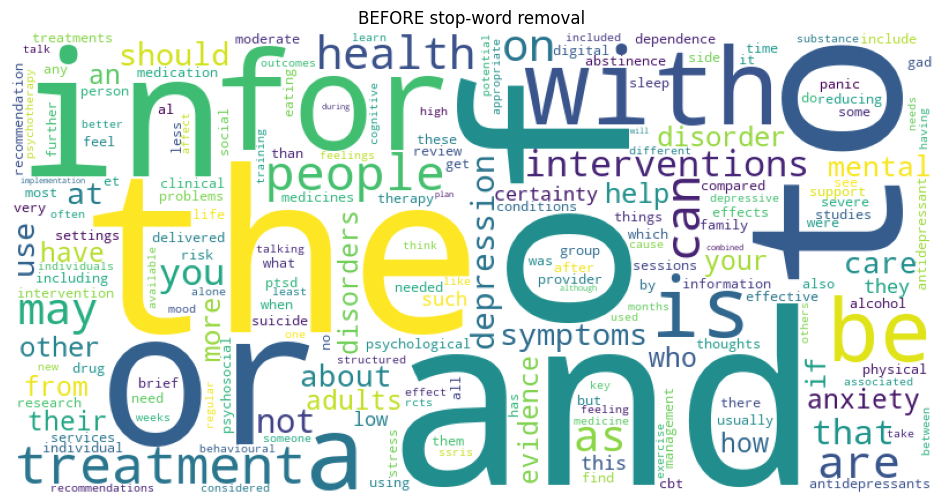

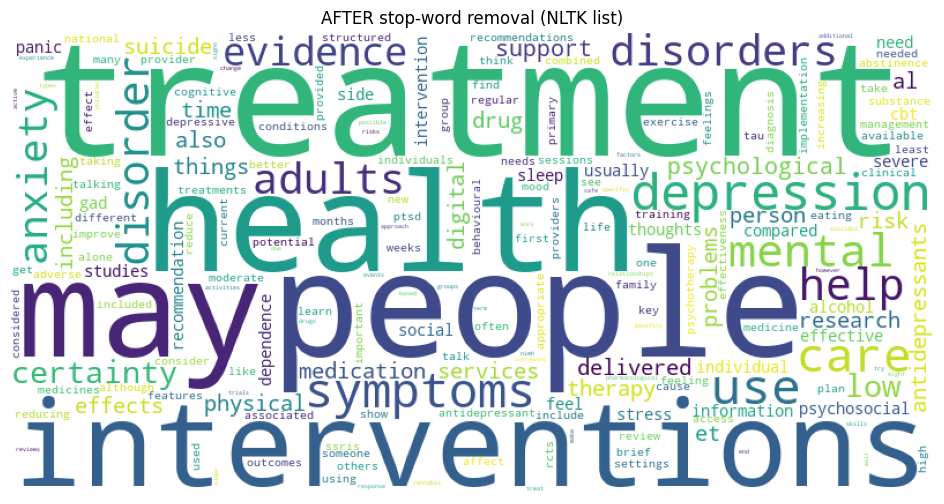

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

after_freq = Counter(w for w in corpus_words if w not in NLTK_STOPWORDS)

for title, freq in [("BEFORE stop-word removal", before_freq), ("AFTER stop-word removal (NLTK list)", after_freq)]:
    cloud = WordCloud(width=800, height=400, background_color="white", random_state=SEED).generate_from_frequencies(freq)
    plt.figure(figsize=(14, 6))
    plt.imshow(cloud)
    plt.axis("off")
    plt.title(title)
    plt.show()


In [65]:
def preprocess(text):
    """As in the reference: drop tokens that spaCy marks as stop words (token.is_stop).
    Uses our domain spaCy model (Exercise 5); punctuation dropped for readability."""
    doc = nlp_domain(normalise_for_tokenizing(text))
    return " ".join(t.text for t in doc if not t.is_stop and not t.is_punct)

def content_tokens(text):
    """Number policy -> custom tokenizer -> lowercase -> drop punctuation-only tokens."""
    return [t.lower() for t in custom_tokenize(apply_number_policy(text)) if any(ch.isalnum() for ch in t)]

def find_sentence(doc_id, phrase):
    """First line-aware sentence of a document containing the phrase (None if not found)."""
    text = next(d["text"] for d in docs if d["doc_id"] == doc_id)
    for s in line_then_nltk_sentences(text):
        if phrase.lower() in s.lower():
            return s

# Real guidance sentences + one example user query (like the reference's chatbot example)
test_texts = [(doc_id, find_sentence(doc_id, phrase)) for doc_id, phrase in
              [("D06", "should not be used"), ("D08", "shouldn't control"), ("D07", "do not go away"),
               ("D14", "coming off"), ("D17", "tea or coffee")]]
test_texts.append(("Query", "I don't want to stop my antidepressants suddenly, what should I do?"))

meaning_rows = []
for source, text in test_texts:
    if text is None:
        print("Not found:", source)
        continue
    meaning_rows.append({"Source": source,
                         "Original": text,
                         "spaCy list": preprocess(text),
                         "NLTK list": " ".join(w for w in content_tokens(text) if w not in NLTK_STOPWORDS)})

for r in meaning_rows:
    print(f"\n[{r['Source']}] {r['Original']}")
    print("   spaCy list :", r["spaCy list"])
    print("   NLTK list  :", r["NLTK list"])



[D06] Antidepressant medicines should not be used for treating depression in children and are not the first line of treatment in adolescents, among whom they should be used with extra caution.
   spaCy list : Antidepressant medicines treating depression children line treatment adolescents extra caution
   NLTK list  : antidepressant medicines used treating depression children first line treatment adolescents among used extra caution

[D08] While occasional stress and anxiety are normal, they shouldn't control your life.
   spaCy list : occasional stress anxiety normal control life
   NLTK list  : occasional stress anxiety normal control life

[D07] Physical aches or pains, headaches, cramps, or digestive problems without a clear physical cause that do not go away with treatment
   spaCy list : Physical aches pains headaches cramps digestive problems clear physical cause away treatment
   NLTK list  : physical aches pains headaches cramps digestive problems without clear physical cause

In [66]:
KEEP_WORDS = {"not", "no", "nor", "never", "without", "against", "cannot",      # negation
              "should", "must", "can", "may", "might", "could", "would",       # modals: strength of advice
              "before", "after", "until", "off", "down", "up", "out",          # timing, phrasal verbs (coming off, cut down)
              "more", "less", "only"}                                          # amounts
EXTRA_STOPWORDS = {"people", "person", "things", "information", "time", "et", "al"}        # generic words (Exercise 5, scenario ii)
CUSTOM_STOPWORDS = (NLTK_STOPWORDS - KEEP_WORDS) | EXTRA_STOPWORDS

# Make spaCy use exactly this list: set the is_stop flag in the vocabulary (as in the reference)
for word in SPACY_STOPWORDS | CUSTOM_STOPWORDS:
    for form in (word, word.capitalize()):
        nlp_domain.vocab[form].is_stop = word in CUSTOM_STOPWORDS

print("Custom stop list size:", len(CUSTOM_STOPWORDS))
for r in meaning_rows:
    r["Custom list"] = preprocess(r["Original"])          # same preprocess(), now with our list
    print(f"\n[{r['Source']}] {r['Original']}")
    for name in ["spaCy list", "NLTK list", "Custom list"]:
        print(f"   {name:11}: {r[name]}")

pd.DataFrame(meaning_rows).to_csv(RESULTS / "ex7_meaning_test.csv", index=False)
print("\nSaved:", RESULTS / "ex7_meaning_test.csv")


Custom stop list size: 190

[D06] Antidepressant medicines should not be used for treating depression in children and are not the first line of treatment in adolescents, among whom they should be used with extra caution.
   spaCy list : Antidepressant medicines treating depression children line treatment adolescents extra caution
   NLTK list  : antidepressant medicines used treating depression children first line treatment adolescents among used extra caution
   Custom list: Antidepressant medicines should not used treating depression children not first line treatment adolescents among should used extra caution

[D08] While occasional stress and anxiety are normal, they shouldn't control your life.
   spaCy list : occasional stress anxiety normal control life
   NLTK list  : occasional stress anxiety normal control life
   Custom list: occasional stress anxiety normal should not control life

[D07] Physical aches or pains, headaches, cramps, or digestive problems without a clear physi

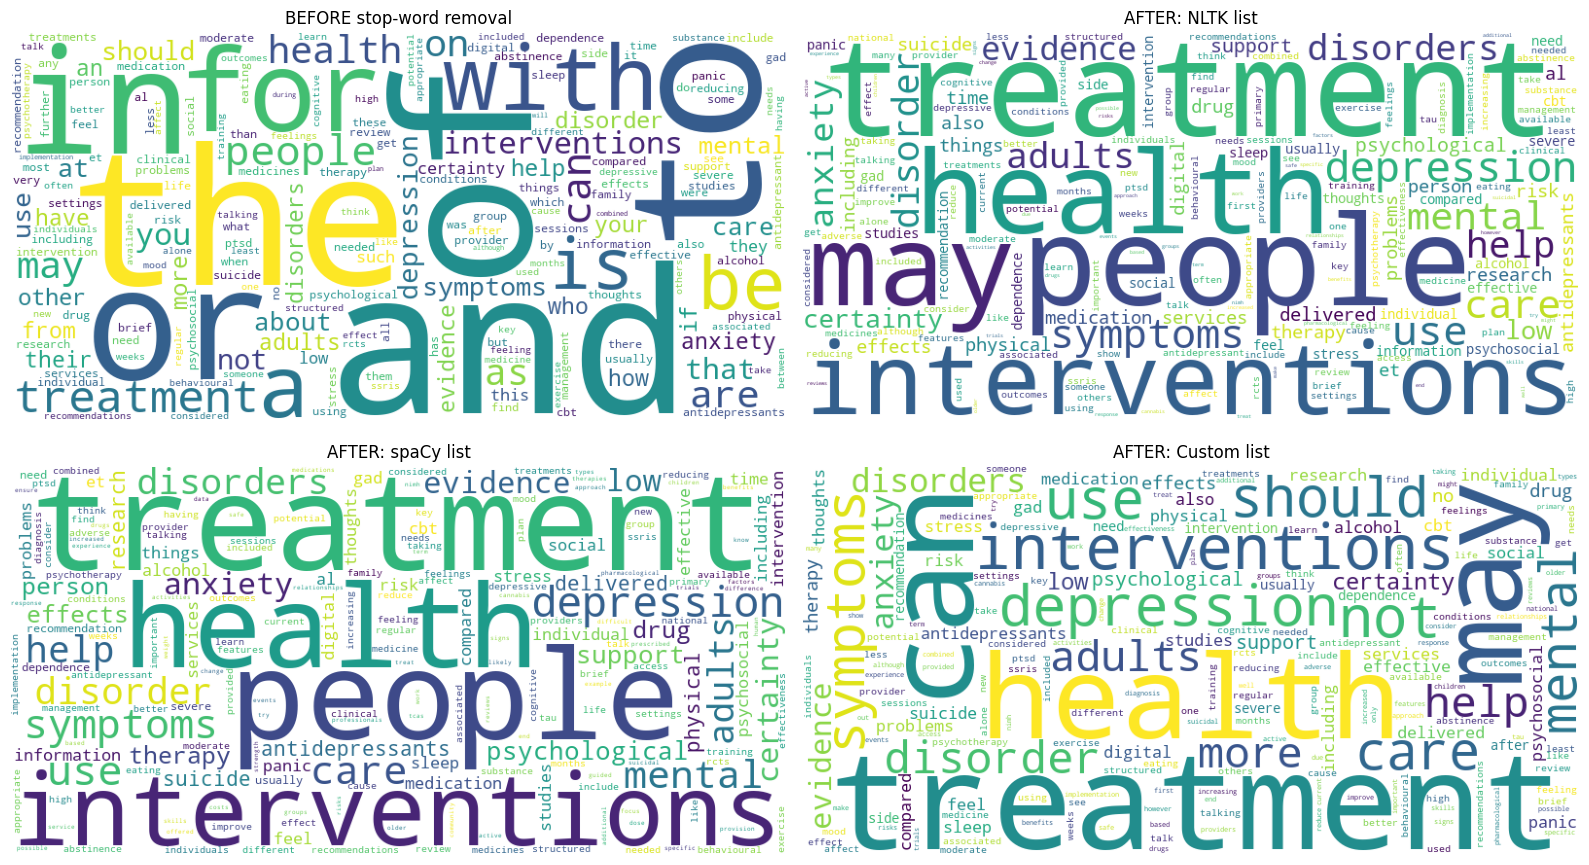

In [67]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud_settings = [("BEFORE stop-word removal", set()), ("AFTER: NLTK list", NLTK_STOPWORDS),
                  ("AFTER: spaCy list", SPACY_STOPWORDS), ("AFTER: Custom list", CUSTOM_STOPWORDS)]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (title, stop_list) in zip(axes.flat, cloud_settings):
    freq = Counter(w for w in corpus_words if w not in stop_list)
    cloud = WordCloud(width=800, height=400, background_color="white", random_state=SEED).generate_from_frequencies(freq)
    ax.imshow(cloud)
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [68]:
negation_words = {"not", "no", "nor", "never", "without"}
modal_words = {"should", "must", "can", "may", "might", "could", "would"}
stop_lists = {"No removal": set(), "NLTK list": NLTK_STOPWORDS, "spaCy list": SPACY_STOPWORDS, "Custom list": CUSTOM_STOPWORDS}

all_content = [content_tokens(d["text"]) for d in docs]
total_tokens = sum(len(toks) for toks in all_content)

effect_rows = []
for name, stop_list in stop_lists.items():
    kept = [t for toks in all_content for t in toks if t not in stop_list]
    effect_rows.append({"Stop list": name,
                        "List size": len(stop_list),
                        "Tokens kept": len(kept),
                        "Removed (%)": round(100 * (1 - len(kept) / total_tokens), 1),
                        "Vocabulary": len(set(kept)),
                        "Negation tokens kept": sum(t in negation_words for t in kept),
                        "Modal tokens kept": sum(t in modal_words for t in kept)})

ex7_effect = pd.DataFrame(effect_rows)
print(ex7_effect.to_string(index=False))
ex7_effect.to_csv(RESULTS / "ex7_stopword_effect.csv", index=False)
print("\nSaved:", RESULTS / "ex7_stopword_effect.csv")


  Stop list  List size  Tokens kept  Removed (%)  Vocabulary  Negation tokens kept  Modal tokens kept
 No removal          0        39660          0.0        3662                   327                828
  NLTK list        198        24570         38.0        3539                    22                326
 spaCy list        326        22968         42.1        3438                     0                  0
Custom list        190        24913         37.2        3546                   327                828

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex7_stopword_effect.csv


**Exercise 7: Stop-word removal: observations, decision and justification**

**Observations**
- Stop words make up roughly 40% of all words in the corpus (cell 2); after removal the most frequent words are content words ("treatment", "health", "depression", "symptoms").
- **Both standard lists change the meaning of health advice** (cells 4–5): "should not be used for treating depression in children" → "antidepressant medicines used treating depression children"; "don't smoke or drink alcohol … before going to bed" → "smoke drink alcohol … going bed"; "coming off antidepressants" → "coming antidepressants"; the query "I don't want to stop my antidepressants suddenly, what should I do?" → "want stop antidepressants suddenly". This is the domain version of the reference's "not a good movie" → "good movie" problem.
- The **spaCy list** (larger) removes every negation and modal in the corpus; the **NLTK list** keeps only "never" and "without", which it happens not to contain (cell 6).
- The **custom list** keeps all negations and modals while removing almost as many tokens as NLTK: protecting meaning costs very little noise reduction.

**Decision:** stop words **are removed**, using our **own domain-specific list**, not a standard one:
- base: NLTK English list (smaller and less aggressive than spaCy's)
- minus **KEEP_WORDS**: negations (not, no, nor, never, without, against, cannot), modals (should, must, can, may, might, could, would), timing/phrasal-verb words (before, after, until, off, down, up, out), amounts (more, less, only)
- plus **EXTRA_STOPWORDS**: generic words that hid document topics in Exercise 5 (people, person, things, information, time)

Applied **after lowercasing** (lists are lowercase) and implemented both as a set (for our custom-tokenizer pipeline) and through spaCy's `vocab[word].is_stop` flag (for spaCy-based steps).

**Why**
1. Removal is not required for dictionary building, but for this application (term frequencies, n-grams, retrieval weighting) function words would otherwise dominate the counts.
2. A standard list is unsafe here: negations, modals and particles carry the instruction in health advice, and removing them reverses its meaning, which is the exact failure a consumer-facing system must avoid.
3. No published stop list is tailored to consumer mental-health guidance; following AS1 ("specific stop word lists can be generated according to the need of the application"), our list is built from corpus evidence (meaning test, corpus effect, Exercise 5).

**Trade-off:** keeping negations and modals leaves some high-frequency words ("may", "should", "not") in frequency lists and n-grams. Whether removal with the custom list improves *retrieval* is tested in Module 3 (Pipeline A with the standard list vs Pipeline B with the custom list).


In [69]:
from collections import defaultdict
from types import SimpleNamespace
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, RegexpStemmer

def domain_light_stemmer(word):
    """Custom rule-based stemmer (reference's custom-stemmer idea), designed from Exercise 8 errors:
    removes only INFLECTIONAL endings, so derivational families (medical / medication) are never merged."""
    if len(word) <= 4 or not word.isalpha():          # short words, numbers, codes, compounds: unchanged
        return word
    if word.endswith(("ss", "us", "is")):              # illness, nervous, psychosis, diagnosis: not plurals
        return word
    if word.endswith("ies"):                           # therapies -> therapy, worries -> worry
        return word[:-3] + "y"
    if word.endswith(("sses", "ches", "shes", "xes")): # stresses -> stress, approaches -> approach
        return word[:-2]
    for suffix in ("ing", "ed", "s"):                  # sleeping -> sleep, needed -> need, medicines -> medicine
        if word.endswith(suffix) and len(word) - len(suffix) >= 4:
            return word[:-len(suffix)]
    return word

stemmers = {
    "Porter": PorterStemmer(),
    "Snowball": SnowballStemmer("english"),
    "Lancaster": LancasterStemmer(),
    "Regexp": RegexpStemmer(r"ing$|ed$|ly$|es$|s$", min=4),     # reference's suffix rules; min=4 protects short words
    "Domain light (custom)": SimpleNamespace(stem=domain_light_stemmer),   # same .stem() interface as NLTK stemmers
}
print(list(stemmers))

word_families = {
    "depress-": ["depression", "depressed", "depressive", "antidepressant", "antidepressants"],
    "medic-":   ["medication", "medications", "medical", "medicine", "medicines"],
    "anxi-":    ["anxiety", "anxious", "anxieties"],
    "therap-":  ["therapy", "therapies", "therapist", "therapeutic"],
    "general-": ["general", "generalised", "generalized", "generally"],
    "depend-":  ["dependence", "dependent", "depend"],
    "suicid-":  ["suicide", "suicidal", "suicides"],
    "sleep-":   ["sleep", "sleeping", "slept", "sleepy"],
    "harm-":    ["harm", "harmful", "harming", "self-harm"],
}

family_rows = []
for family, words in word_families.items():
    for word in words:
        row = {"Family": family, "Word": word}
        for name, stemmer in stemmers.items():
            row[name] = stemmer.stem(word)
        family_rows.append(row)
print(pd.DataFrame(family_rows).to_string(index=False))


['Porter', 'Snowball', 'Lancaster', 'Regexp', 'Domain light (custom)']
  Family            Word      Porter    Snowball   Lancaster         Regexp Domain light (custom)
depress-      depression     depress     depress     depress     depression            depression
depress-       depressed     depress     depress     depress        depress               depress
depress-      depressive     depress     depress     depress     depressive            depressive
depress-  antidepressant antidepress antidepress antidepress antidepressant        antidepressant
depress- antidepressants antidepress antidepress antidepress antidepressant        antidepressant
  medic-      medication       medic       medic         med     medication            medication
  medic-     medications       medic       medic         med     medication            medication
  medic-         medical       medic       medic         med        medical               medical
  medic-        medicine     medicin     medici

In [70]:
# Exercise 7 pipeline output: content words after the custom stop list (used for corpus frequencies here and in cell 3)
pipeline_tokens = [t for toks in all_content for t in toks if t not in CUSTOM_STOPWORDS]
corpus_freq = Counter(pipeline_tokens)

# Same meaning -> should share a stem (otherwise UNDER-stemming)
should_merge = [("anxiety", "anxious"), ("depression", "depressed"), ("antidepressant", "antidepressants"),
                ("therapy", "therapies"), ("medication", "medications"), ("suicide", "suicidal"),
                ("sleep", "sleeping"), ("sleep", "slept"), ("dependence", "dependent"),
                ("child", "children"), ("adolescent", "adolescence")]
# Different meaning -> should stay apart (otherwise OVER-stemming)
should_not_merge = [("medical", "medication"), ("general", "generalised"), ("experience", "experiment"),
                    ("community", "communication"), ("relative", "relation")]

pair_rows = []
for expected, pairs in [("same meaning", should_merge), ("different meaning", should_not_merge)]:
    for a, b in pairs:
        row = {"Pair": f"{a} / {b}", "Expected": expected, "Corpus freq": f"{corpus_freq[a]} / {corpus_freq[b]}"}
        for name, stemmer in stemmers.items():
            same_stem = stemmer.stem(a) == stemmer.stem(b)
            if expected == "same meaning":
                row[name] = "ok" if same_stem else "UNDER"
            else:
                row[name] = "OVER" if same_stem else "ok"
        pair_rows.append(row)

ex8_pairs = pd.DataFrame(pair_rows)
print(ex8_pairs.to_string(index=False))
print("\nErrors per stemmer:", {name: int((ex8_pairs[name] != "ok").sum()) for name in stemmers})
ex8_pairs.to_csv(RESULTS / "ex8_stemming_pairs.csv", index=False)
print("Saved:", RESULTS / "ex8_stemming_pairs.csv")


                            Pair          Expected Corpus freq Porter Snowball Lancaster Regexp Domain light (custom)
               anxiety / anxious      same meaning     129 / 9  UNDER    UNDER        ok  UNDER                 UNDER
          depression / depressed      same meaning    205 / 11     ok       ok        ok  UNDER                 UNDER
antidepressant / antidepressants      same meaning     53 / 89     ok       ok        ok     ok                    ok
             therapy / therapies      same meaning     93 / 23     ok       ok        ok  UNDER                    ok
        medication / medications      same meaning     78 / 23     ok       ok        ok     ok                    ok
              suicide / suicidal      same meaning     84 / 24     ok       ok        ok  UNDER                 UNDER
                sleep / sleeping      same meaning      68 / 9     ok       ok        ok     ok                    ok
                   sleep / slept      same meaning      

In [71]:
word_types = sorted(set(pipeline_tokens))

summary_rows = []
for name, stemmer in stemmers.items():
    stem_groups = defaultdict(set)                     # stem -> all corpus words that received this stem
    for w in word_types:
        stem_groups[stemmer.stem(w)].add(w)
    biggest = sorted(stem_groups.items(), key=lambda item: -len(item[1]))[:3]
    summary_rows.append({"Stemmer": name,
                         "Words before": len(word_types),
                         "Stems after": len(stem_groups),
                         "Reduction (%)": round(100 * (1 - len(stem_groups) / len(word_types)), 1),
                         "Largest merge groups": " || ".join(f"{s}: {', '.join(sorted(ws)[:6])}" for s, ws in biggest)})

ex8_summary = pd.DataFrame(summary_rows)
print(ex8_summary.drop(columns="Largest merge groups").to_string(index=False))
for _, r in ex8_summary.iterrows():
    print(f"\n{r['Stemmer']} largest groups -> {r['Largest merge groups']}")

ex8_summary.to_csv(RESULTS / "ex8_stemmer_comparison.csv", index=False)
print("\nSaved:", RESULTS / "ex8_stemmer_comparison.csv")


              Stemmer  Words before  Stems after  Reduction (%)
               Porter          3546         2571           27.5
             Snowball          3546         2545           28.2
            Lancaster          3546         2358           33.5
               Regexp          3546         2994           15.6
Domain light (custom)          3546         3025           14.7

Porter largest groups -> activ: activating, activation, active, actively, activities, activity || avoid: avoid, avoidance, avoidant, avoided, avoiding, avoids || care: care, cared, careful, carefully, cares, caring

Snowball largest groups -> activ: activating, activation, active, actively, activities, activity || avoid: avoid, avoidance, avoidant, avoided, avoiding, avoids || care: care, cared, careful, carefully, cares, caring

Lancaster largest groups -> act: act, acting, action, actions, activating, activation || us: us, use, used, useful, user, users || car: car, care, cared, careful, carefully, carer



**Exercise 8: Stemming: observations, decision and justification**

**Stemmers compared:** Porter, Snowball, Lancaster and RegexpStemmer (NLTK), plus a **custom domain light stemmer** (rule-based, removes only inflectional endings: plurals, -ies → -y, -ing, -ed, with protections for -ss/-us/-is words, short words and compounds). NLTK's other stemmers (ISRI/ARLSTem: Arabic, RSLP: Portuguese, Cistem: German) are language-specific and not applicable to English text.

**Observations**
- **Porter and Snowball** behave almost identically; Snowball (Porter2) is slightly more conservative, keeping readable stems ("anxious", "general") where Porter gives "anxiou", "gener".
- **Lancaster** is the most aggressive: "medication" → "med", "general/generalised" → "gen". Largest vocabulary reduction, most **over-stemming**; its corpus merge groups mix unrelated words ("us/use/useful/user", "car/care/carer").
- **RegexpStemmer** (the reference's suffix list) is weak: mostly **under-stemming** ("therapy/therapies", "depression/depressed" stay apart).
- **Custom light stemmer:** **no over-stemming at all** (it never removes derivational suffixes, so "medical/medication" stay apart) and its merge groups are clean inflection families ("affect/affected/affecting/affects"); but it has the most **under-stemming** of the useful stemmers and the smallest vocabulary reduction.
- **Every stemmer** fails on irregular forms ("slept" ≠ "sleep", "children" ≠ "child"): suffix rules cannot map irregular morphology.
- **Domain-relevant over-stemming:** Porter, Snowball and Lancaster merge "medical" with "medication".

**The trade-off:** aggressive stemming groups more related words (higher recall) but merges some different meanings (lower precision); light stemming is safe but groups less. No stemmer solves irregular forms.

**Decision:** **Snowball** is the stemmer used wherever stemming is applied (Pipeline A in Module 3): fewest errors (tied with Porter), its over-stemming affects fewer words that actually occur in our corpus than Porter's, and it is the improved Porter2. The custom light stemmer is the safe alternative, and its behaviour (inflection only, no merging of meanings) is what lemmatization should match while also handling irregular forms; Exercise 10 tests this, and Module 3 makes the final choice on retrieval evidence.


In [72]:
stemmer = stemmers["Snowball"]
corpus_tokens = [t for toks in all_content for t in toks]          # number policy -> custom tokenizer -> lowercase

order_a = [stemmer.stem(t) for t in corpus_tokens if t not in CUSTOM_STOPWORDS]        # A: stop words removed, then stem
order_b = [s for s in (stemmer.stem(t) for t in corpus_tokens) if s not in CUSTOM_STOPWORDS]   # B: stem, then remove stop words

order_rows = []
for label, tokens in [("A: stop-word removal -> stemming", order_a), ("B: stemming -> stop-word removal", order_b)]:
    order_rows.append({"Order": label, "Tokens": len(tokens), "Vocabulary": len(set(tokens))})
ex9_order = pd.DataFrame(order_rows)
print(ex9_order.to_string(index=False))
ex9_order.to_csv(RESULTS / "ex9_order_comparison.csv", index=False)
print("\nSaved:", RESULTS / "ex9_order_comparison.csv")


                           Order  Tokens  Vocabulary
A: stop-word removal -> stemming   24913        2545
B: stemming -> stop-word removal   25544        2553

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex9_order_comparison.csv


In [73]:
# Leaked: stop words that survive order B because their stem no longer matches the stop list
leaked = Counter(t for t in corpus_tokens if t in CUSTOM_STOPWORDS and stemmer.stem(t) not in CUSTOM_STOPWORDS)
print("Stop words that LEAK through when stemming comes first:")
print([(w, stemmer.stem(w), n) for w, n in leaked.most_common(15)])
print("Leaked tokens in total:", sum(leaked.values()))

# Lost: content words removed in order B because their stem happens to be a stop word
lost = Counter(t for t in corpus_tokens if t not in CUSTOM_STOPWORDS and stemmer.stem(t) in CUSTOM_STOPWORDS)
print("\nContent words wrongly REMOVED when stemming comes first:")
print([(w, stemmer.stem(w), n) for w, n in lost.most_common(15)])
print("Lost tokens in total:", sum(lost.values()))


Stop words that LEAK through when stemming comes first:
[('people', 'peopl', 316), ('things', 'thing', 72), ('information', 'inform', 67), ('any', 'ani', 62), ('very', 'veri', 60), ('during', 'dure', 32), ('does', 'doe', 30), ("you're", "you'r", 30), ('why', 'whi', 14), ('themselves', 'themselv', 11), ('ourselves', 'ourselv', 7), ('because', 'becaus', 6), ("you've", "you'v", 5), ('above', 'abov', 4), ('once', 'onc', 3)]
Leaked tokens in total: 724

Content words wrongly REMOVED when stemming comes first:
[('others', 'other', 38), ("person's", 'person', 28), ('willing', 'will', 9), ('times', 'time', 9), ('personality', 'person', 3), ('underlying', 'under', 2), ('personal', 'person', 2), ("who's", 'who', 2)]
Lost tokens in total: 93


**Exercise 9: Order of stemming and stop-word removal: observations and decision**

- The two orders give similar token and vocabulary totals, but the totals hide two opposite errors in order B (stemming first):
  1. **Stop words leak through:** a stop list contains surface forms, and stemming changes them so they no longer match ("any" → "ani", "very" → "veri", "does" → "doe", "because" → "becaus"). Even our domain EXTRA words leak ("people" → "peopl", "information" → "inform"), silently defeating the custom list from Exercise 7.
  2. **Content words are wrongly removed:** their stem happens to equal a stop word: "personality" → "person" (clinically meaningful, e.g. personality disorder), "personal" → "person", "willing" → "will", "underlying" → "under".
- **Decision:** stop-word removal **before** stemming. A stop list must be applied to the word forms it was written for; any operation that changes word forms (stemming, and also lemmatization) comes after it, or must at least use the surface form when deciding what to remove.


In [74]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from spacy.tokens import Doc

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

wnl = WordNetLemmatizer()

def wordnet_pos(treebank_tag):
    """Map NLTK (Penn Treebank) tags to WordNet POS: J -> adjective, V -> verb, R -> adverb, else noun."""
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

lemma_test_words = ["depression", "depressed", "antidepressants", "medication", "medications", "medical",
                    "medicines", "anxiety", "anxious", "therapies", "therapist", "suicidal", "sleeping",
                    "slept", "children", "worse", "better", "was", "diagnoses", "studies", "worries",
                    "SSRIs", "generalised", "harms"]

word_rows = []
for w in lemma_test_words:
    tag = nltk.pos_tag([w])[0][1]
    word_rows.append({"Word": w,
                      "Snowball stem": stemmers["Snowball"].stem(w),
                      "WordNet (no POS)": wnl.lemmatize(w.lower()),
                      "POS tag": tag,
                      "WordNet + POS": wnl.lemmatize(w.lower(), wordnet_pos(tag)),
                      "spaCy": nlp_domain(w)[0].lemma_})
print(pd.DataFrame(word_rows).to_string(index=False))


           Word Snowball stem WordNet (no POS) POS tag  WordNet + POS          spaCy
     depression       depress       depression      NN     depression     depression
      depressed       depress        depressed      JJ      depressed      depressed
antidepressants   antidepress   antidepressant     NNS antidepressant antidepressant
     medication         medic       medication      NN     medication     medication
    medications         medic       medication     NNS     medication     medication
        medical         medic          medical      JJ        medical        medical
      medicines       medicin         medicine     NNS       medicine       medicine
        anxiety       anxieti          anxiety      NN        anxiety        anxiety
        anxious       anxious          anxious      JJ        anxious        anxious
      therapies       therapi          therapy     NNS        therapy        therapy
      therapist     therapist        therapist      NN      thera

In [75]:
from textblob import Word, TextBlob

def lemma_of(word, method):
    if method == "WordNet (no POS)":
        return wnl.lemmatize(word)
    if method == "WordNet + POS":
        return wnl.lemmatize(word, wordnet_pos(nltk.pos_tag([word])[0][1]))
    if method == "TextBlob (no POS)":                      # TextBlob default: every word treated as a noun
        return Word(word).lemmatize()
    if method == "TextBlob + POS (verbs)":                 # as in the reference: verbs -> 'v', everything else noun
        tags = TextBlob(word).tags
        return Word(word).lemmatize("v" if tags and tags[0][1].startswith("VB") else "n")
    return nlp_domain(word)[0].lemma_.lower()              # spaCy

methods = ["WordNet (no POS)", "WordNet + POS", "TextBlob (no POS)", "TextBlob + POS (verbs)", "spaCy"]
stem_columns = ["Snowball", "Domain light (custom)"]

lemma_pair_rows = []
for expected, pairs in [("same meaning", should_merge), ("different meaning", should_not_merge)]:
    for a, b in pairs:
        row = {"Pair": f"{a} / {b}", "Expected": expected}
        for col in stem_columns:                                # stemmer results from Exercise 8
            row[col] = ex8_pairs.loc[ex8_pairs["Pair"] == f"{a} / {b}", col].iloc[0]
        for m in methods:
            same = lemma_of(a, m) == lemma_of(b, m)
            row[m] = ("ok" if same else "UNDER") if expected == "same meaning" else ("OVER" if same else "ok")
        lemma_pair_rows.append(row)

ex10_pairs = pd.DataFrame(lemma_pair_rows)
print(ex10_pairs.to_string(index=False))
print("\nErrors:", {m: int((ex10_pairs[m] != "ok").sum()) for m in stem_columns + methods})
ex10_pairs.to_csv(RESULTS / "ex10_lemma_pairs.csv", index=False)
print("Saved:", RESULTS / "ex10_lemma_pairs.csv")


                            Pair          Expected Snowball Domain light (custom) WordNet (no POS) WordNet + POS TextBlob (no POS) TextBlob + POS (verbs) spaCy
               anxiety / anxious      same meaning    UNDER                 UNDER            UNDER         UNDER             UNDER                  UNDER UNDER
          depression / depressed      same meaning       ok                 UNDER            UNDER         UNDER             UNDER                  UNDER UNDER
antidepressant / antidepressants      same meaning       ok                    ok               ok            ok                ok                     ok    ok
             therapy / therapies      same meaning       ok                    ok               ok            ok                ok                     ok    ok
        medication / medications      same meaning       ok                    ok               ok            ok                ok                     ok    ok
              suicide / suicidal      sa

In [76]:
def lemmas_wordnet(tokens):
    return [wnl.lemmatize(t) for t in tokens]

def lemmas_wordnet_pos(tokens):
    return [wnl.lemmatize(t, wordnet_pos(tag)) for t, tag in nltk.pos_tag(tokens)]

def lemmas_textblob(tokens):
    return [Word(t).lemmatize() for t in tokens]

def lemmas_textblob_pos(tokens):
    # TextBlob's default tagger IS NLTK's tagger, so we tag our own tokens with it (keeps tokens aligned)
    return [Word(t).lemmatize("v" if tag.startswith("VB") else "n") for t, tag in nltk.pos_tag(tokens)]

def lemmas_spacy(tokens):
    """Run spaCy's tagger + lemmatizer on OUR tokens (no re-tokenization), so lemmas align with tokens."""
    doc = Doc(nlp_domain.vocab, words=tokens)
    for _, component in nlp_domain.pipeline:
        doc = component(doc)
    return [t.lemma_.lower() for t in doc]

normalisers = {"No normalisation": lambda toks: toks,
               "Snowball stemmer": lambda toks: [stemmers["Snowball"].stem(t) for t in toks],
               "Domain light stemmer": lambda toks: [domain_light_stemmer(t) for t in toks],
               "WordNet (no POS)": lemmas_wordnet,
               "WordNet + POS": lemmas_wordnet_pos,
               "TextBlob (no POS)": lemmas_textblob,
               "TextBlob + POS (verbs)": lemmas_textblob_pos,
               "spaCy": lemmas_spacy}

norm_rows = []
for name, normalise in normalisers.items():
    start = time.time()
    output = []
    for toks in all_content:                               # full sequence: gives the POS tagger context
        forms = normalise(toks)
        output += [f for t, f in zip(toks, forms) if t not in CUSTOM_STOPWORDS]   # stop words dropped by SURFACE form
    norm_rows.append({"Method": name,
                      "Tokens": len(output),
                      "Vocabulary": len(set(output)),
                      "Time (s)": round(time.time() - start, 1)})

ex10_corpus = pd.DataFrame(norm_rows)
base = ex10_corpus.loc[0, "Vocabulary"]
ex10_corpus["Vocabulary reduction (%)"] = (100 * (1 - ex10_corpus["Vocabulary"] / base)).round(1)
print(ex10_corpus.to_string(index=False))
ex10_corpus.to_csv(RESULTS / "ex10_normaliser_comparison.csv", index=False)
print("\nSaved:", RESULTS / "ex10_normaliser_comparison.csv")


                Method  Tokens  Vocabulary  Time (s)  Vocabulary reduction (%)
      No normalisation   24913        3546       0.0                       0.0
      Snowball stemmer   24913        2545       0.3                      28.2
  Domain light stemmer   24913        3025       0.0                      14.7
      WordNet (no POS)   24913        3248       0.2                       8.4
         WordNet + POS   24913        2966       2.3                      16.4
     TextBlob (no POS)   24913        3248       0.2                       8.4
TextBlob + POS (verbs)   24913        2980       2.9                      16.0
                 spaCy   24913        2926      13.9                      17.5

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex10_normaliser_comparison.csv


In [107]:
# Domain lemma rules, added the way the reference customises the lemmatizer
ruler = nlp_domain.get_pipe("attribute_ruler")

# 1. Plural acronyms found in the corpus (SSRIs, RCTs, ...) -> singular lemma
acronym_plurals = sorted({m for d in docs for m in re.findall(r"\b[A-Z]{2,}s\b", d["text"])})
for term in acronym_plurals:
    ruler.add([[{"LOWER": term.lower()}]], {"LEMMA": term[:-1].lower()})

# 2. Domain words spaCy gets wrong
domain_lemmas = {"media": "media",                 # "social media", not "medium"
                 "generalised": "generalised",     # adjective in "generalised anxiety disorder"
                 "generalized": "generalised"}     # one spelling for both
for word, lemma in domain_lemmas.items():
    ruler.add([[{"LOWER": word}]], {"LEMMA": lemma})

print("Acronym plural rules:", acronym_plurals)
for w in ["SSRIs", "RCTs", "media", "generalised", "generalized", "children", "slept"]:
    print(f"  {w:12} -> {nlp_domain(w)[0].lemma_}")


Acronym plural rules: ['HICs', 'LMICs', 'MAOIs', 'NASSAs', 'NMAs', 'NSAIDs', 'RCTs', 'SARIs', 'SNRIs', 'SSRIs', 'TCAs']
  SSRIs        -> ssri
  RCTs         -> rct
  media        -> media
  generalised  -> generalised
  generalized  -> generalised
  children     -> child
  slept        -> sleep


In [106]:
table_c_words = ["depression", "depressed", "antidepressants", "medication", "medical", "medicines",
                 "anxiety", "anxious", "therapies", "suicidal", "sleeping", "slept", "children",
                 "worse", "better", "diagnoses", "psychoses", "worries", "SSRIs", "generalised", "media"]

table_c = pd.DataFrame([{"Word": w,
                         "Stemmed (Snowball)": stemmers["Snowball"].stem(w),
                         "Lemmatized (spaCy + domain rules)": nlp_domain(w)[0].lemma_.lower()}
                        for w in table_c_words])
print(table_c.to_string(index=False))
table_c.to_csv(RESULTS / "stem_vs_lemma.csv", index=False)
print("\nSaved:", RESULTS / "stem_vs_lemma.csv")


           Word Stemmed (Snowball) Lemmatized (spaCy + domain rules)
     depression            depress                        depression
      depressed            depress                         depressed
antidepressants        antidepress                    antidepressant
     medication              medic                        medication
        medical              medic                           medical
      medicines            medicin                          medicine
        anxiety            anxieti                           anxiety
        anxious            anxious                           anxious
      therapies            therapi                           therapy
       suicidal             suicid                          suicidal
       sleeping              sleep                             sleep
          slept              slept                             sleep
       children           children                             child
          worse               wors

**Exercise 10: Lemmatization: observations, decision and justification**

**Methods compared:** WordNet lemmatizer (without POS / with POS from NLTK's tagger), TextBlob (without POS / with verb POS, as in the reference), spaCy lemmatizer; Snowball and the custom domain light stemmer (Exercise 8) as reference points. Lemmatization runs on the full token sequence (context for POS tagging); stop words are removed by surface form afterwards (Exercise 9). **Gensim was not included:** its own lemmatizer was removed in Gensim 4, and the commonly cited "Gensim" example actually calls NLTK's WordNet after Gensim's tokenizer, so it is not a separate algorithm.

**Observations**
- **TextBlob without POS gives exactly the same results as WordNet without POS**: TextBlob's lemmatizer is a wrapper around NLTK's WordNetLemmatizer (and its default tagger is NLTK's), so it is not an independent method.
- **POS information matters:** without POS every word is treated as a noun ("sleeping" stays "sleeping"). TextBlob's verb-only POS variant reduces slightly less than WordNet + POS, because adjectives and adverbs ("worse" → "bad") are not mapped.
- **spaCy has the fewest errors of all methods**, including the stemmers: it is the only one that maps every irregular form ("slept" → "sleep", "children" → "child"), and it never merges different meanings ("medical" ≠ "medication"). It also gives the largest vocabulary reduction among the lemmatizers, but is the slowest.
- **All lemmatizers keep derivational pairs apart** (anxiety/anxious, depression/depressed): a lemma keeps the word class. Snowball merges these pairs, but its errors include **over-stemming**, while the lemmatizers' errors are all **under-merging**: the safer error type in a health domain, where merging different meanings ("medical help" vs "medication") changes the advice.
- **spaCy's domain errors**, fixed with the `attribute_ruler` (as in the reference): plural acronyms not reduced ("SSRIs"), "media" → "medium" (breaks "social media"), "generalised" lemmatized as a verb and split by spelling.

**Decision:** **spaCy lemmatizer with domain rules** is used wherever lemmatization is applied (Pipeline B in Module 3).

**Why**
1. Fewest errors of all methods, correct irregular forms, and no over-stemming.
2. Lemmas are **real words**, so index terms, n-grams and GUI output stay readable and explainable.
3. Context-aware POS tagging, and customisable for domain terms (`attribute_ruler`).

**Trade-off:** slower than WordNet (acceptable: indexing runs once), less vocabulary reduction than stemming, and derivational variants (anxiety/anxious) stay separate, which may lower recall for some queries. Stemming (Pipeline A) vs lemmatization (Pipeline B) is decided on retrieval evidence in Module 3.


In [79]:
def final_preprocess(text):
    """FINAL preprocessing (Pipeline B), used for documents AND queries:
    number policy -> custom tokenizer -> lowercase -> drop punctuation
    -> spaCy lemmas in context (domain rules) -> remove custom stop words (by surface form)."""
    tokens = content_tokens(text)
    if not tokens:
        return []
    lemmas = lemmas_spacy(tokens)
    return [lemma for token, lemma in zip(tokens, lemmas) if token not in CUSTOM_STOPWORDS]

processed_docs = {d["doc_id"]: final_preprocess(d["text"]) for d in docs}     # ~10 s; reused for n-grams and the index

example = find_sentence("D06", "should not be used")
print("Before:", example)
print("After :", final_preprocess(example))


Before: Antidepressant medicines should not be used for treating depression in children and are not the first line of treatment in adolescents, among whom they should be used with extra caution.
After : ['antidepressant', 'medicine', 'should', 'not', 'use', 'treat', 'depression', 'child', 'not', 'first', 'line', 'treatment', 'adolescent', 'among', 'should', 'use', 'extra', 'caution']


In [80]:
before_tokens = [t for d in docs for t in d["text"].split()]          # Module 1 definition (split)
after_tokens = [t for toks in processed_docs.values() for t in toks]

table_a = pd.DataFrame({
    "Measure": ["Documents", "Tokens", "Unique tokens", "Vocabulary size", "Average tokens per document"],
    "Before processing": [len(docs), len(before_tokens), len(set(before_tokens)),
                          len({t.lower() for t in before_tokens}), round(len(before_tokens) / len(docs), 1)],
    "After processing": [len(docs), len(after_tokens), len(set(after_tokens)),
                         len(set(after_tokens)), round(len(after_tokens) / len(docs), 1)],
})
table_a["Change (%)"] = (100 * (table_a["After processing"] / table_a["Before processing"] - 1)).round(1)
print(table_a.to_string(index=False))
table_a.to_csv(RESULTS / "preprocessing_results.csv", index=False)
print("\nSaved:", RESULTS / "preprocessing_results.csv")

print("\nTop 15 terms after preprocessing:", Counter(after_tokens).most_common(15))


                    Measure  Before processing  After processing  Change (%)
                  Documents               17.0              17.0         0.0
                     Tokens            39961.0           24913.0       -37.7
              Unique tokens             5976.0            2919.0       -51.2
            Vocabulary size             5421.0            2919.0       -46.2
Average tokens per document             2350.6            1465.5       -37.7

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\preprocessing_results.csv

Top 15 terms after preprocessing: [('treatment', 420), ('intervention', 313), ('can', 308), ('use', 297), ('disorder', 292), ('health', 273), ('may', 268), ('not', 213), ('depression', 205), ('should', 194), ('symptom', 190), ('care', 181), ('help', 173), ('mental', 168), ('include', 167)]


**Exercise 11: Corpus before vs after preprocessing (Results Table A)**

Final preprocessing (Pipeline B, same function for documents and queries): number policy (Ex 6) → custom tokenizer (Ex 3) → lowercase → drop punctuation → spaCy lemmatization with domain rules (Ex 10) → custom stop-word removal by surface form (Ex 7, 9).

- **Tokens** fall sharply: punctuation, stop words and statistical/structural numbers are removed.
- **Vocabulary** falls: case variants, punctuation-attached variants and inflected forms collapse into one lemma each ("antidepressants" → "antidepressant", "slept" → "sleep").
- After preprocessing, unique tokens = vocabulary size, because all terms are lowercased lemmas.
- **What is preserved:** negations and modals ("should not used treating depression children"), domain compounds ("self-harm"), ranges, helplines and clinically meaningful numbers.
- The top terms after preprocessing are domain content words rather than function words.

Table A is regenerated automatically if Module 3 selects a different final pipeline.


In [81]:
#Step 1 (this message): default tagging, domain errors, rule-based tagger, gold candidates

#Code cell 1: default taggers on the corpus (NLTK perceptron vs spaCy)
from nltk.tag import RegexpTagger

nltk.download("averaged_perceptron_tagger_eng", quiet=True)

def nltk_tags(tokens):
    """Default tagger 1: NLTK's pretrained Averaged Perceptron (Penn Treebank tags)."""
    return [tag for _, tag in nltk.pos_tag(tokens)]

# spaCy uses different names for a few Penn tags; map them to NLTK's names so only REAL differences count
SPACY_TO_NLTK = {"-LRB-": "(", "-RRB-": ")", "HYPH": ":", "NFP": ":", "ADD": "NN"}

def spacy_tags(tokens):
    """Default tagger 2: spaCy en_core_web_sm on OUR tokens (domain terms stay whole), Penn tags (tag_)."""
    doc = Doc(nlp_domain.vocab, words=tokens)
    for _, component in nlp_domain.pipeline:
        doc = component(doc)
    return [SPACY_TO_NLTK.get(t.tag_, t.tag_) for t in doc]


# Sentences: line-aware splitter (Ex 2B) + custom tokenizer (Ex 3)
pos_sentences = [custom_tokenize(s) for d in docs for s in line_then_nltk_sentences(d["text"])]
pos_sentences = [s for s in pos_sentences if len(s) >= 5]

agree = total = 0
nltk_dist, spacy_dist = defaultdict(Counter), defaultdict(Counter)
for toks in pos_sentences:                      # ~20 s: spaCy tags the whole corpus
    for tok, a, b in zip(toks, nltk_tags(toks), spacy_tags(toks)):
        total += 1
        agree += (a == b)
        nltk_dist[tok.lower()][a] += 1
        spacy_dist[tok.lower()][b] += 1

print("Sentences tagged:", len(pos_sentences), "| tokens:", total)
print(f"NLTK and spaCy agree on {100 * agree / total:.1f}% of tokens")

# How are our domain terms tagged?
check_terms = ["e.g.", "panic", "ssris", "self-harm", "ptsd", "mhgap", "gad", "cbt", "sertraline",
               "follow-up", "stress", "harm", "help", "worry", "18–64", "dsm-5", "988"]
term_rows = [{"Term": w,
              "NLTK tags": dict(nltk_dist[w].most_common(3)),
              "spaCy tags": dict(spacy_dist[w].most_common(3))} for w in check_terms if w in nltk_dist]
print(pd.DataFrame(term_rows).to_string(index=False))


Sentences tagged: 2559 | tokens: 44376
NLTK and spaCy agree on 91.3% of tokens
      Term                      NLTK tags                     spaCy tags
      e.g.   {'VB': 28, 'NN': 7, 'JJ': 3}                     {'RB': 38}
     panic            {'JJ': 57, 'NN': 5}                     {'NN': 62}
     ssris           {'NNP': 39, 'NN': 1}         {'NNS': 25, 'NNP': 15}
 self-harm  {'NN': 23, 'JJ': 5, 'VBP': 3}            {'JJ': 30, 'NN': 2}
      ptsd                    {'NNP': 45} {'NNP': 23, 'NN': 13, 'JJ': 9}
     mhgap                      {'NN': 4}                      {'NN': 4}
       gad                    {'NNP': 66}                    {'NNP': 66}
       cbt           {'NNP': 55, 'NN': 2}                    {'NNP': 57}
sertraline                     {'NN': 12}            {'NN': 11, 'JJ': 1}
 follow-up           {'NN': 15, 'JJ': 14} {'NN': 17, 'FW': 11, 'NNP': 1}
    stress  {'NN': 34, 'JJ': 7, 'NNP': 6}  {'NN': 47, 'VB': 3, 'NNP': 2}
      harm   {'NN': 8, 'JJ': 4, 'VBP': 2}  {'

In [82]:
#Code cell 2: custom rule-based tagger (domain dictionary + RegexpTagger)
# Context-free domain dictionary: only terms whose tag does not depend on context
DOMAIN_LEXICON = {
    "e.g.": "FW", "i.e.": "FW", "etc.": "FW",                                    # Latin abbreviations
    "ptsd": "NNP", "gad": "NNP", "cbt": "NNP", "ocd": "NNP", "mhgap": "NNP",     # named conditions / programmes
    "nhs": "NNP", "nimh": "NNP", "samhsa": "NNP",
    "panic": "NN", "self-harm": "NN",                                            # nouns, also as modifiers (Penn: NN)
    "sertraline": "NN", "fluoxetine": "NN", "escitalopram": "NN", "citalopram": "NN", "paroxetine": "NN",
    "mirtazapine": "NN", "venlafaxine": "NN", "duloxetine": "NN", "naltrexone": "NN", "acamprosate": "NN",
    "baclofen": "NN", "disulfiram": "NN", "pregabalin": "NN", "lithium": "NN",   # medicines
}
# Ambiguous words (help, stress, harm, worry, follow-up) are NOT in the dictionary: their tag depends on context.

domain_patterns = [                                           # rule-based patterns, as in the reference RegexpTagger
    (r"^\d+(\.\d+)?[\u2013-]\d+(\.\d+)?$", "CD"),             # ranges: 18–64, 6–12
    (r"^\d+(\.\d+){2,}$", "CD"),                              # recommendation IDs: 1.5.1
    (r"^1-8\d\d-\d{3}-\d{4}$", "CD"),                         # helpline numbers
    (r"^[A-Z]{2,}(-?\d+|-[IVX]+)$", "NNP"),                   # classification codes: DSM-5, DSM-IV, ICD-11, ANX2
    (r"^[A-Z]{2,}s$", "NNS"),                                 # plural acronyms: SSRIs, RCTs
    (r"^(https?://|www\.)|\.(org|gov|com|uk|int)\b", "NNP"),  # web addresses (names of services)
]
domain_regexp_tagger = RegexpTagger(domain_patterns)          # no catch-all: returns None if no rule matches

def rule_based_tags(tokens):
    """Custom tagger 1: default NLTK tags, overridden by the domain dictionary, then by the domain regex rules."""
    tags = nltk_tags(tokens)
    for i, tok in enumerate(tokens):
        if tok.lower() in DOMAIN_LEXICON:
            tags[i] = DOMAIN_LEXICON[tok.lower()]
        else:
            rule_tag = domain_regexp_tagger.tag([tok])[0][1]
            if rule_tag:
                tags[i] = rule_tag
    return tags

def is_domain_token(tok):
    return tok.lower() in DOMAIN_LEXICON or domain_regexp_tagger.tag([tok])[0][1] is not None

example = ["Talk", "to", "your", "GP", "about", "SSRIs", "(", "e.g.", "sertraline", ")", "if", "panic", "attacks", "continue", "."]
print(list(zip(example, nltk_tags(example), rule_based_tags(example))))


[('Talk', 'NN', 'NN'), ('to', 'TO', 'TO'), ('your', 'PRP$', 'PRP$'), ('GP', 'NNP', 'NNP'), ('about', 'IN', 'IN'), ('SSRIs', 'NNP', 'NNS'), ('(', '(', '('), ('e.g.', 'JJ', 'FW'), ('sertraline', 'NN', 'NN'), (')', ')', ')'), ('if', 'IN', 'IN'), ('panic', 'JJ', 'NN'), ('attacks', 'NNS', 'NNS'), ('continue', 'VBP', 'VBP'), ('.', '.', '.')]


In [83]:
#Code cell 3: gold candidates for the domain terms (from the reference's Appendix C)
# 50 random domain sentences (seeded); 30 for ML training, 20 held out for testing ALL taggers
candidates = [s for s in pos_sentences if 6 <= len(s) <= 30 and any(is_domain_token(t) for t in s)]
gold_sentences = random.Random(SEED).sample(candidates, 50)

gold_rows = []
for sid, toks in enumerate(gold_sentences):
    for pos, (tok, a, b) in enumerate(zip(toks, nltk_tags(toks), spacy_tags(toks))):
        needs_review = (a != b) or is_domain_token(tok)
        gold_rows.append({"sent_id": sid, "position": pos, "token": tok, "nltk": a, "spacy": b,
                          "gold": "" if needs_review else a,          # agreed tags pre-filled; the rest is reviewed
                          "review": "YES" if needs_review else ""})

gold_df = pd.DataFrame(gold_rows)
gold_df.to_csv(RESULTS / "pos_gold_candidates.csv", index=False)
print("Tokens:", len(gold_df), "| to review:", (gold_df["review"] == "YES").sum())
print("Saved:", RESULTS / "pos_gold_candidates.csv")


Tokens: 724 | to review: 119
Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\pos_gold_candidates.csv


In [86]:
gold_table = pd.read_csv(RESULTS / "C:\\Users\\Lenovo\\OneDrive\\Desktop\\sem 7\\NLP\\Assigmnet 1\\as1- tanmayee\\Domain_Text_Analysis_Retrieval\\Domain_Text_Analysis_Retrieval\\results\\pos_gold_candidates.csv", keep_default_na=False)
gold_sents = [list(zip(g["token"], g["gold"])) for _, g in gold_table.sort_values(["sent_id", "position"]).groupby("sent_id")]

shuffled = gold_sents[:]
random.Random(SEED).shuffle(shuffled)
domain_train, domain_test = shuffled[:30], shuffled[30:]          # 30 sentences for ML training, 20 held out for ALL taggers
print("Domain gold sentences -> train:", len(domain_train), "| test:", len(domain_test),
      "| test tokens:", sum(len(s) for s in domain_test))

def evaluate(tag_function, test_sents):
    """Token accuracy overall and on domain tokens only (same held-out sentences for every tagger)."""
    correct = total = d_correct = d_total = 0
    for sent in test_sents:
        words = [w for w, _ in sent]
        for (word, gold), pred in zip(sent, tag_function(words)):
            total += 1
            correct += (pred == gold)
            if is_domain_token(word):
                d_total += 1
                d_correct += (pred == gold)
    return round(100 * correct / total, 1), round(100 * d_correct / d_total, 1)

results = {}
for name, fn in [("Default: NLTK perceptron", nltk_tags), ("Default: spaCy", spacy_tags),
                 ("Custom: rule-based (dictionary + regex)", rule_based_tags)]:
    results[name] = evaluate(fn, domain_test)
    print(f"{name:42} accuracy {results[name][0]:5}% | domain tokens {results[name][1]:5}%")


Domain gold sentences -> train: 30 | test: 20 | test tokens: 303
Default: NLTK perceptron                   accuracy  84.8% | domain tokens   0.0%
Default: spaCy                             accuracy  84.8% | domain tokens   0.0%
Custom: rule-based (dictionary + regex)    accuracy  84.8% | domain tokens   0.0%


In [87]:
from nltk.corpus import treebank
from nltk.tag import DefaultTagger, AffixTagger, UnigramTagger, BigramTagger, TrigramTagger
nltk.download("treebank", quiet=True)
treebank_sents = list(treebank.tagged_sents())

def train_ngram_chain(train_sents):
    """Backoff chain: Trigram -> Bigram -> Unigram -> Affix -> Default('NN')."""
    t0 = DefaultTagger("NN")
    t1 = AffixTagger(train_sents, backoff=t0)
    t2 = UnigramTagger(train_sents, backoff=t1)
    t3 = BigramTagger(train_sents, backoff=t2)
    return TrigramTagger(train_sents, backoff=t3)

ngram_treebank = train_ngram_chain(treebank_sents)                    # general news text only
ngram_domain = train_ngram_chain(treebank_sents + domain_train)       # + our 30 domain sentences

for name, tagger in [("ML: n-gram backoff (Treebank only)", ngram_treebank),
                     ("ML: n-gram backoff (Treebank + domain)", ngram_domain)]:
    results[name] = evaluate(lambda words, t=tagger: [tag for _, tag in t.tag(words)], domain_test)
    print(f"{name:42} accuracy {results[name][0]:5}% | domain tokens {results[name][1]:5}%")


ML: n-gram backoff (Treebank only)         accuracy  74.6% | domain tokens   0.0%
ML: n-gram backoff (Treebank + domain)     accuracy  84.2% | domain tokens  73.9%


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

def token_features(sentences):
    """Reference features: word, previous/next word, word length, first/last character."""
    rows, labels = [], []
    for sent in sentences:
        words = [w for w, _ in sent]
        for i, (word, tag) in enumerate(sent):
            rows.append({"word": word,
                         "previous_word": words[i - 1] if i > 0 else "START",
                         "next_word": words[i + 1] if i < len(words) - 1 else "END",
                         "word_length": len(word), "first_char": word[0], "last_char": word[-1]})
            labels.append(tag)
    return pd.DataFrame(rows), labels

def knn_pipeline(categorical, numeric, k):
    pre = ColumnTransformer([("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
                             ("numeric", "passthrough", numeric)])
    return Pipeline([("preprocessor", pre), ("classifier", KNeighborsClassifier(n_neighbors=k))])

X_train, y_train = token_features(treebank_sents + domain_train)
X_test, y_test = token_features(domain_test)
all_features = ["word", "previous_word", "next_word", "first_char", "last_char"]

knn_rows, knn_models = [], {}
for k in [1, 3, 5, 7]:                                                     # effect of K
    knn_models[k] = knn_pipeline(all_features, ["word_length"], k).fit(X_train, y_train)
    knn_rows.append({"K": k, "Features": "word + context + shape",
                     "Accuracy (%)": round(100 * accuracy_score(y_test, knn_models[k].predict(X_test)), 1)})
shape_only = knn_pipeline(["first_char", "last_char"], ["word_length"], 3).fit(X_train, y_train)   # no word, no context
knn_rows.append({"K": 3, "Features": "shape only (no word, no context)",
                 "Accuracy (%)": round(100 * accuracy_score(y_test, shape_only.predict(X_test)), 1)})
print(pd.DataFrame(knn_rows).to_string(index=False))

knn_pred = knn_models[3].predict(X_test)
domain_mask = [is_domain_token(w) for w in X_test["word"]]
results["ML: KNN (K=3)"] = (round(100 * accuracy_score(y_test, knn_pred), 1),
                            round(100 * accuracy_score([y for y, m in zip(y_test, domain_mask) if m],
                                                       [p for p, m in zip(knn_pred, domain_mask) if m]), 1))
print("\nKNN (K=3) classification report:")
print(classification_report(y_test, knn_pred, zero_division=0))


 K                         Features  Accuracy (%)
 1           word + context + shape          82.2
 3           word + context + shape          82.8
 5           word + context + shape          79.5
 7           word + context + shape          79.5
 3 shape only (no word, no context)          67.3

KNN (K=3) classification report:
              precision    recall  f1-score   support

                   0.95      0.41      0.58        46
           (       1.00      1.00      1.00         7
           )       1.00      1.00      1.00         4
           ,       0.92      1.00      0.96        12
           .       0.93      1.00      0.97        14
           :       1.00      1.00      1.00         1
          CC       1.00      1.00      1.00         8
          CD       1.00      1.00      1.00         4
          DT       0.82      1.00      0.90        18
          EX       0.50      1.00      0.67         1
          IN       0.88      0.97      0.92        37
          JJ     

                     Word Gold POS Default POS (NLTK) Default POS (spaCy) Custom POS (rule-based)      NLTK     spaCy    Custom
                    panic                          JJ                  NN                      NN Incorrect Incorrect Incorrect
                    LMICs                         NNP                 NNS                     NNS Incorrect Incorrect Incorrect
                      GAD                         NNP                 NNP                     NNP Incorrect Incorrect Incorrect
                     NIMH                         NNP                  JJ                     NNP Incorrect Incorrect Incorrect
         www.nimh.nih.gov                          NN                 NNP                     NNP Incorrect Incorrect Incorrect
 www.nimh.nih.gov/espanol                          NN                  NN                     NNP Incorrect Incorrect Incorrect
               naltrexone                          NN                  NN                      NN Incorr

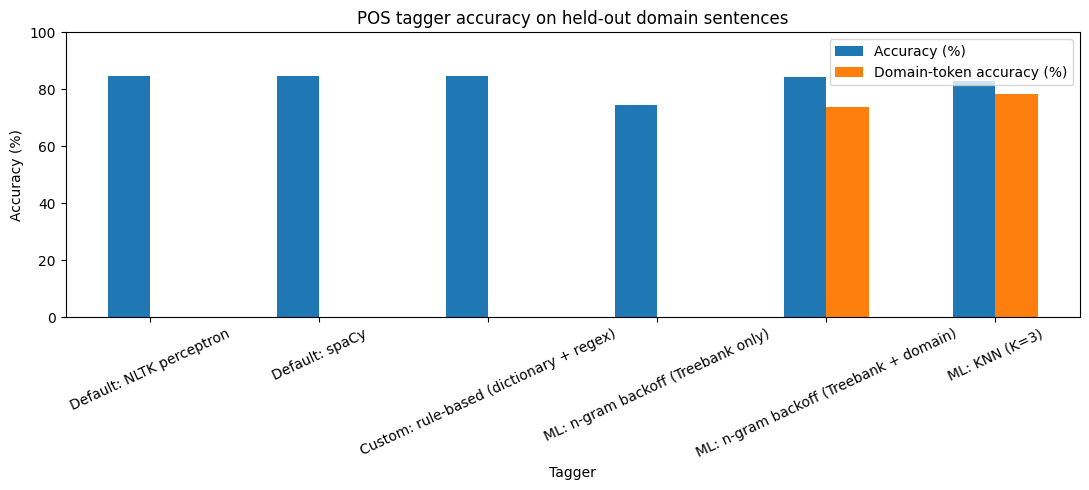

In [90]:
# Results Table D: every domain token in the held-out sentences, default taggers vs our custom tagger
table_d_rows = []
for sent in domain_test:
    words = [w for w, _ in sent]
    for (word, gold), d, s, c in zip(sent, nltk_tags(words), spacy_tags(words), rule_based_tags(words)):
        if is_domain_token(word):
            table_d_rows.append({"Word": word, "Gold POS": gold,
                                 "Default POS (NLTK)": d, "Default POS (spaCy)": s, "Custom POS (rule-based)": c,
                                 "NLTK": "Correct" if d == gold else "Incorrect",
                                 "spaCy": "Correct" if s == gold else "Incorrect",
                                 "Custom": "Correct" if c == gold else "Incorrect"})
table_d = pd.DataFrame(table_d_rows)
print(table_d.to_string(index=False))
table_d.to_csv(RESULTS / "pos_tagging_results.csv", index=False)
print("Saved:", RESULTS / "pos_tagging_results.csv")
print("\nCustom tagger errors:\n", table_d[table_d["Custom"] == "Incorrect"][["Word", "Gold POS", "Custom POS (rule-based)"]].to_string(index=False))

# Accuracy + improvement over the BEST default tagger (a fair baseline)
summary = pd.DataFrame([{"Tagger": n, "Accuracy (%)": a, "Domain-token accuracy (%)": d} for n, (a, d) in results.items()])
best_default = summary[summary["Tagger"].str.startswith("Default")][["Accuracy (%)", "Domain-token accuracy (%)"]].max()
summary["Improvement vs best default (pts)"] = (summary["Accuracy (%)"] - best_default["Accuracy (%)"]).round(1)
summary["Domain improvement vs best default (pts)"] = (summary["Domain-token accuracy (%)"] - best_default["Domain-token accuracy (%)"]).round(1)
print("\n" + summary.to_string(index=False))
summary.to_csv(RESULTS / "ex12_tagger_accuracy.csv", index=False)

import matplotlib.pyplot as plt
ax = summary.set_index("Tagger")[["Accuracy (%)", "Domain-token accuracy (%)"]].plot(kind="bar", figsize=(11, 5), rot=25, ylim=(0, 100))
ax.set_ylabel("Accuracy (%)")
ax.set_title("POS tagger accuracy on held-out domain sentences")
plt.tight_layout()
plt.show()


### Exercise 12: Observation and decision

**Gold standard.** 50 seeded sentences with domain terms. Tokens where NLTK and spaCy agree were accepted; every disagreement and every domain token was reviewed by hand using Penn Treebank conventions (proposed by the assistant, approved by us). 30 sentences train the ML taggers; 20 are held out, and **every tagger is scored on the same held-out sentences**. *Limitation:* tokens where both taggers agree were not individually checked.

**What we observe (see output above):**
- Both default taggers are accurate on general English but much weaker on **domain tokens**, and they fail in different ways: NLTK tags imperatives ("Follow", "Learn") and plural acronyms (SSRIs, RCTs) wrongly; spaCy mishandles "e.g./i.e." and acronyms such as NIMH/PTSD.
- Our **rule-based tagger** (NLTK + domain dictionary + regex rules) gives the best overall and domain-token accuracy. Its remaining errors are (i) web addresses: our rule says NNP, while the gold follows the NN convention (we did not change the rule after seeing the test data); (ii) "ways to *self-harm*", a verb use that a context-free dictionary cannot see.
- **ML taggers:** the n-gram backoff tagger trained only on Treebank news text is the weakest; adding 30 domain sentences gives the largest single improvement. KNN performs best at a small K; removing the word and its context features lowers accuracy sharply, so word identity and neighbours carry most of the information.
- The test set holds only a small number of domain tokens, so domain-token percentages change in large steps.

**Decision (C):** we use the **rule-based custom tagger** wherever our project needs POS tags for domain text. It is the most accurate, transparent and fast, and it needs no labelled training data. The ML results show that a learned tagger would need a much larger annotated domain set to compete. Lemmatization in the pipeline stays with spaCy (Exercise 10), whose domain lemma rules already handle plural acronyms.


In [92]:
from nltk import ne_chunk
for resource in ["maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    nltk.download(resource, quiet=True)

NLTK_TO_SPACY = {"ORGANIZATION": "ORG", "LOCATION": "LOC", "FACILITY": "FAC", "GSP": "GPE"}   # one label set for both tools
REQUIRED_TYPES = ["PERSON", "ORG", "GPE", "DATE", "MONEY", "PRODUCT", "EVENT"]

ner_sentences = [(d["doc_id"], s) for d in docs for s in line_then_nltk_sentences(d["text"])]

def spacy_entities(doc):
    return [(ent.text, ent.label_) for ent in doc.ents]

def nltk_entities(sentence):
    """tokenize -> pos_tag -> ne_chunk -> read the labelled subtrees."""
    tree = ne_chunk(nltk.pos_tag(custom_tokenize(sentence)))
    return [(" ".join(word for word, _ in subtree.leaves()), NLTK_TO_SPACY.get(subtree.label(), subtree.label()))
            for subtree in tree if hasattr(subtree, "label")]

spacy_ents = [spacy_entities(doc) for doc in nlp_domain.pipe([s for _, s in ner_sentences], batch_size=256)]
nltk_index = sorted(random.Random(SEED).sample(range(len(ner_sentences)), 1000))   # ne_chunk is slow: seeded sample
nltk_ents = {i: nltk_entities(ner_sentences[i][1]) for i in nltk_index}
print("Sentences:", len(ner_sentences), "| NLTK sample:", len(nltk_ents))

count_rows = []
for system, ent_lists, n_sent in [("spaCy (all sentences)", spacy_ents, len(spacy_ents)),
                                  ("NLTK ne_chunk (sample)", list(nltk_ents.values()), len(nltk_ents))]:
    flat = [e for sent in ent_lists for e in sent]
    labels = Counter(label for _, label in flat)
    for label in REQUIRED_TYPES + sorted(set(labels) - set(REQUIRED_TYPES)):
        top = Counter(text for text, l in flat if l == label).most_common(6)
        count_rows.append({"System": system, "Sentences": n_sent, "Label": label, "Required": label in REQUIRED_TYPES,
                           "Mentions": labels.get(label, 0),
                           "Top entities": " | ".join(f"{t} ({n})" for t, n in top)})
ex13_counts = pd.DataFrame(count_rows)
print(ex13_counts.to_string(index=False, max_colwidth=110))
ex13_counts.to_csv(RESULTS / "ex13_entity_counts.csv", index=False)


Sentences: 3337 | NLTK sample: 1000
                System  Sentences       Label  Required  Mentions                                                                                       Top entities
 spaCy (all sentences)       3337      PERSON      True        97                     Box 3.1 (4) | al. (3) | Psychotherapy (3) | IPT (3) | Email (3) | Tardelli (3)
 spaCy (all sentences)       3337         ORG      True       472                                     GAD (63) | CBT (60) | TAU (32) | NIMH (26) | GP (12) | CC (12)
 spaCy (all sentences)       3337         GPE      True        59  Conditional (15) | Psychotherapy (8) | the United States (6) | al. (3) | Print (3) | Bethesda (3)
 spaCy (all sentences)       3337        DATE      True       324                             2004 (44) | 2020 (24) | 2021 (22) | 2019 (18) | 2023 (16) | daily (11)
 spaCy (all sentences)       3337       MONEY      True         0                                                                          

In [93]:
# Domain entity types that general NER models have no label for, added with an EntityRuler placed before "ner"
DOMAIN_ENTITIES = {
    "CONDITION": ["depression", "anxiety", "PTSD", "GAD", "OCD", "panic disorder", "bipolar disorder", "psychosis", "schizophrenia",
                  "generalised anxiety disorder", "generalized anxiety disorder", "post-traumatic stress disorder",
                  "obsessive-compulsive disorder", "social anxiety disorder", "alcohol use disorder", "eating disorder",
                  "insomnia", "self-harm", "phobia"],
    "MEDICATION": ["SSRI", "SSRIs", "SNRI", "antidepressant", "antidepressants", "benzodiazepine", "benzodiazepines",
                   "sertraline", "fluoxetine", "escitalopram", "citalopram", "paroxetine", "mirtazapine", "venlafaxine",
                   "duloxetine", "naltrexone", "acamprosate", "baclofen", "disulfiram", "diazepam"],
    "THERAPY": ["CBT", "cognitive behavioural therapy", "cognitive behavioral therapy", "talking therapies", "interpersonal therapy",
                "psychotherapy", "counselling", "counseling", "guided self-help", "psychoeducation", "exposure therapy", "mindfulness"],
    "ORG": ["NICE", "NHS", "WHO", "NIMH", "NIH", "SAMHSA", "MHRA", "FDA", "National Institute of Mental Health"],
}
CASE_SENSITIVE = {"WHO", "NICE", "GAD"}            # 'who', 'nice', 'gad' are ordinary words in lower case
DOMAIN_LABELS = ["CONDITION", "MEDICATION", "THERAPY", "HELPLINE"]

nlp_ner = spacy.load("en_core_web_sm")
for term in special_terms:
    nlp_ner.tokenizer.add_special_case(term, [{ORTH: term}])
for number in {m for d in docs for m in re.findall(r"\b1-8\d\d-\d{3}-\d{4}\b", d["text"])}:
    nlp_ner.tokenizer.add_special_case(number, [{ORTH: number}])          # keep US helpline numbers as one token

ruler = nlp_ner.add_pipe("entity_ruler", before="ner")
patterns = []
for label, terms in DOMAIN_ENTITIES.items():
    for term in terms:
        key = "ORTH" if term in CASE_SENSITIVE else "LOWER"
        words = [t.text if key == "ORTH" else t.text.lower() for t in nlp_ner.make_doc(term)]
        patterns.append({"label": label, "pattern": [{key: w} for w in words]})
patterns.append({"label": "HELPLINE", "pattern": [{"TEXT": {"REGEX": r"^(988|1-8\d\d-\d{3}-\d{4})$"}}]})
ruler.add_patterns(patterns)

ruler_ents = [spacy_entities(doc) for doc in nlp_ner.pipe([s for _, s in ner_sentences], batch_size=256)]
flat = [e for sent in ruler_ents for e in sent]
for label in DOMAIN_LABELS + ["ORG"]:
    top = Counter(t for t, l in flat if l == label).most_common(8)
    print(f"{label:10} {sum(1 for _, l in flat if l == label):5} | " + " | ".join(f"{t} ({n})" for t, n in top))

# What did the DEFAULT model do with these domain entities? (missed, or given a wrong general label)
gap = Counter()
for d_ents, r_ents in zip(spacy_ents, ruler_ents):
    default = dict(d_ents)
    for text, label in r_ents:
        if label in DOMAIN_LABELS or (label == "ORG" and text in DOMAIN_ENTITIES["ORG"]):
            gap[(text, label, default.get(text, "missed"))] += 1
gap_df = pd.DataFrame([{"Entity": t, "Domain label": l, "Default spaCy label": d, "Mentions": n}
                       for (t, l, d), n in gap.most_common()])
print("\nDefault spaCy treatment of domain entities (mentions):")
print(gap_df.groupby("Default spaCy label")["Mentions"].sum().sort_values(ascending=False).to_string())
print(gap_df.head(25).to_string(index=False))
gap_df.to_csv(RESULTS / "ex13_domain_entities.csv", index=False)


CONDITION    572 | depression (179) | anxiety (97) | GAD (66) | panic disorder (56) | PTSD (46) | self-harm (33) | Depression (26) | generalized anxiety disorder (15)
MEDICATION   322 | antidepressants (76) | antidepressant (46) | SSRIs (40) | Antidepressants (13) | naltrexone (13) | sertraline (12) | baclofen (12) | fluoxetine (11)
THERAPY      174 | CBT (60) | psychotherapy (31) | cognitive behavioural therapy (16) | mindfulness (11) | Psychotherapy (11) | guided self-help (7) | psychoeducation (6) | counselling (6)
HELPLINE      21 | 988 (17) | 1-866-615-6464 (3) | 1-800-662-4357 (1)
ORG          360 | TAU (32) | NIMH (29) | WHO (19) | National Institute of Mental Health (16) | GP (12) | CC (12) | NHS (10) | Focus (9)

Default spaCy treatment of domain entities (mentions):
Default spaCy label
missed      960
ORG         189
CARDINAL     18
GPE           9
DATE          6
PERSON        4
                             Entity Domain label Default spaCy label  Mentions
                  

In [94]:
# 40 seeded sentences that any system tagged, or that contain a capitalised word / digit mid-sentence
# (so the sample also contains entities that every system MISSED)
pool = [i for i, (_, s) in enumerate(ner_sentences)
        if 6 <= len(s.split()) <= 35
        and (spacy_ents[i] or ruler_ents[i] or any(w[:1].isupper() or any(ch.isdigit() for ch in w) for w in s.split()[1:]))]
ner_sample = random.Random(SEED).sample(pool, 40)

fmt = lambda ents: " ; ".join(f"{t} [{l}]" for t, l in ents)
ner_review = pd.DataFrame([{"sent_id": k, "doc_id": ner_sentences[i][0], "sentence": ner_sentences[i][1],
                            "spacy": fmt(spacy_ents[i]), "nltk": fmt(nltk_entities(ner_sentences[i][1])),
                            "spacy_domain": fmt(ruler_ents[i])}
                           for k, i in enumerate(ner_sample)])
ner_review.to_csv(RESULTS / "ner_gold_candidates.csv", index=False)
print("Pool:", len(pool), "| saved", len(ner_review), "sentences ->", RESULTS / "ner_gold_candidates.csv")


Pool: 1090 | saved 40 sentences -> c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ner_gold_candidates.csv


In [95]:
from nltk.util import ngrams

# n-grams INSIDE sentences/lines (never across a heading or sentence boundary), on content tokens:
# number policy -> custom tokenizer -> lowercase -> no punctuation. Stop words KEPT so phrases stay readable.
ngram_sents = [toks for d in docs for s in line_then_nltk_sentences(d["text"]) if (toks := content_tokens(s))]

def is_phrase(gram):
    """'Meaningful' phrase = does not start or end with a stop word (filters 'of the', 'you can')."""
    return gram[0] not in CUSTOM_STOPWORDS and gram[-1] not in CUSTOM_STOPWORDS

NAMES = {1: "Unigram", 2: "Bigram", 3: "Trigram", 4: "4-gram", 5: "5-gram"}
ngram_counts, summary_rows, top_rows = {}, [], []
for n, name in NAMES.items():
    counts = Counter(g for s in ngram_sents for g in ngrams(s, n))
    ngram_counts[n] = counts
    total = sum(counts.values())
    phrases = Counter({g: c for g, c in counts.items() if is_phrase(g)})
    summary_rows.append({"N-gram": name, "Total count": total, "Unique count": len(counts),
                         "Seen once (%)": round(100 * sum(c == 1 for c in counts.values()) / len(counts), 1),
                         "Top 10 (raw)": " | ".join(" ".join(g) for g, _ in counts.most_common(10)),
                         "Top 10 phrases": " | ".join(" ".join(g) for g, _ in phrases.most_common(10))})
    for kind, source in [("raw", counts), ("phrase", phrases)]:
        for rank, (g, c) in enumerate(source.most_common(10), 1):
            top_rows.append({"n": n, "N-gram type": name, "List": kind, "Rank": rank, "N-gram": " ".join(g),
                             "Frequency": c, "Relative frequency (%)": round(100 * c / total, 3)})

top_ngrams = pd.DataFrame(top_rows)
for n, name in NAMES.items():
    print(f"\n=== {name}: top 10 raw | top 10 phrases ===")
    raw = top_ngrams.query("n == @n and List == 'raw'")[["N-gram", "Frequency"]].reset_index(drop=True)
    phr = top_ngrams.query("n == @n and List == 'phrase'")[["N-gram", "Frequency"]].reset_index(drop=True)
    print(pd.concat([raw, phr], axis=1, keys=["raw", "phrase"]).to_string())

ngram_summary = pd.DataFrame(summary_rows)
print("\n" + ngram_summary[["N-gram", "Total count", "Unique count", "Seen once (%)"]].to_string(index=False))

# Results Table F checkpoints
for n, file in [(1, "unigram_results.csv"), (2, "bigram_results.csv"), (3, "trigram_results.csv")]:
    top_ngrams.query("n == @n").to_csv(RESULTS / file, index=False)
ngram_summary.to_csv(RESULTS / "ngram_results.csv", index=False)
top_ngrams.to_csv(RESULTS / "ex14_top_ngrams.csv", index=False)
print("Saved: unigram/bigram/trigram_results.csv, ngram_results.csv, ex14_top_ngrams.csv")



=== Unigram: top 10 raw | top 10 phrases ===
     raw                   phrase          
  N-gram Frequency         N-gram Frequency
0    and      1280      treatment       377
1     of      1133            can       308
2    the      1130         health       273
3     to      1055            may       268
4     or       767  interventions       254
5     in       658            not       213
6    for       632     depression       205
7   with       632            use       197
8      a       595         should       194
9     be       410       symptoms       187

=== Bigram: top 10 raw | top 10 phrases ===
             raw                                 phrase          
          N-gram Frequency                       N-gram Frequency
0  mental health       122                mental health       122
1         of the       116  psychological interventions        70
2      should be       112                  health care        60
3         may be       110               panic diso

                                    Dictionary  Size  x term dictionary
Term-based (lemmas, custom stop words removed)  2919                1.0
     Unigram (content tokens, stop words kept)  3662                1.3
      Bigram (content tokens, stop words kept) 16632                5.7
     Trigram (content tokens, stop words kept) 23079                7.9
      4-gram (content tokens, stop words kept) 23852                8.2
      5-gram (content tokens, stop words kept) 22886                7.8


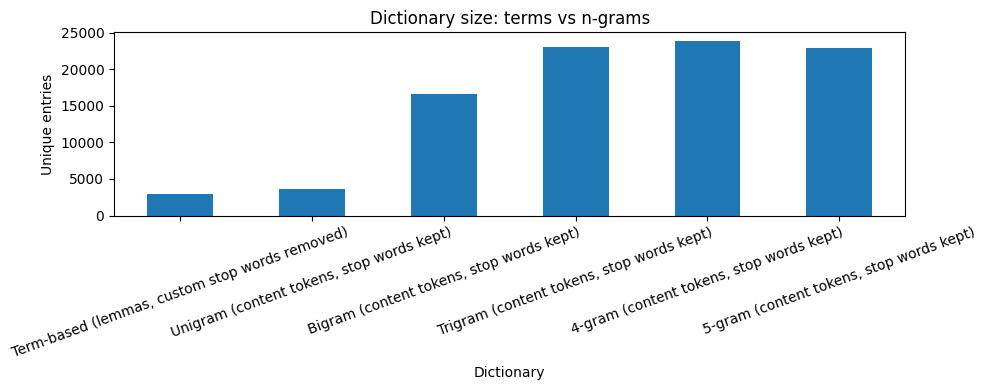

In [96]:
term_dictionary = {t for toks in processed_docs.values() for t in toks}       # final preprocessing (Pipeline B)
size_rows = [{"Dictionary": "Term-based (lemmas, custom stop words removed)", "Size": len(term_dictionary)}]
for n, name in NAMES.items():
    size_rows.append({"Dictionary": f"{name} (content tokens, stop words kept)", "Size": len(ngram_counts[n])})
dict_sizes = pd.DataFrame(size_rows)
dict_sizes["x term dictionary"] = (dict_sizes["Size"] / len(term_dictionary)).round(1)
print(dict_sizes.to_string(index=False))
dict_sizes.to_csv(RESULTS / "ex14_dictionary_sizes.csv", index=False)

import matplotlib.pyplot as plt
ax = dict_sizes.set_index("Dictionary")["Size"].plot(kind="bar", figsize=(10, 4), rot=20)
ax.set_ylabel("Unique entries")
ax.set_title("Dictionary size: terms vs n-grams")
plt.tight_layout()
plt.show()


In [97]:
ner_gold = pd.read_csv(RESULTS / "ner_gold.csv", keep_default_na=False)
gold_by_sent = {k: [(r.entity, r.label) for r in g.itertuples() if r.entity] for k, g in ner_gold.groupby("sent_id")}

ALL_TYPES = REQUIRED_TYPES + DOMAIN_LABELS          # CARDINAL, PERCENT, TIME, ... are out of scope
systems = {"spaCy (default)": lambda i: spacy_ents[i],
           "NLTK ne_chunk (default)": lambda i: nltk_entities(ner_sentences[i][1]),
           "spaCy + domain EntityRuler (custom)": lambda i: ruler_ents[i]}

def score(pred, gold):
    """Exact span + label match, counted with multiplicity."""
    p, g = Counter(pred), Counter(gold)
    correct = sum((p & g).values())
    return correct, sum(p.values()) - correct, sum(g.values()) - correct

rows, errors = [], []
for scope, types in [("Required types only", REQUIRED_TYPES), ("Required + domain types", ALL_TYPES)]:
    for name, predict in systems.items():
        correct = incorrect = missed = 0
        for k, i in enumerate(ner_sample):
            pred = [e for e in predict(i) if e[1] in types]
            gold = [e for e in gold_by_sent.get(k, []) if e[1] in types]
            c, w, m = score(pred, gold)
            correct, incorrect, missed = correct + c, incorrect + w, missed + m
            if scope == "Required + domain types":
                errors += [{"System": name, "sent_id": k, "Entity": t, "Label": l, "Error": "incorrect"}
                           for t, l in (Counter(pred) - Counter(gold)).elements()]
                errors += [{"System": name, "sent_id": k, "Entity": t, "Label": l, "Error": "missed"}
                           for t, l in (Counter(gold) - Counter(pred)).elements()]
        precision = correct / (correct + incorrect) if correct + incorrect else 0
        recall = correct / (correct + missed) if correct + missed else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
        rows.append({"Scope": scope, "System": name, "Total predicted": correct + incorrect, "Gold entities": correct + missed,
                     "Correct": correct, "Incorrect": incorrect, "Missed": missed,
                     "Precision": round(precision, 2), "Recall": round(recall, 2), "F1": round(f1, 2)})

table_e = pd.DataFrame(rows)
print(table_e.to_string(index=False))
table_e.to_csv(RESULTS / "ner_results.csv", index=False)

error_df = pd.DataFrame(errors)
print("\nErrors of the custom system:")
print(error_df[error_df["System"].str.startswith("spaCy + domain")].to_string(index=False))
error_df.to_csv(RESULTS / "ex13_ner_errors.csv", index=False)
print("Saved:", RESULTS / "ner_results.csv", "and ex13_ner_errors.csv")


                  Scope                              System  Total predicted  Gold entities  Correct  Incorrect  Missed  Precision  Recall   F1
    Required types only                     spaCy (default)               32             29       17         15      12       0.53    0.59 0.56
    Required types only             NLTK ne_chunk (default)               33             29        8         25      21       0.24    0.28 0.26
    Required types only spaCy + domain EntityRuler (custom)               28             29       18         10      11       0.64    0.62 0.63
Required + domain types                     spaCy (default)               32             74       17         15      57       0.53    0.23 0.32
Required + domain types             NLTK ne_chunk (default)               33             74        8         25      66       0.24    0.11 0.15
Required + domain types spaCy + domain EntityRuler (custom)               64             74       51         13      23       0.80    0.

In [98]:
# Frequency distribution: how many unique n-grams occur once, twice, 3-5, 6-10, >10 times
bins = [("1", 1, 1), ("2", 2, 2), ("3-5", 3, 5), ("6-10", 6, 10), (">10", 11, float("inf"))]
freq_rows = []
for n, name in NAMES.items():
    values = list(ngram_counts[n].values())
    row = {"N-gram": name}
    for label, low, high in bins:
        row[f"Seen {label}x (%)"] = round(100 * sum(low <= v <= high for v in values) / len(values), 1)
    # Formula from the reference lab: a sentence of N tokens gives N - n + 1 n-grams
    row["Formula check (N - n + 1)"] = sum(max(len(s) - n + 1, 0) for s in ngram_sents) == sum(values)
    freq_rows.append(row)

ngram_freq = pd.DataFrame(freq_rows)
print(ngram_freq.to_string(index=False))
ngram_freq.to_csv(RESULTS / "ex14_frequency_distribution.csv", index=False)
print("Saved:", RESULTS / "ex14_frequency_distribution.csv")


 N-gram  Seen 1x (%)  Seen 2x (%)  Seen 3-5x (%)  Seen 6-10x (%)  Seen >10x (%)  Formula check (N - n + 1)
Unigram         40.6         13.7           17.6            11.4           16.7                       True
 Bigram         67.0         14.8           11.7             4.1            2.3                       True
Trigram         80.2         11.5            6.3             1.7            0.4                       True
 4-gram         85.4          9.0            4.4             1.0            0.2                       True
 5-gram         87.6          7.9            3.5             0.9            0.1                       True
Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_Analysis_Retrieval\results\ex14_frequency_distribution.csv


**Evaluation (Table E).** 40 seeded sentences, gold entities proposed by the assistant and approved by us; exact span + label match; numbers such as citation markers are out of scope.
- **Required types only:** the custom system is slightly better than default spaCy, because the ruler takes acronyms such as GAD and CBT away from the wrong ORG label. NLTK is far behind: most of its predictions are capitalised ordinary words labelled GPE or PERSON.
- **Required + domain types:** the default models cannot predict any domain label, so their recall collapses. The custom system has the highest precision, recall and F1.
- **Remaining errors of the custom system (see error list):** (i) errors inherited from spaCy's general model on citation names ("Chan et al." span, "Buchholz" as GPE, "Boumparis N" as ORG), which the ruler does not touch; (ii) dictionary limits: unlisted words (fluvoxamine, amitriptyline, TCAs, hypersomnia, brain stimulation therapy), plurals ("eating disorders"), span boundaries ("Major depression"), and context the ruler cannot see ("people who self-harm" is a verb).
- *Limitation:* the gold set is small, and one annotator (with review) labelled it.


### Module 3: Comparison and selection (Table H)

**Setup.** All pipelines share extraction, cleaning, number policy, the custom tokenizer, lowercasing and punctuation removal; they differ only in the branch of the diagram and its order. They run per sentence on the same corpus.

**What we observe (see Table H and the outputs above):**
- **Token count:** C keeps every token, so its index would be the largest and full of function words; A and B remove a similar share.
- **Vocabulary size:** A (stemming) has the smallest vocabulary, but a large part of it is not real words (*antidepress, anxieti, disord*). B's vocabulary is only slightly larger and almost entirely readable.
- **N-gram quality:** C's top bigrams are function-word pairs ("do not", "there be"); A's are domain pairs, but as stems (*psychosoci intervent*); B's are readable domain phrases (*panic disorder, side effect, drug use*).
- **Domain terms:** A removes negation and modals, so "do not stop taking" becomes "stop take" and "should not be used" becomes "use", which reverses safety advice. B keeps "not stop take" and "should not use", and normalises SSRIs → ssri and antidepressants → antidepressant. (The only term B "fails" in the readability check is *should*, which is not a WordNet entry.)
- **Order matters (B vs B-reordered):** the same steps in a different order change lemmas in a noticeable share of sentences. Lemmatizing after stop-word removal leaves inflections unmerged (*outcomes, tapering, discontinuities*) and gives a larger vocabulary, because spaCy tags words in broken sentences.
- **Defect found and fixed:** the comparison showed spaCy turning *self-harmed* into the non-word *self-harme*. We added domain lemma rules (Exercise 10) so self-harmed / self-harming / self-harms → *self-harm*.

**Selection: Pipeline B** (number policy → custom tokenizer → lowercase → no punctuation → spaCy lemmas in context → custom stop words removed). It gives readable terms and readable phrases, preserves negation and modal strength, and keeps domain terms intact, at a vocabulary only slightly larger than stemming. Its cost is speed (spaCy is much slower than a stemmer), paid once at indexing time and negligible for a single query. The same `pipeline()` function processes documents and queries in Modules 4–6, as the query trace shows.


In [99]:
# All pipelines share the front of the diagram: cleaned text -> number policy -> custom tokenizer -> lowercase -> no punctuation
# (content_tokens). They differ only in stop-word removal and normalisation, and in their ORDER.
SNOWBALL = stemmers["Snowball"]

def pipeline_a(text):
    """A (diagram, left): NLTK stop words removed -> Snowball stemming."""
    return [SNOWBALL.stem(t) for t in content_tokens(text) if t not in NLTK_STOPWORDS]

def pipeline_b(text):
    """B (ours = final_preprocess): spaCy lemmas in context -> custom stop words removed (by surface form)."""
    return final_preprocess(text)

def pipeline_b_reordered(text):
    """B with the ORDER changed: custom stop words removed BEFORE lemmatization (spaCy loses sentence context)."""
    tokens = [t for t in content_tokens(text) if t not in CUSTOM_STOPWORDS]
    return lemmas_spacy(tokens) if tokens else []

def pipeline_c(text):
    """C (diagram, right): NO stop-word removal -> spaCy lemmas in context."""
    tokens = content_tokens(text)
    return lemmas_spacy(tokens) if tokens else []

PIPELINES = {"A: NLTK stop words -> Snowball": pipeline_a,
             "B: lemma -> custom stop words (ours)": pipeline_b,
             "B-reordered: custom stop words -> lemma": pipeline_b_reordered,
             "C: no stop words removed -> lemma": pipeline_c}

# Run per sentence, so n-grams never cross a sentence or heading boundary (takes a few minutes: spaCy runs 3 times)
module3_sents = [s for d in docs for s in line_then_nltk_sentences(d["text"])]
pipeline_output, pipeline_time = {}, {}
for name, run in PIPELINES.items():
    start = time.time()
    pipeline_output[name] = [run(s) for s in module3_sents]
    pipeline_time[name] = round(time.time() - start, 1)
    print(f"{name:42} done in {pipeline_time[name]} s")


A: NLTK stop words -> Snowball             done in 0.6 s
B: lemma -> custom stop words (ours)       done in 30.1 s
B-reordered: custom stop words -> lemma    done in 27.4 s
C: no stop words removed -> lemma          done in 29.2 s


In [100]:
from nltk.corpus import wordnet as wn
from nltk.util import ngrams

# A term is "readable" if it is a real word (WordNet), a known domain term, or a number we kept (doses, helplines)
KNOWN_TERMS = ({w.lower() for terms in DOMAIN_ENTITIES.values() for term in terms for w in term.split()}
               | {t.lower() for t in special_terms})
def is_readable(word):
    return word in KNOWN_TERMS or any(ch.isdigit() for ch in word) or bool(wn.synsets(word))

def is_meaningful_bigram(gram):
    """Both words are content words AND readable (filters 'of the' and stems like 'anxieti disord')."""
    return all(w not in NLTK_STOPWORDS and is_readable(w) for w in gram)

NEGATIONS = {"not", "no", "never", "without", "cannot"}
DOMAIN_CHECK = ["SSRIs", "self-harm", "antidepressants", "anxiety", "generalised anxiety disorder", "panic disorder",
                "PTSD", "CBT", "side effects", "988", "do not stop taking", "should not be used", "talking therapies", "sleeping"]

summary_rows, bigram_rows, term_rows = [], [], []
front_tokens = sum(len(content_tokens(s)) for s in module3_sents)          # tokens before the branch
for name, run in PIPELINES.items():
    sents = pipeline_output[name]
    tokens = [t for s in sents for t in s]
    bigrams = Counter(g for s in sents for g in ngrams(s, 2))
    top20 = bigrams.most_common(20)
    domain_ok = sum(all(is_readable(t) for t in run(term)) and len(run(term)) > 0 for term in DOMAIN_CHECK)
    summary_rows.append({
        "Pipeline": name,
        "Token count": len(tokens),
        "Tokens kept (%)": round(100 * len(tokens) / front_tokens, 1),
        "Vocabulary size": len(set(tokens)),
        "Readable vocabulary (%)": round(100 * sum(map(is_readable, set(tokens))) / len(set(tokens)), 1),
        "Meaningful top-20 bigrams": sum(is_meaningful_bigram(g) for g, _ in top20),
        "Negation bigrams (occurrences)": sum(c for g, c in bigrams.items() if g[0] in NEGATIONS),
        f"Domain terms readable (of {len(DOMAIN_CHECK)})": domain_ok,
        "Time (s)": pipeline_time[name]})
    for rank, (g, c) in enumerate(bigrams.most_common(10), 1):
        bigram_rows.append({"Pipeline": name, "Rank": rank, "Bigram": " ".join(g), "Frequency": c, "Meaningful": is_meaningful_bigram(g)})

for term in DOMAIN_CHECK:
    term_rows.append({"Domain term / phrase": term, **{name: " ".join(run(term)) or "(removed)" for name, run in PIPELINES.items()}})

table_h = pd.DataFrame(summary_rows)
print(table_h.to_string(index=False))
print("\nWhat each pipeline does to domain terms:")
print(pd.DataFrame(term_rows).to_string(index=False))
top_bigrams = pd.DataFrame(bigram_rows)
print("\nTop 10 bigrams per pipeline:")
print(top_bigrams.pivot(index="Rank", columns="Pipeline", values="Bigram").to_string())

table_h.to_csv(RESULTS / "pipeline_comparison.csv", index=False)
pd.DataFrame(term_rows).to_csv(RESULTS / "module3_domain_terms.csv", index=False)
top_bigrams.to_csv(RESULTS / "module3_top_bigrams.csv", index=False)
print("\nSaved: pipeline_comparison.csv (Table H), module3_domain_terms.csv, module3_top_bigrams.csv")


                               Pipeline  Token count  Tokens kept (%)  Vocabulary size  Readable vocabulary (%)  Meaningful top-20 bigrams  Negation bigrams (occurrences)  Domain terms readable (of 14)  Time (s)
         A: NLTK stop words -> Snowball        24570             62.0             2535                     56.3                          7                              26                              9       0.6
   B: lemma -> custom stop words (ours)        24913             62.8             2914                     90.5                         17                             320                             13      30.1
B-reordered: custom stop words -> lemma        24913             62.8             2940                     90.5                         17                             320                             13      27.4
      C: no stop words removed -> lemma        39660            100.0             3011                     89.5                          5              

In [101]:
# Same tokens survive in both (same stop list), so we can compare lemma by lemma
changes = Counter()
changed_sents = 0
for s_b, s_r in zip(pipeline_output["B: lemma -> custom stop words (ours)"],
                    pipeline_output["B-reordered: custom stop words -> lemma"]):
    diff = [(a, b) for a, b in zip(s_b, s_r) if a != b]
    changed_sents += bool(diff)
    changes.update(diff)
print(f"Sentences with at least one different lemma: {changed_sents} of {len(module3_sents)}")
print("Most frequent differences (lemma in context -> lemma after stop words removed first):")
for (a, b), n in changes.most_common(15):
    print(f"  {a:18} -> {b:18} {n}")


Sentences with at least one different lemma: 231 of 3337
Most frequent differences (lemma in context -> lemma after stop words removed first):
  structured         -> structure          12
  self-harme         -> self-harmed        11
  thinking           -> think              6
  discontinuity      -> discontinuities    5
  combined           -> combine            5
  warn               -> warning            5
  informed           -> inform             4
  monitoring         -> monitor            4
  individual's       -> individual'        3
  taper              -> tapering           3
  screening          -> screen             3
  prescribe          -> prescribing        3
  outcome            -> outcomes           3
  supervise          -> supervised         3
  verify             -> verifying          3


In [102]:
# SELECTED: Pipeline B. One function for documents AND queries (Modules 4-6 and the GUI).
def pipeline(text):
    return pipeline_b(text)

def trace_pipeline(text):
    """Show the output after every stage, for one example (useful for the report and the viva)."""
    step1 = apply_number_policy(text)
    step2 = custom_tokenize(step1)
    step3 = [t.lower() for t in step2 if any(ch.isalnum() for ch in t)]
    step4 = lemmas_spacy(step3) if step3 else []
    step5 = [l for t, l in zip(step3, step4) if t not in CUSTOM_STOPWORDS]
    for label, value in [("Original", text), ("1 Number policy", step1), ("2 Custom tokenizer", step2),
                         ("3 Lowercase, no punctuation", step3), ("4 spaCy lemmas (in context)", step4),
                         ("5 Custom stop words removed", step5)]:
        print(f"{label:30}: {value}")
    assert step5 == pipeline(text)                       # the trace is the real pipeline

trace_pipeline(find_sentence("D14", "coming off"))
print()
trace_pipeline("I don't want to stop my SSRIs suddenly, what should I do?")


Original                      : Stopping or coming off antidepressants
1 Number policy               : Stopping or coming off antidepressants
2 Custom tokenizer            : ['Stopping', 'or', 'coming', 'off', 'antidepressants']
3 Lowercase, no punctuation   : ['stopping', 'or', 'coming', 'off', 'antidepressants']
4 spaCy lemmas (in context)   : ['stop', 'or', 'come', 'off', 'antidepressant']
5 Custom stop words removed   : ['stop', 'come', 'off', 'antidepressant']

Original                      : I don't want to stop my SSRIs suddenly, what should I do?
1 Number policy               : I don't want to stop my SSRIs suddenly, what should I do?
2 Custom tokenizer            : ['I', 'do', 'not', 'want', 'to', 'stop', 'my', 'SSRIs', 'suddenly', ',', 'what', 'should', 'I', 'do', '?']
3 Lowercase, no punctuation   : ['i', 'do', 'not', 'want', 'to', 'stop', 'my', 'ssris', 'suddenly', 'what', 'should', 'i', 'do']
4 spaCy lemmas (in context)   : ['i', 'do', 'not', 'want', 'to', 'stop', 'my', 's

### Module 3: Comparison and selection (Table H)

**Setup.** All pipelines share extraction, cleaning, number policy, the custom tokenizer, lowercasing and punctuation removal; they differ only in the branch of the diagram and its order. They run per sentence on the same corpus.

**What we observe (see Table H and the outputs above):**
- **Token count:** C keeps every token, so its index would be the largest and dominated by function words. A removes the most, including "not".
- **Vocabulary size:** stemming (A) merges forms aggressively, giving a smaller vocabulary, but many entries are not real words (anxieti, generalis), so they cannot be shown to a user or checked by a reader. B merges forms into real words.
- **N-gram quality:** C's top bigrams are function-word pairs ("of the", "such as"). A's are domain pairs, but as stems. B's are readable domain phrases. Removing stop words can join words that were not adjacent in the text; B limits this by keeping negation and modals.
- **Domain terms:** A drops negation ("do not stop taking" becomes "stop take"), which reverses safety advice; B keeps "not" and turns SSRIs into one readable term, ssri.
- **Order matters (B vs B-reordered):** with the same steps and the same stop list, removing stop words *before* lemmatization changes some lemmas, because spaCy tags words in broken sentences (see the list of differences). Lemmatization therefore stays before stop-word removal.

**Selection: Pipeline B** (number policy → custom tokenizer → lowercase → no punctuation → spaCy lemmas in context → custom stop words removed). It gives readable terms, preserves negation and modal strength, and keeps domain terms intact, at a moderate vocabulary size. Its cost is speed (spaCy is slower than a stemmer), which matters only once, at indexing time. The same `pipeline()` function processes documents and queries in Modules 4–6.
**Known limitation:** spaCy lemmatizes *self-harmed* as the non-word *self-harme*. A domain lemma rule (self-harmed / self-harming → self-harm) would fix it; it affects one term and is noted as future work.



# Module 4: Information Retrieval

**Index design (C).** A **positional inverted index**: term → document → list of positions. A plain document list (as in the AS1 example) answers keyword and Boolean queries; positions are needed for **phrase search**, which replaces storing an n-gram dictionary (Exercise 14).

- **Terms** come from the selected Pipeline B (Module 3); **queries use the same `pipeline()`**, so "Antidepressants" in a query matches "antidepressant" in the index.
- **Positions** count terms after stop-word removal, so the phrase "side effects of medication" is matched as *side effect medication*, the same way in documents and queries.
- **Sentence boundaries:** positions jump by one between sentences, so a phrase can never match across two sentences or across a heading.
- **Retrieval unit** = document (D01…D25), as in the AS1 example. The first matching sentence is shown as a snippet.

**Query operators:** AND, OR and NOT must be written in **CAPITALS**, because lower-case "not" is a search term in our pipeline (negation is kept). Quotes mark a phrase. Unquoted words next to each other must all appear (implicit AND). Brackets are supported, with precedence NOT > AND > OR.


In [108]:
import json, math
from collections import defaultdict

# Pipeline B output per sentence (computed in Module 3) + the document each sentence belongs to
sent_doc_ids = [d["doc_id"] for d in docs for s in line_then_nltk_sentences(d["text"])]
b_terms = pipeline_output["B: lemma -> custom stop words (ours)"]
assert len(sent_doc_ids) == len(b_terms) == len(module3_sents)

SENTENCE_GAP = 1                                       # a phrase can never match across a sentence boundary
postings = defaultdict(lambda: defaultdict(list))      # term -> doc_id -> [positions]
doc_sentences = defaultdict(list)                      # doc_id -> [(first pos, last pos, sentence)] for snippets
doc_length, next_pos = Counter(), Counter()
for doc_id, sentence, terms in zip(sent_doc_ids, module3_sents, b_terms):
    start = next_pos[doc_id]
    for offset, term in enumerate(terms):
        postings[term][doc_id].append(start + offset)
    if terms:
        doc_sentences[doc_id].append((start, start + len(terms) - 1, sentence))
    next_pos[doc_id] = start + len(terms) + SENTENCE_GAP
    doc_length[doc_id] += len(terms)

index = {term: dict(docs_pos) for term, docs_pos in sorted(postings.items())}   # plain dict: lookups never add terms
ALL_DOCS = {d["doc_id"] for d in docs}
TITLES = {d["doc_id"]: d["title"] for d in docs}

# Posting lists in the AS1 format: term -> documents
for term in ["depression", "anxiety", "ssri", "self-harm", "naltrexone", "988", "not"]:
    print(f"{term:12} -> {', '.join(sorted(index.get(term, {})))}")

df = {term: len(p) for term, p in index.items()}
index_stats = pd.DataFrame([{
    "Documents": len(ALL_DOCS),
    "Vocabulary (terms)": len(index),
    "Postings (term-document pairs)": sum(df.values()),
    "Positions stored": sum(len(pos) for p in index.values() for pos in p.values()),
    "Avg documents per term": round(sum(df.values()) / len(index), 2),
    "Terms in only 1 document (%)": round(100 * sum(v == 1 for v in df.values()) / len(index), 1),
    "Terms in every document": sum(v == len(ALL_DOCS) for v in df.values())}]).T
print("\n" + index_stats.to_string(header=False))
print("\nMost widespread terms:", ", ".join(f"{t} ({n})" for t, n in sorted(df.items(), key=lambda x: -x[1])[:12]))

with open(RESULTS / "inverted_index.json", "w", encoding="utf-8") as f:
    json.dump({"documents": {d: {"title": TITLES[d], "length": doc_length[d]} for d in sorted(ALL_DOCS)},
               "index": index}, f, ensure_ascii=False)
index_stats.to_csv(RESULTS / "index_statistics.csv", header=False)
print("\nSaved:", RESULTS / "inverted_index.json", "and index_statistics.csv")


depression   -> D01, D02, D03, D04, D06, D07, D08, D09, D10, D11, D12, D13, D14, D16, D25
anxiety      -> D01, D02, D03, D04, D07, D08, D09, D10, D12, D13, D14, D16, D17
ssri         -> D01, D02, D04, D06, D08, D09, D14
self-harm    -> D02, D03, D04, D06, D14
naltrexone   -> D24, D25
988          -> D07, D08, D09, D10, D11, D16
not          -> D01, D02, D03, D04, D06, D07, D08, D09, D10, D11, D12, D13, D14, D16, D17, D24, D25

Documents                          17.00
Vocabulary (terms)               2914.00
Postings (term-document pairs)   8125.00
Positions stored                24913.00
Avg documents per term              2.79
Terms in only 1 document (%)       51.40
Terms in every document            10.00

Most widespread terms: also (17), can (17), health (17), help (17), may (17), mental (17), more (17), need (17), not (17), social (17), problem (16), risk (16)

Saved: c:\Users\Lenovo\OneDrive\Desktop\sem 7\NLP\Assigmnet 1\as1- tanmayee\Domain_Text_Analysis_Retrieval\Domain_Text_A

In [109]:
N_DOCS = len(ALL_DOCS)

def idf(term):
    n = len(index.get(term, {}))
    return math.log(N_DOCS / n) if n else 0.0

def snippet(doc_id, positions, width=160):
    """First sentence of the document that contains a matched position."""
    first = min(positions)
    for start, end, sentence in doc_sentences[doc_id]:
        if start <= first <= end:
            return sentence if len(sentence) <= width else sentence[:width] + "..."
    return ""

# ---------- Keyword search: documents containing ANY query term, ranked by TF-IDF ----------
def keyword_search(query):
    terms = pipeline(query)
    scores, hits = Counter(), defaultdict(list)
    for term in set(terms):
        for doc_id, pos in index.get(term, {}).items():
            scores[doc_id] += (1 + math.log(len(pos))) * idf(term)     # log-scaled tf x idf
            hits[doc_id] += pos
    return [(doc_id, round(score, 3), snippet(doc_id, hits[doc_id])) for doc_id, score in scores.most_common()], terms

# ---------- Phrase search: query terms at consecutive positions ----------
def phrase_matches(terms):
    """{doc_id: [start positions]} where the terms appear one after another."""
    if not terms or any(t not in index for t in terms):
        return {}
    matches = {}
    for doc_id, first_positions in index[terms[0]].items():
        if all(doc_id in index[t] for t in terms[1:]):
            later = [set(index[t][doc_id]) for t in terms]
            starts = [p for p in first_positions if all(p + k in later[k] for k in range(1, len(terms)))]
            if starts:
                matches[doc_id] = starts
    return matches

def phrase_search(query):
    terms = pipeline(query)
    matches = phrase_matches(terms)
    ranked = sorted(matches.items(), key=lambda x: -len(x[1]))         # more occurrences first
    return [(doc_id, len(starts), snippet(doc_id, starts)) for doc_id, starts in ranked], terms

# ---------- Boolean search: AND / OR / NOT (capitals), quotes = phrase, brackets ----------
PRECEDENCE = {"NOT": 3, "AND": 2, "OR": 1}

def parse_boolean(query):
    """Query -> postfix list (shunting-yard). Adjacent words form one operand; implicit AND between operands."""
    raw = re.findall(r'"[^"]+"|\(|\)|[^\s()"]+', query)
    items = []
    ends_operand = lambda: bool(items) and (items[-1][0] == "operand" or items[-1] == ("op", ")"))
    for tok in raw:
        if tok in ("AND", "OR", ")"):
            items.append(("op", tok))
        elif tok in ("NOT", "("):
            if ends_operand():
                items.append(("op", "AND"))                               # "x NOT y" means "x AND NOT y"
            items.append(("op", tok))
        elif not tok.startswith('"') and items and items[-1][0] == "operand" and not items[-1][1].startswith('"'):
            items[-1] = ("operand", items[-1][1] + " " + tok)            # extend a multi-word operand
        else:
            if ends_operand():
                items.append(("op", "AND"))
            items.append(("operand", tok))
    output, stack = [], []
    for kind, value in items:
        if kind == "operand":
            output.append((kind, value))
        elif value == "(":
            stack.append(value)
        elif value == ")":
            while stack and stack[-1] != "(":
                output.append(("op", stack.pop()))
            if not stack:
                raise ValueError("Unbalanced brackets")
            stack.pop()
        else:
            while stack and stack[-1] != "(" and (PRECEDENCE[stack[-1]] > PRECEDENCE[value]
                                                  or (PRECEDENCE[stack[-1]] == PRECEDENCE[value] and value != "NOT")):
                output.append(("op", stack.pop()))
            stack.append(value)
    while stack:
        if stack[-1] == "(":
            raise ValueError("Unbalanced brackets")
        output.append(("op", stack.pop()))
    return output

def operand_docs(text):
    if text.startswith('"'):                                              # quoted -> phrase
        return set(phrase_matches(pipeline(text.strip('"'))))
    terms = pipeline(text)
    if not terms:                                                         # only stop words
        return set()
    return set.intersection(*[set(index.get(t, {})) for t in terms])      # all words must appear

def boolean_search(query):
    stack = []
    try:
        for kind, value in parse_boolean(query):
            if kind == "operand":
                stack.append(operand_docs(value))
            elif value == "NOT":
                stack.append(ALL_DOCS - stack.pop())
            else:
                right, left = stack.pop(), stack.pop()
                stack.append(left & right if value == "AND" else left | right)
    except IndexError:
        raise ValueError(f"Malformed Boolean query: {query!r}")
    if len(stack) != 1:
        raise ValueError(f"Malformed Boolean query: {query!r}")
    return sorted(stack[0])

def search(query, mode="keyword"):
    """One entry point (used later by the GUI). Returns a DataFrame of results."""
    if mode == "keyword":
        results, _ = keyword_search(query)
        return pd.DataFrame(results, columns=["doc_id", "score", "snippet"]).assign(title=lambda x: x["doc_id"].map(TITLES))
    if mode == "phrase":
        results, _ = phrase_search(query)
        return pd.DataFrame(results, columns=["doc_id", "occurrences", "snippet"]).assign(title=lambda x: x["doc_id"].map(TITLES))
    if mode == "boolean":
        return pd.DataFrame({"doc_id": boolean_search(query)}).assign(title=lambda x: x["doc_id"].map(TITLES))
    raise ValueError("mode must be keyword, phrase or boolean")


In [110]:
demo_queries = [("keyword", "sertraline"),
                ("keyword", "sleep problems"),
                ("phrase", "panic disorder"),
                ("phrase", "side effects of medication"),
                ("phrase", "do not stop"),
                ("boolean", "naltrexone OR acamprosate"),
                ("boolean", "CBT AND depression"),
                ("boolean", "depression NOT antidepressants"),
                ("boolean", '"panic disorder" AND (CBT OR psychotherapy)')]

demo_rows = []
for mode, query in demo_queries:
    result = search(query, mode)
    print(f"\n[{mode.upper()}] {query}   ->   query terms: {pipeline(query.replace('AND', ' ').replace('OR', ' ').replace('NOT', ' '))}")
    print(f"  {len(result)} document(s): {', '.join(result['doc_id'])}")
    if "snippet" in result:
        for _, r in result.head(3).iterrows():
            print(f"   {r['doc_id']} | {r['title'][:55]:55} | {r['snippet'][:110]}")
    demo_rows.append({"Mode": mode, "Query": query, "Documents found": len(result), "Result": ", ".join(result["doc_id"])})

# Phrase vs keyword: what positions add
for q in ["panic disorder", "do not stop"]:
    print(f"\n'{q}': keyword (any term) finds {len(search(q, 'keyword'))} docs | phrase finds {len(search(q, 'phrase'))} docs")

pd.DataFrame(demo_rows).to_csv(RESULTS / "module4_demo_queries.csv", index=False)
print("\nSaved:", RESULTS / "module4_demo_queries.csv")



[KEYWORD] sertraline   ->   query terms: ['sertraline']
  3 document(s): D04, D02, D14
   D04 | mhGAP guideline for mental, neurological and substance  | citalopram, escitalopram, fluoxetine, fluvoxamine, paroxetine and sertraline.
   D02 | Generalised anxiety disorder and panic disorder in adul | of this amendment (June 2020) escitalopram, sertraline, citalopram, paroxetine and venlafaxine are licensed fo
   D14 | Antidepressants (incl. stopping or coming off antidepre | Sertraline

[KEYWORD] sleep problems   ->   query terms: ['sleep', 'problem']
  16 document(s): D17, D04, D07, D08, D09, D16, D14, D06, D01, D02, D10, D25, D03, D12, D24, D11
   D17 | Sleep problems (Every Mind Matters)                     | Sleep problems
   D04 | mhGAP guideline for mental, neurological and substance  | sexual dysfunction, sleep problems, weight gain) and availability (e.g.
   D07 | Depression                                              | It can cause severe symptoms that affect how a person feels

### Module 4: Observation

- **Index (see statistics):** the vocabulary equals Pipeline B's term dictionary. Many terms occur in only one document (drug names, codes, organisation names), while general terms (e.g. *health, treatment, can*) occur in almost every document. That is why ranking uses **IDF**: a term found everywhere does not separate documents.
- **Keyword search** matches *any* query term and ranks documents by log-scaled TF × IDF, so documents that use rare query terms often come first.
- **Phrase search** is much stricter than keyword search for the same words (see the comparison above): "panic disorder" as a phrase excludes documents that only mention *panic* and *disorder* separately. Because negation is kept, the phrase *do not stop* finds advice about not stopping medication, which a standard stop list would make impossible.
- **Boolean search** gives exact, unranked sets; NOT is evaluated against all documents, and brackets control the order (NOT > AND > OR).
- **Limitation:** the retrieval unit is a whole document and the corpus is small, so common terms match most documents. Ranking (keyword mode) and phrase search are what make results discriminative.


# Module 5: Domain-Specific Queries and Module 6: Relevance Set

**Order of work (to avoid bias):** the 14 queries and their relevance judgments are fixed in the next cell **before any retrieval is run on them**. Module 4's demo queries are not reused.

**Queries.** They cover single keywords, multi-word and natural-language keyword queries, phrases, Boolean AND / OR / NOT, and a combined phrase + Boolean query. As in the AS1 examples, related queries build on each other (anxiety → panic disorder / generalised anxiety disorder).

**Relevance judgments.** For each query we wrote an information need and judged every document against it: a document is **relevant** if it gives substantive information answering the need. Passing mentions, citations, cross-references and generic advice ("talk to your doctor") are **not relevant**. The assistant proposed the judgments after reading the relevant passages of each document, and we reviewed and approved them. *Limitation:* binary judgments by one assessor team, on a small corpus.


In [111]:
# (query_id, query, type, search mode, information need, relevant documents). Written BEFORE retrieval.
EVAL_QUERIES = [
    ("Q01", "anxiety", "Keyword", "keyword", "Information about anxiety and anxiety disorders", ["D02", "D04", "D08", "D16"]),
    ("Q02", "panic disorder", "Phrase", "phrase", "Diagnosis and treatment of panic disorder", ["D02", "D04"]),
    ("Q03", "generalised anxiety disorder", "Phrase", "phrase", "Generalised anxiety disorder (GAD)", ["D02", "D04", "D08"]),
    ("Q04", "antidepressant side effects", "Keyword (multi-word)", "keyword", "Side effects of antidepressants", ["D01", "D02", "D04", "D08", "D14"]),
    ("Q05", "how to stop taking antidepressants safely", "Keyword (natural language)", "keyword", "How to stop or come off antidepressants safely", ["D02", "D04", "D14"]),
    ("Q06", "alcohol AND medication", "Boolean AND", "boolean", "Medicines for alcohol use disorders", ["D24"]),
    ("Q07", "suicide OR self-harm", "Boolean OR", "boolean", "Suicide or self-harm: risk, support, treatment", ["D03", "D11"]),
    ("Q08", "depression AND NOT anxiety", "Boolean NOT", "boolean", "Documents dedicated to depression rather than anxiety", ["D01", "D06", "D07"]),
    ("Q09", "trouble sleeping", "Keyword", "keyword", "Help with sleep problems", ["D17"]),
    ("Q10", "PTSD OR trauma", "Boolean OR", "boolean", "Post-traumatic stress disorder", ["D09"]),
    ("Q11", "crisis helpline", "Keyword (natural language)", "keyword", "A phone number to call in a mental-health crisis", ["D07", "D08", "D09", "D10", "D11", "D13", "D14", "D16"]),
    ("Q12", "low self-esteem", "Phrase", "phrase", "Low self-esteem and how to raise it", ["D12"]),
    ("Q13", "loneliness", "Keyword", "keyword", "Help with loneliness", ["D13"]),
    ("Q14", '"drug use disorders" AND psychosocial', "Combined (phrase + AND)", "boolean", "Psychosocial treatment of drug use disorders", ["D25"]),
]

queries_df = pd.DataFrame([{"Query ID": q, "Query": text, "Type": qtype, "Mode": mode, "Information need": need,
                            "Relevant documents": ", ".join(rel), "Number relevant": len(rel)}
                           for q, text, qtype, mode, need, rel in EVAL_QUERIES])
judgments = pd.DataFrame([{"query_id": q, "doc_id": d, "relevant": int(d in rel)}
                          for q, _, _, _, _, rel in EVAL_QUERIES for d in sorted(ALL_DOCS)])
print(queries_df[["Query ID", "Query", "Type", "Relevant documents"]].to_string(index=False))
queries_df.to_csv(RESULTS / "queries.csv", index=False)
judgments.to_csv(RESULTS / "relevance_judgments.csv", index=False)
print("\nSaved: queries.csv and relevance_judgments.csv (every query x document pair judged)")


Query ID                                     Query                       Type                     Relevant documents
     Q01                                   anxiety                    Keyword                     D02, D04, D08, D16
     Q02                            panic disorder                     Phrase                               D02, D04
     Q03              generalised anxiety disorder                     Phrase                          D02, D04, D08
     Q04               antidepressant side effects       Keyword (multi-word)                D01, D02, D04, D08, D14
     Q05 how to stop taking antidepressants safely Keyword (natural language)                          D02, D04, D14
     Q06                    alcohol AND medication                Boolean AND                                    D24
     Q07                      suicide OR self-harm                 Boolean OR                               D03, D11
     Q08                depression AND NOT anxiety              

In [115]:
def run_query(query, mode):
    """Ranked list of doc_ids. Boolean results are an exact set, ordered by the TF-IDF score of the query words
    (so P@K is defined for every query type)."""
    if mode in ("keyword", "phrase"):
        return list(search(query, mode)["doc_id"])
    found = set(boolean_search(query))
    words = re.sub(r'\b(AND|OR|NOT)\b|[()"]', " ", query)
    scores = {doc_id: score for doc_id, score, _ in keyword_search(words)[0]}
    return sorted(found, key=lambda d: (-scores.get(d, 0), d))

def query_shape(text, mode):
    """Query type in the Table I format: Unigram / Bigram / Trigram / Boolean AND / OR / NOT."""
    if mode == "boolean":
        if '"' in text:
            return "Combined (phrase + Boolean)"
        ops = re.findall(r"\b(AND|OR|NOT)\b", text)
        return "Boolean NOT" if "NOT" in ops else "Boolean AND" if "AND" in ops else "Boolean OR"
    n = len(pipeline(text))
    return f"{ {1: 'Unigram', 2: 'Bigram', 3: 'Trigram'}.get(n, f'{n}-gram') } ({mode})"

retrieved, table_i_rows = {}, []
for q, text, qtype, mode, need, rel in EVAL_QUERIES:
    start = time.perf_counter()
    retrieved[q] = run_query(text, mode)
    elapsed_ms = 1000 * (time.perf_counter() - start)
    table_i_rows.append({"Query ID": q, "Query": text, "Query Type": query_shape(text, mode),
                         "Query terms (pipeline)": " ".join(pipeline(re.sub(r'\b(AND|OR|NOT)\b|[()"]', " ", text))),
                         "Retrieved Documents": ", ".join(retrieved[q]) or "(none)",
                         "# Results": len(retrieved[q]), "Time (ms)": round(elapsed_ms, 1)})
table_i = pd.DataFrame(table_i_rows)
print(table_i.to_string(index=False, max_colwidth=60))
table_i.to_csv(RESULTS / "retrieval_results.csv", index=False)
print("\nSaved:", RESULTS / "retrieval_results.csv", "(Table I)")


Query ID                                     Query                  Query Type          Query terms (pipeline)                                          Retrieved Documents  # Results  Time (ms)
     Q01                                   anxiety           Unigram (keyword)                         anxiety D04, D08, D16, D02, D13, D07, D10, D14, D01, D17, D03, D0...         13        6.6
     Q02                            panic disorder             Bigram (phrase)                  panic disorder                                 D04, D02, D03, D07, D09, D14          6        6.8
     Q03              generalised anxiety disorder            Trigram (phrase)    generalised anxiety disorder                                 D08, D04, D02, D03, D07, D14          6        5.8
     Q04               antidepressant side effects           Trigram (keyword)      antidepressant side effect D14, D01, D02, D07, D04, D08, D25, D06, D24, D17, D12, D0...         14        4.7
     Q05 how to stop taking an

Query ID                                     Query                       Type  Precision  Recall   F1  P@3  R@3  P@5  R@5
     Q01                                   anxiety                    Keyword       0.31    1.00 0.47 1.00 0.75 0.80 1.00
     Q02                            panic disorder                     Phrase       0.33    1.00 0.50 0.67 1.00 0.40 1.00
     Q03              generalised anxiety disorder                     Phrase       0.50    1.00 0.67 1.00 1.00 0.60 1.00
     Q04               antidepressant side effects       Keyword (multi-word)       0.36    1.00 0.53 1.00 0.60 0.80 0.80
     Q05 how to stop taking antidepressants safely Keyword (natural language)       0.18    1.00 0.30 0.67 0.67 0.60 1.00
     Q06                    alcohol AND medication                Boolean AND       0.14    1.00 0.25 0.00 0.00 0.00 0.00
     Q07                      suicide OR self-harm                 Boolean OR       0.17    1.00 0.29 0.67 1.00 0.40 1.00
     Q08                

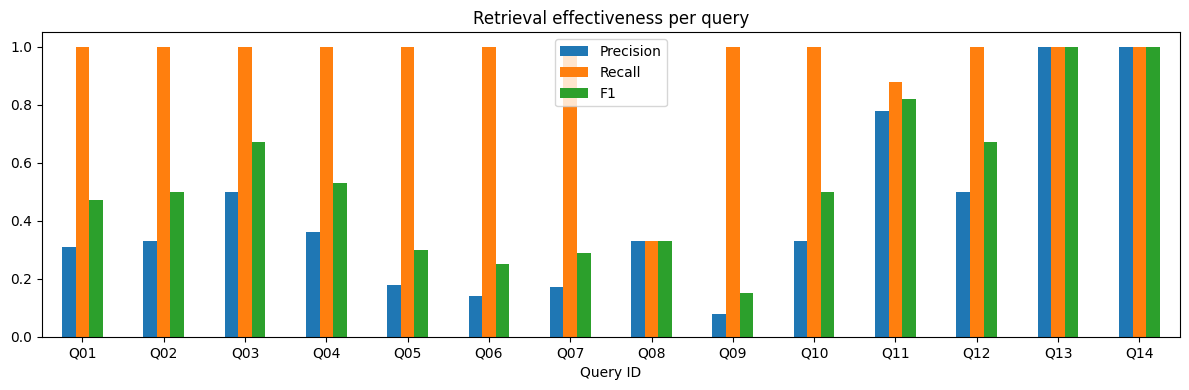

In [119]:
K_VALUES = [3, 5]

def evaluate_query(ranked, relevant):
    rel = set(relevant)
    hits = len(set(ranked) & rel)
    precision = hits / len(ranked) if ranked else 0.0
    recall = hits / len(rel)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    row = {"Retrieved": len(ranked), "Relevant": len(rel), "Relevant retrieved": hits,
           "Precision": precision, "Recall": recall, "F1": f1}
    for k in K_VALUES:
        hits_k = len(set(ranked[:k]) & rel)
        row[f"P@{k}"] = hits_k / k                 # standard definition: divide by K even if fewer were retrieved
        row[f"R@{k}"] = hits_k / len(rel)
    return row

eval_rows, error_rows = [], []
for q, text, qtype, mode, need, rel in EVAL_QUERIES:
    row = {"Query ID": q, "Query": text, "Type": qtype, **evaluate_query(retrieved[q], rel)}
    eval_rows.append(row)
    error_rows.append({"Query ID": q, "Query": text,
                       "Missed (relevant, not retrieved)": ", ".join(sorted(set(rel) - set(retrieved[q]))) or "-",
                       "False positives (retrieved, not relevant)": ", ".join(d for d in retrieved[q] if d not in rel) or "-"})

table_j = pd.DataFrame(eval_rows)
metric_cols = ["Precision", "Recall", "F1"] + [f"{m}@{k}" for k in K_VALUES for m in ("P", "R")]
mean_row = {"Query ID": "MEAN", "Query": "(macro average)", "Type": "all", **table_j[metric_cols].mean().to_dict()}
table_j = pd.concat([table_j, pd.DataFrame([mean_row])], ignore_index=True)
table_j[metric_cols] = table_j[metric_cols].round(2)
print(table_j.drop(columns=["Retrieved", "Relevant", "Relevant retrieved"]).to_string(index=False))

print("\nMean by query type:")
print(table_j[table_j["Query ID"] != "MEAN"].groupby("Type")[["Precision", "Recall", "F1", "P@3"]].mean().round(2).to_string())

print("\nError analysis:")
print(pd.DataFrame(error_rows).to_string(index=False))

table_j.to_csv(RESULTS / "evaluation_per_query.csv", index=False)

pd.DataFrame(error_rows).to_csv(RESULTS / "module6_error_analysis.csv", index=False)
print("\nSaved:", RESULTS / "evaluation_results.csv", "(Table J) and module6_error_analysis.csv")

import matplotlib.pyplot as plt
ax = table_j[table_j["Query ID"] != "MEAN"].set_index("Query ID")[["Precision", "Recall", "F1"]].plot(kind="bar", figsize=(12, 4), rot=0, ylim=(0, 1.05))
ax.set_title("Retrieval effectiveness per query")
plt.tight_layout()
plt.show()


In [120]:
# Results Table E (entity level): Entity | Predicted Type | Correct?  (+ missed gold entities)
entity_rows = []
for name, predict in systems.items():
    for k, i in enumerate(ner_sample):
        pred = [e for e in predict(i) if e[1] in ALL_TYPES]
        gold = [e for e in gold_by_sent.get(k, []) if e[1] in ALL_TYPES]
        gold_type = dict(gold)                                   # entity text -> gold label (for wrong-label cases)
        remaining = Counter(gold)
        for text, label in pred:
            correct = remaining[(text, label)] > 0
            if correct:
                remaining[(text, label)] -= 1
            entity_rows.append({"System": name, "sent_id": k, "Entity": text, "Predicted Type": label,
                                "Gold Type": gold_type.get(text, "not an entity"),
                                "Correct?": "Correct" if correct else "Incorrect"})
        for (text, label), n in remaining.items():
            entity_rows += [{"System": name, "sent_id": k, "Entity": text, "Predicted Type": "(not found)",
                             "Gold Type": label, "Correct?": "Missed"}] * n

ner_entities = pd.DataFrame(entity_rows)
print(pd.crosstab(ner_entities["System"], ner_entities["Correct?"], margins=True, margins_name="Total"))
print(ner_entities[ner_entities["System"].str.startswith("spaCy + domain")].head(25).to_string(index=False))
ner_entities.to_csv(RESULTS / "ner_entities.csv", index=False)
print("Saved:", RESULTS / "ner_entities.csv", "(Table E, entity level); totals are in ner_results.csv")


Correct?                             Correct  Incorrect  Missed  Total
System                                                                
NLTK ne_chunk (default)                    8         25      66     99
spaCy (default)                           17         15      57     89
spaCy + domain EntityRuler (custom)       51         13      23     87
Total                                     76         53     146    275
                             System  sent_id           Entity Predicted Type     Gold Type  Correct?
spaCy + domain EntityRuler (custom)        2            daily           DATE          DATE   Correct
spaCy + domain EntityRuler (custom)        2  antidepressants     MEDICATION    MEDICATION   Correct
spaCy + domain EntityRuler (custom)        4       depression      CONDITION     CONDITION   Correct
spaCy + domain EntityRuler (custom)        5              WHO            ORG           ORG   Correct
spaCy + domain EntityRuler (custom)        5            UNODC        

In [118]:
# Retrieval with EACH pipeline: same queries, same relevance judgments; documents AND queries use that pipeline.
def build_index(sentence_terms):
    """Positional index from per-sentence terms (same construction as Module 4)."""
    postings, sents, next_pos = defaultdict(lambda: defaultdict(list)), defaultdict(list), Counter()
    for doc_id, sentence, terms in zip(sent_doc_ids, module3_sents, sentence_terms):
        start = next_pos[doc_id]
        for offset, term in enumerate(terms):
            postings[term][doc_id].append(start + offset)
        if terms:
            sents[doc_id].append((start, start + len(terms) - 1, sentence))
        next_pos[doc_id] = start + len(terms) + SENTENCE_GAP
    return {t: dict(p) for t, p in postings.items()}, sents

PIPELINE_ROLES = {"Pipeline A": "A: NLTK stop words -> Snowball",                # stop words -> stemming
                  "Pipeline B": "C: no stop words removed -> lemma",             # no stop-word removal -> lemmatization
                  "Final Pipeline": "B: lemma -> custom stop words (ours)"}     # lemmatization -> custom stop words

saved = (index, doc_sentences, pipeline)                  # the search functions read these names; restored below
overall_rows, retrieval_scores = [], {}
for role, name in PIPELINE_ROLES.items():
    start = time.perf_counter()
    index, doc_sentences = build_index(pipeline_output[name])
    index_seconds = pipeline_time[name] + (time.perf_counter() - start)       # preprocessing + index construction
    pipeline = PIPELINES[name]
    start = time.perf_counter()
    runs = {q: run_query(text, mode) for q, text, _, mode, _, _ in EVAL_QUERIES}
    query_ms = 1000 * (time.perf_counter() - start) / len(EVAL_QUERIES)
    scores = pd.DataFrame([evaluate_query(runs[q], rel) for q, *_, rel in EVAL_QUERIES]).mean(numeric_only=True)
    retrieval_scores[role] = scores
    overall_rows.append({"Method/Pipeline": role, "Steps": name.split(": ", 1)[1],
                         "Precision": scores["Precision"], "Recall": scores["Recall"], "F1-score": scores["F1"],
                         "P@3": scores["P@3"], "R@3": scores["R@3"], "P@5": scores["P@5"], "R@5": scores["R@5"],
                         "Indexing time (s)": round(index_seconds, 1), "Avg query time (ms)": round(query_ms, 1)})
index, doc_sentences, pipeline = saved                    # back to the selected (final) pipeline

table_j_overall = pd.DataFrame(overall_rows).round(3)
print("Table J: Overall performance (macro average over", len(EVAL_QUERIES), "queries)")
print(table_j_overall.to_string(index=False))
table_j_overall.to_csv(RESULTS / "evaluation_results.csv", index=False)

# Table H in the required format: Measure x (Pipeline A | Pipeline B | Final Pipeline)
details = table_h.set_index("Pipeline")
details.to_csv(RESULTS / "module3_pipeline_details.csv")                      # keep the Module 3 detail table
table_h_final = pd.DataFrame({role: {
        "Token count": details.loc[name, "Token count"],
        "Vocabulary size": details.loc[name, "Vocabulary size"],
        "Meaningful n-grams (of top-20 bigrams)": details.loc[name, "Meaningful top-20 bigrams"],
        "Precision": round(retrieval_scores[role]["Precision"], 3),
        "Recall": round(retrieval_scores[role]["Recall"], 3),
        "F1-score": round(retrieval_scores[role]["F1"], 3)}
    for role, name in PIPELINE_ROLES.items()})
table_h_final.index.name = "Measure"
print("\nTable H: Pipeline comparison")
print(table_h_final.to_string())
table_h_final.to_csv(RESULTS / "pipeline_comparison.csv")
print("\nSaved: evaluation_results.csv (Table J), pipeline_comparison.csv (Table H), module3_pipeline_details.csv")


Table J: Overall performance (macro average over 14 queries)
Method/Pipeline                             Steps  Precision  Recall  F1-score   P@3   R@3   P@5   R@5  Indexing time (s)  Avg query time (ms)
     Pipeline A       NLTK stop words -> Snowball      0.414   0.896     0.505 0.452 0.665 0.371 0.846                0.6                  0.9
     Pipeline B    no stop words removed -> lemma      0.429   0.943     0.534 0.524 0.686 0.386 0.822               29.2                  8.0
 Final Pipeline lemma -> custom stop words (ours)      0.429   0.943     0.534 0.524 0.686 0.386 0.822               30.1                  7.8

Table H: Pipeline comparison
                                        Pipeline A  Pipeline B  Final Pipeline
Measure                                                                       
Token count                              24570.000   39660.000       24913.000
Vocabulary size                           2535.000    3011.000        2914.000
Meaningful n-grams (o

### Modules 5–6: Observation and final decision (Tables I, J, H)

**Which pipelines are compared.** *Pipeline A* = stop words (NLTK) → stemming (left branch of the diagram); *Pipeline B* = no stop-word removal → lemmatization (right branch); *Final Pipeline* = lemmatization → custom stop words (our selection from Module 3). Each pipeline gets its own index; queries go through the same pipeline as the documents and are scored against the same relevance judgments, which were fixed before retrieval.

**Retrieval (see Tables I and J):**
- Recall is high and precision low for every pipeline: keyword queries return documents containing *any* query term, so most relevant documents are found, along with many others. P@3 is higher than overall precision, so **ranking** (TF-IDF) puts relevant documents near the top. The per-query table and error analysis show which queries fail and why (e.g. vocabulary mismatch such as "helpline" vs "Lifeline", and documents that only cite another topic).
- Phrase and Boolean queries are stricter: fewer results, higher precision. NOT can remove relevant documents that merely *mention* the excluded word (see Q08).
- **Pipeline A** scores lowest on precision, recall, F1 and P@3: stems merge or split forms unpredictably and negation is lost.
- **Pipeline B and the Final Pipeline score the same.** The words B keeps (*to, how, of, the*) occur in nearly every document, so their IDF is zero: they change neither the ranking nor the set of documents found. With 17 documents and document-level judgments, retrieval metrics cannot separate these two pipelines.

**Final decision: the Final Pipeline** (number policy → custom tokenizer → lowercase → no punctuation → spaCy lemmas in context → custom stop words).
- Retrieval quality equal to the best alternative, with a **much smaller index** than Pipeline B (function words removed).
- **Far more meaningful n-grams** and an almost fully readable vocabulary, which matters because terms and phrases are shown to users in the GUI.
- **Keeps negation and modal strength** ("not stop", "should not use"), which Pipeline A loses; this matters for safety advice even where these metrics do not show it.
- Cost: slower than stemming. Indexing takes tens of seconds instead of under one, but it runs once; a single query takes milliseconds.

*Limitations:* 17 documents, 14 queries, binary judgments by one team; document-level retrieval. Passage-level retrieval and a larger query set would be needed to measure differences between B and the Final Pipeline.


GUI: run python app.py; it uses the same Final Pipeline (src/nlp_pipeline.py) and the saved index and result tables